# Imports

In [1]:
# suppress TensorFlow warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ["TQDM_DISABLE_AUTO"] = "true"

import sys
sys.path.append('../')
import Preprocess2 
import Sample
import Plot_helper
from lr_find import LrFinder

import datetime
import tensorflow as tf
tf.keras.backend.set_floatx('float64')
import tensorflow_probability as tfp
tfd = tfp.distributions
tfb = tfp.bijectors
sys.path.pop()
sys.path.append('.././Final_solution')
import Bijectors, MAF_spline, RealNVP, Trainer, ConditionalBijectorWrapper , Utils
%load_ext autoreload
%autoreload 2
%aimport Trainer
import numpy as np
from typing import List, Tuple, Dict, Union, Optional, Any
import h5py
from pathlib import Path
from tqdm import tqdm
import math
import time
import subprocess
import matplotlib.pyplot as plt
import logging

# ==================== Suppress TensorFlow Warnings ====================
logging.getLogger('tensorflow').setLevel(logging.ERROR)
try:
    from absl import logging as absl_logging
    absl_logging.set_verbosity(absl_logging.ERROR)
except ImportError:
    pass
tf.get_logger().propagate = False

# ==================== Set up TensorFlow GPU memory management ====================
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)


mother_output_dir = '../outputs/'

def get_gpu_info() -> Optional[List[str]]:
    try:
        gpu_info: str = subprocess.check_output(["nvidia-smi", "--query-gpu=gpu_name", "--format=csv,noheader"]).decode('utf-8')
        return gpu_info.strip().split('\n')
    except Exception as e:
        print(e)
        return None
gpu_models: Optional[List[str]] = get_gpu_info()
if gpu_models:
    training_device: str = gpu_models[0]
    print("Successfully loaded GPU model: {}".format(training_device))
else:
    training_device = 'undetermined'
    print("Failed to load GPU model. Defaulting to 'undetermined'.")

# ==================== Load High-Level Features plotter helper ====================
sys.path.pop()
sys.path.append('/teo_fs_fast/users/acosso/Dataset/CaloChallenge_code/code')
from HighLevelFeatures import HighLevelFeatures as HLF
# Load the high-level features for the dataset
HLF_2 = HLF('electron', filename='/teo_fs_fast/users/acosso/Dataset/CaloChallenge_code/code/binning_dataset_2.xml')

Successfully loaded GPU model: NVIDIA L40S
[0, 144, 288, 432, 576, 720, 864, 1008, 1152, 1296, 1440, 1584, 1728, 1872, 2016, 2160, 2304, 2448, 2592, 2736, 2880, 3024, 3168, 3312, 3456, 3600, 3744, 3888, 4032, 4176, 4320, 4464, 4608, 4752, 4896, 5040, 5184, 5328, 5472, 5616, 5760, 5904, 6048, 6192, 6336, 6480]


# Trainer helpers

## Complire kwargs

In [2]:
def get_compiler_kwargs(lr: float,
                        ignore_nans: bool,
                        nan_threshold: float,
                        beta_1_scheduler = None,
                        clipnorm=None,
                        clipvalue = None
                       ):
    
    
    compiler_kwargs = { #'optimizer': optimizer,
                        #'optimizer': {'class_name': 'Custom>Adam',
                        'optimizer': {'class_name': 'Adam',
                                     'config': {'learning_rate': lr,
                                                'beta_1': 0.9,
                                                'beta_2': 0.999,
                                                'epsilon': 1e-07,
                                                'amsgrad': True,
                                                'clipnorm': clipnorm,
                                                'clipvalue': clipvalue}},
                       'metrics': [{'class_name': 'MinusLogProbMetric',
                                    'config': {'ignore_nans': ignore_nans,\
                                               'debug_print_mode': False}}],
                       #"compile_kwargs": {"run_eagerly": True},
                       'loss': {'class_name': 'MinusLogProbLoss',
                                'config': {'name': "MLP",
                                           'ignore_nans': ignore_nans,
                                           'nan_threshold': nan_threshold,
                                           'debug_print_mode': False}},
                       'momentum_scheduler' : {'scheduler' : beta_1_scheduler}
                        }
    return compiler_kwargs

## Callback kwargs

In [3]:
def get_callbacks_kwargs(checkpoint_path: str,
                         es_min_delta: float,
                         es_patience: int,
                         lr_reduce_factor: float,
                         lr_min_delta: float,
                         lr_patience: int,
                         min_lr: float,
                         # ===================== new parameters =====================
                         spline_knots: int,
                         range_min: float,
                         batch_size: int,
                         x_train: tf.Tensor,
                         y_train: tf.Tensor,
                         ndims: int,
                         total_steps: int = 1000,
                         warmup_epochs: int = 18,
                         cooldown_epochs: int = 18,
                         annihilation_epochs: int = 4,
                         ):
    callbacks_kwargs = [{'class_name': 'PrintEpochInfo',
                         'config': {}},
                        #{'class_name': 'HandleNaNCallback',
                        # 'config': {'checkpoint_path': checkpoint_path,
                        #            'lr_reduction_factor': lr_reduce_factor_on_nan,
                        #            'random_seed_var': np.random.randint(1000000)}},
                        #{'class_name': 'TerminateOnNaNFractionCallback',
                        # 'config': {'threshold': 0.1,
                        #            'validation_data': X_data_val}},
                        {'class_name': 'ModelCheckpoint',
                         'config': {'filepath': checkpoint_path,
                                    'monitor': 'val_loss',
                                    'save_best_only': True,
                                    'save_weights_only': True,
                                    'verbose': 1,
                                    'mode': 'auto',
                                    'save_freq': 'epoch'}},
                        {'class_name': 'EarlyStopping',
                         'config': {'monitor': 'val_loss',
                                    'min_delta': es_min_delta,
                                    'patience': es_patience,
                                    'verbose': 1,
                                    'mode': 'auto',
                                    'baseline': None,
                                    'restore_best_weights': True}},
                        {'class_name': 'ReduceLROnPlateau',
                         'config': {'monitor': 'val_loss',
                                    'factor': lr_reduce_factor,
                                    'min_delta': lr_min_delta,
                                    'patience': lr_patience,
                                    'min_lr': min_lr}},
                        {'class_name': 'TerminateOnNaN', 'config': {}},
                        #{'class_name': 'TensorBoardWithCustomSummaries',
                        # 'config': {
                        #             'log_dir': "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S"),
                        #             'probe_y': x_train[:batch_size].numpy(),
                        #             'probe_cond': x_train[:batch_size, ndims:].numpy(),
                        #             'spline_knots': spline_knots,
                        #             'range_min': range_min,
                        #             'histogram_freq': 0,
                        #             'write_graph': False,
                        #             'update_freq': 'batch',
                        #             'profile_batch': 0}}
                        #{'class_name': 'CatchAndDebugNaN_RQS',
                        # 'config': {'spline_knots': spline_knots,
                        #            'range_min':   range_min,
                        #            'batch_size':  batch_size,
                        #            'ndims' : ndims, 
                        #            # the x_train & y_train values are passed through so the
                        #            # callback can build its own tf.data.Dataset
                        #            'x':           x_train,
                        #            'y':           y_train}},
                        {'class_name': 'OneCycleMomentum',
                                       'config': {'optimizer': None,          # placeholder; Trainer will fill
                                                  'total_steps': int(total_steps),
                                                  'pct_start':   warmup_epochs / (warmup_epochs + cooldown_epochs + annihilation_epochs),  # 18/40 = 0.45
                                                  'max_momentum': 0.95,
                                                  'base_momentum': 0.85}}
                                                         ]
    return callbacks_kwargs


## Fit kwargs

In [4]:
def get_fit_kwargs(batch_size: int,
                   epochs_input: int,
                   validation_data: Tuple[Union[np.ndarray,tf.Tensor],Union[np.ndarray,tf.Tensor]],
                   shuffle: bool,
                   verbose: int
                  ) -> Dict[str,Any]:
    fit_kwargs = {'batch_size': batch_size,
                  'epochs': epochs_input,
                  'validation_data': validation_data,
                  'shuffle': shuffle,
                  'verbose': verbose}
    return fit_kwargs

## IO kwargs

In [5]:
def get_io_kwargs(path_to_results: str) -> Dict[str,Any]:
    return {'results_path': path_to_results,
            'load_weights': True,
            'load_results': True,}

# Bijector init

In [6]:
layer_energies = True
MODE = 'A' 

In [7]:
bijector_name = 'MsplineN'
spline_knots = 8
range_min = -14
eps_regulariser = 1e-4
regulariser = 'l2'
if MODE == 'A':
    ndims = 10 
    ncond = 31 if layer_energies else 26
else: 
    ndims = 12
    ncond = 57 if layer_energies else 56
n_hidden=[128, 128]
num_bijectors = 4
activation='relu'
kernel_constraint = None
#kernel_constraint = tf.keras.constraints.MaxNorm(5.0)
bias_initializer=tf.keras.initializers.Constant(0.01)
#bias_initializer = tf.keras.initializers.Zeros()
MAF = Bijectors.ChooseCondBijector(bijector_name, ndims, spline_knots, 
                            num_bijectors, range_min, n_hidden, activation, 
                            regulariser, eps_regulariser, conditional_event_shape=(ncond,),
                            input_structure = None, 
                            bias_initializer=bias_initializer, 
                            kernel_constraint=kernel_constraint,
                            shuffle = 'RandomShuffle',
                            perm_style = 'reverse',
                            batch_norm=False,
                            conditional_input_layers='first_layer',
                            tails='linear')


[<tfp.bijectors.MaskedAutoregressiveFlow 'masked_autoregressive_flow' batch_shape=[] forward_min_event_ndims=1 inverse_min_event_ndims=1 dtype_x=? dtype_y=?>, <tfp.bijectors.Permute 'perm_0' batch_shape=[] forward_min_event_ndims=1 inverse_min_event_ndims=1 dtype_x=? dtype_y=?>, <tfp.bijectors.MaskedAutoregressiveFlow 'masked_autoregressive_flow' batch_shape=[] forward_min_event_ndims=1 inverse_min_event_ndims=1 dtype_x=? dtype_y=?>, <tfp.bijectors.Permute 'perm_0' batch_shape=[] forward_min_event_ndims=1 inverse_min_event_ndims=1 dtype_x=? dtype_y=?>, <tfp.bijectors.MaskedAutoregressiveFlow 'masked_autoregressive_flow' batch_shape=[] forward_min_event_ndims=1 inverse_min_event_ndims=1 dtype_x=? dtype_y=?>, <tfp.bijectors.Permute 'perm_1' batch_shape=[] forward_min_event_ndims=1 inverse_min_event_ndims=1 dtype_x=? dtype_y=?>, <tfp.bijectors.MaskedAutoregressiveFlow 'masked_autoregressive_flow' batch_shape=[] forward_min_event_ndims=1 inverse_min_event_ndims=1 dtype_x=? dtype_y=?>, <tfp

In [8]:
base_dist = tfd.MultivariateNormalDiag(loc=tf.zeros(ndims, dtype=tf.float64), scale_diag=tf.ones(ndims, dtype=tf.float64))

# Trainer init, will only function as a data loader

## Dummy data

In [9]:

if MODE == 'A':
    D_total = 41 if layer_energies else 36 
else:
    D_total = 69 if layer_energies else 68 
precision = tf.float64 

dummy_sample = tf.zeros([1, D_total], dtype=precision)


## Init

In [10]:
run_number: int = 53
n_runs: int = 1

### Base run directory ###
path_to_results , _ = Utils.define_run_dir(mother_output_dir+'run_'+str(run_number)+'/',
                                           force = "skip",
                                           bkp = False)

### Compiler hyperparameters ###
lr: float = 5e-5
ignore_nans: bool = False
nan_threshold: float = 0.01

### Initialize callbacks hyperparameters ###
path_to_weights: str = Utils.define_dir(os.path.join(path_to_results, 'weights'))
checkpoint_path: str = os.path.join(path_to_weights, 'best_weights.h5')
es_min_delta: float = .0001
es_patience: int = 100
lr_reduce_factor: float = .5
lr_min_delta: float = .0001
lr_patience: int = 50
min_lr: float = 1e-6

### Initialize training hyperparameters ###
batch_size: int =  60000
epochs_input: int = 40
shuffle: bool = True
verbose_trainer: int = 2

### Debugging parameter
debug_print_mode: bool = False

Directory ../outputs/run_53/ already exists.
Skipping it.


In [ ]:
from importlib import reload
#reload(Trainer)

NFObject: Trainer.Trainer = Trainer.Trainer(base_distribution = base_dist,
                                        flow = MAF, 
                                        x_data_train = dummy_sample,
                                        y_data_train = dummy_sample,
                                        io_kwargs = get_io_kwargs(path_to_results = path_to_results),
                                        compiler_kwargs = get_compiler_kwargs(lr = lr,
                                                                                ignore_nans = True,
                                                                                nan_threshold = nan_threshold),
                                        callbacks_kwargs = get_callbacks_kwargs(checkpoint_path = checkpoint_path,
                                                                                es_min_delta = es_min_delta,
                                                                                es_patience = es_patience,
                                                                                lr_reduce_factor = lr_reduce_factor,
                                                                                lr_min_delta = lr_min_delta,
                                                                                lr_patience = lr_patience,
                                                                                min_lr = min_lr,
                                                                                batch_size = batch_size,
                                                                                spline_knots = spline_knots,
                                                                                range_min = range_min,
                                                                                x_train = dummy_sample,
                                                                                y_train = dummy_sample,
                                                                                ndims = ndims,),
                                        fit_kwargs = get_fit_kwargs(batch_size = batch_size,
                                                                    epochs_input = epochs_input,
                                                                    validation_data = (dummy_sample, dummy_sample),
                                                                    shuffle = shuffle,
                                                                    verbose = verbose_trainer),
                                        debug_print_mode = debug_print_mode)
trainable_params: int = NFObject.trainable_params
non_trainable_params: int = NFObject.non_trainable_params

********************************************found custom MAF
********************** using conditionals in a chain *********************


## Weights histogram

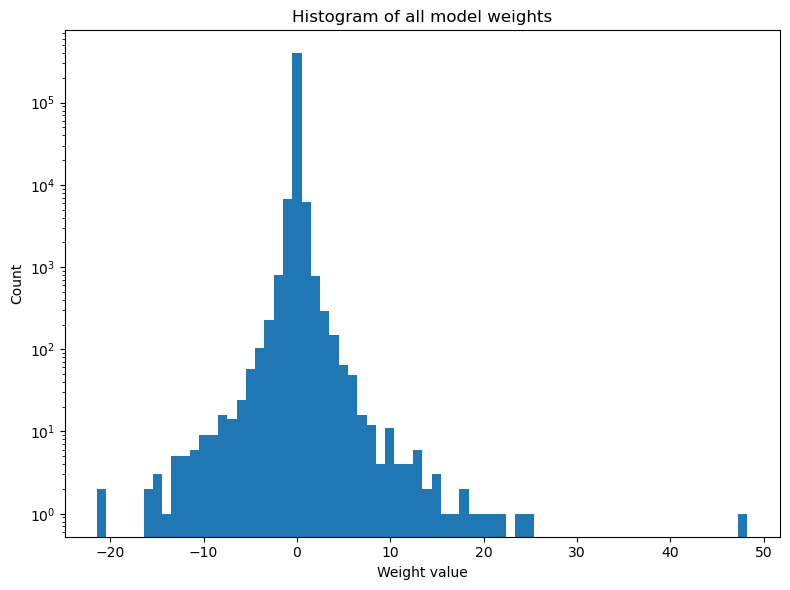

In [ ]:
# 1. Grab all trainable variables from your Keras model
#    (this will include every weight/bias in your MAF/RQS networks,
#     because TFP tracks them as part of the model once you called fit)
vars = NFObject.model.trainable_weights

# 2. Pull them out as a flat NumPy array
all_w = np.concatenate([w.numpy().ravel() for w in vars])

# 3. Plot
plt.figure(figsize=(8,6))
plt.hist(all_w, bins=70)
plt.xlabel("Weight value")
plt.ylabel("Count")
plt.yscale('log')
plt.title("Histogram of all model weights")
plt.tight_layout()
plt.show()

# Evaluation

## Building Preprocessed test dataset
Reads the test dataset and builds the new test dataset. added the flag `E_coarse_max_ref` but I still don't know if i need to use it, if E_max from the first dataset is less than the max in this new dataset we could have some problem in the logarithms

In [ ]:
MODE = 'A'
showers_raw, cs, E_inc, fine_flat, cond_flat, factors = Preprocess2.build_and_cache(
    raw_h5     = "/teo_fs_fast/users/acosso/Dataset/dataset_2_2.hdf5",
    cache_file = "/teo_fs_fast/users/acosso/Dataset/eval_dataset_A.hdf5",
    mode       = MODE,
    E_coarse_max_ref = None,  # Set to None to use the maximum from the dataset
    force_rebuild = False,
    verbose = True, 
    noise_scale=1e-4,
    compression = 'lzf'
)

[build_and_cache] Loading from cache.


## How do Gmetrics work?
it wants a callable function that returns the requested number of samples. If the input module asks for n samples, the shape should be (n,d) where d is the number of features. 

- **Option A**: Per-Coarse voxel metrics
we compare the energy distribution in the generated fine voxels vs the true, original, ones.

-  **Option B**: Per-event physical features
    - energy distribution of the whole shower
    - energy fractions in the layers
    - radial distribution
    - angular distribution
    - moments (mean, stddev...)

| Category    | Metric                               | Physical purpose                   |
| ----------- | -----------------------------------  | -----------------------------------|
| Global      | Total energy                         | energy conservation                |
| Global      | Layer energies                       | SWD | longitudinal shower shape    |
| Global      | Centroid (r,z)                       | spatial bias                       |
| Shape       | Lateral & longitudinal RMS           | shower width                       |
| Structure   | Layer covariance                     | Frobeniu | inter-layer correlation |
| Local       | Per-layer voxel marginals            | local realism                      |
| Local       | Peakiness                            | energy clustering                  |
| Conditional | Energy conservation per coarse voxel | mean  | local normalization        |
| Summary     | FGD                                  | global fidelity indicator          |


In [ ]:
sys.path.append('../')
import GMetrics # type: ignore
from GMetrics.plotters import plot_corners, cornerplotter, plot_corr_matrix, plot_corr_matrix_side_by_side # type: ignore
from GMetrics.more import deformations # type: ignore
from GMetrics.more.optimizers_deformations import compute_exclusion_bisection, compute_exclusion_LR_bisection # type: ignore
from GMetrics.utils import se_mean, se_std, NumpyDistribution
from GMetrics.notebooks import shared
try:
    from GMetrics.base import NumpyDistribution
except ImportError:
    try:
        from GMetrics.more import NumpyDistribution
    except ImportError:
        from GMetrics.utils import NumpyDistribution

import pandas as pd

/teo_fs_fast/software/miniforge/envs/acosso_tf2_12_falkon/lib/python3.11/site-packages/coffea/nanoevents/schemas/fcc.py:5: FutureWarning: In version 2025.1.0 (target date: 2024-12-31 11:59:59-06:00), this will be an error.
To raise these warnings as errors (and get stack traces to find out where they're called), run
    import warnings
    warnings.filterwarnings("error", module="coffea.*")
after the first `import coffea` or use `@pytest.mark.filterwarnings("error:::coffea.*")` in pytest.
Issue: coffea.nanoevents.methods.vector will be removed and replaced with scikit-hep vector. Nanoevents schemas internal to coffea will be migrated. Otherwise please consider using that package!.
  from coffea.nanoevents.methods import vector


In [ ]:
from GMetrics.utils import NumpyDistribution
class EmpiricalNumpyDistribution(NumpyDistribution):
    def __init__(self, data: np.ndarray, dtype: np.dtype = np.float32):
        """
        Initialize with your numeric data and ensure the dtype is consistent.
        
        Args:
            data (np.ndarray): The empirical data to sample from.
            dtype (np.dtype): The desired data type for the output samples.
        """
        if not isinstance(data, np.ndarray):
            raise ValueError("Data must be a numpy ndarray.")
        
        self.data = data
        self.dtype = dtype
        self.ndims = data.shape[1]  # Number of features (columns)
        self.nsamples = data.shape[0]  # Number of samples (rows)
    
    def sample(self, n: int, seed: int = None) -> np.ndarray:
        """
        Sample `n` data points with replacement from the stored data.

        Args:
            n (int): The number of samples to return.
            seed (int): The seed for random number generation to ensure reproducibility.

        Returns:
            np.ndarray: A batch of resampled data with shape (n, self.ndims).
        """
        # Use the seed to make the sampling deterministic
        rng = np.random.default_rng(seed)

        # Resample with replacement
        indices = rng.choice(self.nsamples, size=n, replace=True)
        resampled_data = self.data[indices]
        
        # Ensure the output has the desired dtype
        return resampled_data.astype(self.dtype)


## Building evaluation datasets

In [ ]:
from eval_streaming import evaluate_flow_and_cache

evaluate_flow_and_cache(
    in_cache_h5="/teo_fs_fast/users/acosso/Dataset/eval_dataset_A.hdf5",
    out_h5="/teo_fs_fast/users/acosso/Dataset/eval_results_A.hdf5",
    flow=MAF,
    base_dist=base_dist,
    gpu_batch=65536,          # lower if you still see OOM (e.g. 16384)
    io_chunk_rows=2_000_000,  # disk I/O window; 0.5–2M is usually sweet-spot
    start_row=0,
    n_rows=None,              # None = process to the end
    tf_dtype=tf.float64,
    save_as_float32=True,     # shrinks result file by ~2x
    clip_latent=False,
    latent_clip_value=4.0,
    compression="lzf",
    seed=42,
    overwrite=False,
)

[DONE] Wrote 64,800,000 rows to /teo_fs_fast/users/acosso/Dataset/eval_results_A.hdf5


### Building feature dataset

In [ ]:
from make_eval_features import build_eval_features

meta = build_eval_features(
    results_h5="/teo_fs_fast/users/acosso/Dataset/eval_results_A.hdf5",
    truth_h5="/teo_fs_fast/users/acosso/Dataset/eval_dataset_A.hdf5",
    out_h5="/teo_fs_fast/users/acosso/Dataset/eval_features_A.hdf5",
    io_chunk_events=100_000,
    compression="lzf",
    overwrite=False,
)

[build_eval_features] Output file already exists: /teo_fs_fast/users/acosso/Dataset/eval_features_A.hdf5
  overwrite flag is False → skipping feature computation.
  Existing file has N_events=100000, nz=9, zf=5, fine layers=45


## Loading data

In [ ]:
def load_layer_energies(
    out_h5="/teo_fs_fast/users/acosso/Dataset/eval_features_A.hdf5",
    N=None,                     # cap number of events to load; None = all
    to_dtype=np.float64         # promote to float64 for numerics if you want
):
    """
    Loads per-layer energy arrays from eval_features HDF5.

    Returns:
        layer_true: (N, nz) ndarray
        layer_gen:  (N, nz) ndarray
        meta: dict with keys: N_events, nz, na, nr, zf, af, rf, Df, source files
    """
    out_h5 = str(out_h5)
    if not Path(out_h5).exists():
        raise FileNotFoundError(out_h5)

    with h5py.File(out_h5, "r") as f:
        # Required datasets from make_eval_features.py
        if ("/per_event/layer_E_true" not in f) or ("/per_event/layer_E_gen" not in f):
            raise KeyError("Missing '/per_event/layer_E_true' or '/per_event/layer_E_gen' in eval_features file")

        lay_true_ds = f["/per_event/layer_E_true"]   # shape [N, nz]
        lay_gen_ds  = f["/per_event/layer_E_gen"]    # shape [N, nz]
        N_total, nz = lay_true_ds.shape
        if lay_gen_ds.shape != (N_total, nz):
            raise ValueError("layer_E_true and layer_E_gen shapes differ.")

        # Clamp N if requested
        N_use = N_total if (N is None) else min(int(N), int(N_total))

        # Load into RAM (N*45*4B ~ 18 MB if float32 for N=100k → safe; we promote if asked)
        layer_true = lay_true_ds[:N_use]
        layer_gen  = lay_gen_ds[:N_use]

        if to_dtype is not None:
            layer_true = layer_true.astype(to_dtype, copy=False)
            layer_gen  = layer_gen.astype(to_dtype,  copy=False)

        # Collect metadata (stored by make_eval_features)
        attrs = f.attrs
        meta = {
            "N_events": int(attrs.get("N_events", N_total)),
            "Df":       int(attrs.get("Df", -1)),
            "nz":       int(attrs.get("nz", nz)),
            "na":       int(attrs.get("na", -1)),
            "nr":       int(attrs.get("nr", -1)),
            "zf":       int(attrs.get("zf", -1)),
            "af":       int(attrs.get("af", -1)),
            "rf":       int(attrs.get("rf", -1)),
            "source_results": attrs.get("source_results", ""),
            "source_truth":   attrs.get("source_truth", ""),
            "loaded_N": N_use,
            "file": out_h5,
        }

    return layer_true, layer_gen, meta

In [ ]:
# 1) Load the per-layer samples (shape = (N, 45)) for both truth and model
layer_true, layer_gen, meta = load_layer_energies(
    out_h5="/teo_fs_fast/users/acosso/Dataset/eval_features_A.hdf5",
    N=100_000,             # or None for all
    to_dtype=np.float64     # safe numerics for the metrics
)
print(layer_true.shape, layer_gen.shape)  # -> (N, 45) each
print(meta)

(100000, 45) (100000, 45)
{'N_events': 100000, 'Df': 6480, 'nz': 9, 'na': 8, 'nr': 9, 'zf': 5, 'af': 2, 'rf': 1, 'source_results': '/teo_fs_fast/users/acosso/Dataset/eval_results_A.hdf5', 'source_truth': '/teo_fs_fast/users/acosso/Dataset/eval_dataset_A.hdf5', 'loaded_N': 100000, 'file': '/teo_fs_fast/users/acosso/Dataset/eval_features_A.hdf5'}


### plotting data, only for layer energy

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_overlaid_histograms(
    truth: np.ndarray,
    generated: np.ndarray,
    dims,
    bins: int = 50,
    *,
    normalization: str = "density",
    index_base: str = "auto",     # "auto" | "0" | "1"
    logx: bool = False,
    logy: bool = False,
    figsize: tuple | None = None,
    suptitle: str | None = None,
 ) :
    """
    Overlay histograms for selected feature dimensions from TRUTH and GENERATED arrays.

    Parameters
    ----------
    truth, generated : array-like of shape (N, D)
        Data matrices.
    dims : iterable of ints
        Feature indices to plot. Can be 0-based or 1-based; auto-detected by default.
    bins : int
        Number of histogram bins.
    normalization : {"density", "counts"}
        Choose between PDF (`density=True`) or normalized counts (sum of bar heights = 1).
    index_base : {"auto","0","1"}
        Controls how `dims` are interpreted. "auto" tries to detect 1-based lists.
    logx, logy : bool
        Whether to use logarithmic scaling for x and/or y axis.
    figsize : tuple or None
        Figure size; if None, chosen automatically based on number of panels.
    suptitle : str or None
        Overall figure title.
    """

    truth = np.asarray(truth)
    generated = np.asarray(generated)

    if normalization not in {"density", "counts"}:
        raise ValueError("normalization must be either 'density' or 'counts'.")

    if truth.ndim != 2 or generated.ndim != 2:
        raise ValueError("Both inputs must be 2D arrays of shape (N, D).")
    if truth.shape[1] != generated.shape[1]:
        raise ValueError("Truth and generated must have the same number of columns (features).")

    N, D = truth.shape

    # Normalize/validate dims
    dims = list(dims)
    if len(dims) == 0:
        raise ValueError("`dims` must contain at least one feature index.")

    if index_base == "auto":
        if 0 in dims:
            idx = dims
        elif min(dims) >= 1 and max(dims) <= D:
            idx = [i - 1 for i in dims]
        else:
            idx = dims
    elif index_base == "0":
        idx = dims
    else:  # "1"
        idx = [i - 1 for i in dims]

    # Check bounds
    if any(i < 0 or i >= D for i in idx):
        raise IndexError(f"Some indices are out of bounds for D={D}. Got: {dims} (interpreted as {idx}).")

    k = len(idx)
    ncols = min(4, k)
    nrows = int(np.ceil(k / ncols))
    if figsize is None:
        figsize = (3.8 * ncols, 3.8 * nrows)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, dpi = 300)
    if k == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for ax, j in zip(axes, idx):
        t = truth[:, j]
        g = generated[:, j]
        t = t[np.isfinite(t)]
        g = g[np.isfinite(g)]

        if len(t) == 0 or len(g) == 0:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
            continue

        # Define binning depending on logx flag
        if logx:
            # avoid nonpositive values
            tpos = t[t > 0]
            gpos = g[g > 0]
            if len(tpos) == 0 or len(gpos) == 0:
                ax.text(0.5, 0.5, "No positive data for logx", ha="center", va="center", transform=ax.transAxes)
                ax.set_axis_off()
                continue
            combined = np.concatenate([tpos, gpos])
            edges = np.logspace(np.log10(np.min(combined)), np.log10(np.max(combined)), bins + 1)
        else:
            combined = np.concatenate([t, g])
            edges = np.histogram_bin_edges(combined, bins=bins)

        if normalization == "density":
            density_flag = True
            truth_weights = None
            gen_weights = None
            ylabel = "PDF"
        else:
            density_flag = False
            truth_weights = np.ones_like(t, dtype=np.float64) / len(t)
            gen_weights = np.ones_like(g, dtype=np.float64) / len(g)
            ylabel = "Probability per bin"

        # Plot truth (filled) and generated (line)
        ax.hist(
            t,
            bins=edges,
            density=density_flag,
            weights=truth_weights,
            histtype="stepfilled",
            alpha=0.35,
            color = '#4C72B0',
            label="Truth",
        )
        ax.hist(
            g,
            bins=edges,
            density=density_flag,
            weights=gen_weights,
            histtype="step",
            linewidth=1.7,
            color = '#DD8452',
            label="Generated",
        )

        ax.set_ylabel(ylabel, fontsize = 15)
        ax.set_xlabel(f"Layer {j+1}", fontsize = 15)
        ax.set_title(f"Layer {j+1}", fontsize=15)
        ax.legend(fontsize = 12)
        ax.grid(True, alpha=0.3)

        # Apply scaling
        if logx:
            ax.set_xscale("log")
        if logy:
            ax.set_yscale("log")
        #ax.set_xlim(left = 1e-2)

    # Hide unused subplots
    for extra_ax in axes[k:]:
        extra_ax.set_visible(False)
    

    if suptitle:
        fig.suptitle(suptitle)
    fig.tight_layout()
    return fig, axes[:k]


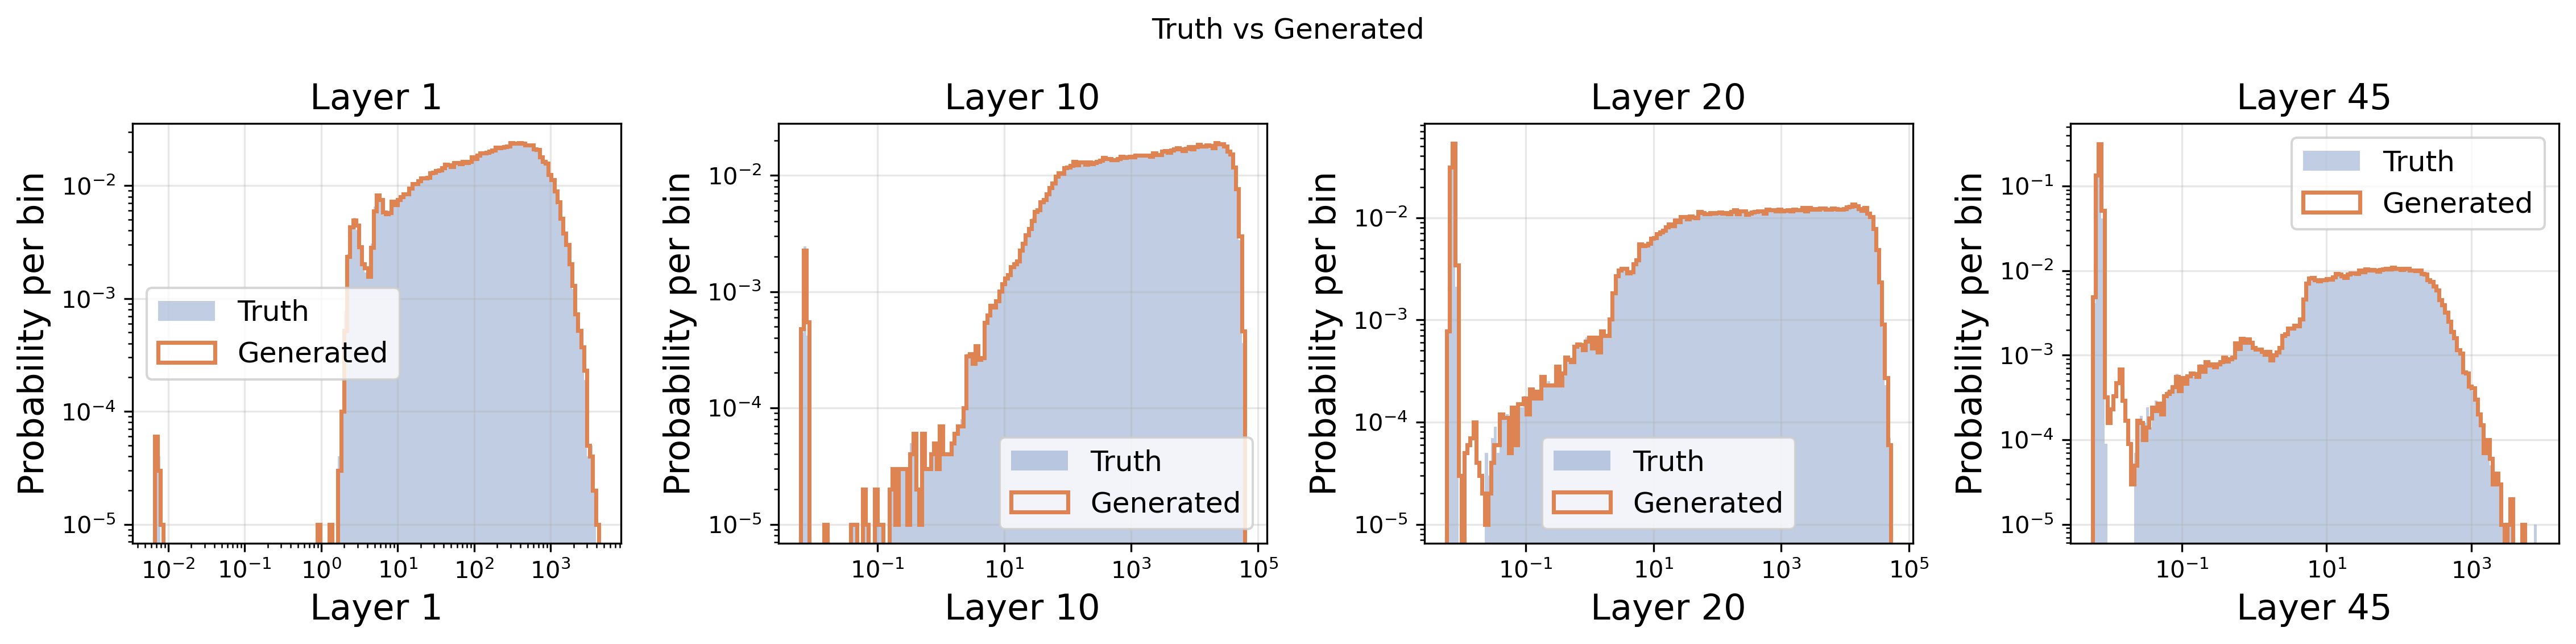

In [ ]:
# truth_data: shape (100_000, 45)
# gen_data:   shape (100_000, 45)
#dims = [1, 5, 10, 15, 20, 25, 30, 35, 40, 45]  # you can pass 1-based like this
dims = [1, 10, 20, 45]
plot_overlaid_histograms(layer_true, layer_gen, dims, 
                         bins=150, normalization="counts", suptitle="Truth vs Generated",
                         logx=True, logy=True,
                         )
plt.show()


## directory path

In [ ]:
#model_dir = "./53/"
model_dir = os.path.join("./", str(run_number) + "/")
if os.path.exists(model_dir):
    print("Model directory exists")
else:
    os.makedirs(model_dir)
    print("Model directory was created")
null_hypotheses_dir = model_dir + "null_hypothesis/"
if os.path.exists(null_hypotheses_dir):
    print("Null hypothesis directory exists")
else:
    os.makedirs(null_hypotheses_dir)
    print("Null hypothesis directory was created")
metrics_config_file = model_dir + "metrics_config.json"

Model directory exists
Null hypothesis directory exists


## input builder

In [ ]:
niter = 1000
batch_size_test = 10000
seed_test = 42

In [ ]:
l = layer_true.shape[0] //2
print(l)

50000


In [ ]:
orig = layer_true.copy()   # keep original intact
rng1 = np.random.default_rng(420)
perm1 = rng1.permutation(len(orig))
input_true1 = orig[perm1].copy()

rng2 = np.random.default_rng(421)
perm2 = rng2.permutation(len(orig))
input_true2 = orig[perm2].copy()
print(input_true1.shape, input_true2.shape)



(100000, 45) (100000, 45)


### bootstraping class

In [ ]:
input_true1 = EmpiricalNumpyDistribution(input_true1.copy(), dtype=np.float64)
input_true2 = EmpiricalNumpyDistribution(input_true2.copy(), dtype=np.float64)

In [ ]:

TwoSampleTestInputs = GMetrics.TwoSampleTestInputs(dist_1_input = input_true1,
                                                   dist_2_input = input_true2,
                                                   niter = niter,
                                                   batch_size_test = batch_size_test,
                                                   batch_size_gen = 1, # not used if numerical samples are provided
                                                   small_sample_threshold = 1,
                                                   dtype_input = tf.float64,
                                                   seed_input = seed_test,
                                                   use_tf = False, 
                                                   mirror_strategy = False,
                                                   verbose = True)
print("nsamples",TwoSampleTestInputs.nsamples)
print("batch_size",TwoSampleTestInputs.batch_size_test)
print("niter",TwoSampleTestInputs.niter)
print("niter * batch_size",TwoSampleTestInputs.niter*TwoSampleTestInputs.batch_size_test)
print("small_sample",TwoSampleTestInputs.small_sample)

Parsing input distribution...
Input distribution is a NumpyDistribution object.
Parsing input distribution...
Input distribution is a NumpyDistribution object.
nsamples 10000000
batch_size 10000
niter 1000
niter * batch_size 10000000
small_sample False


## Metric init 

In [ ]:
nslices = 150
fgd_num_points = 10
fgd_num_batches = 20

In [ ]:
KSTest = GMetrics.KSTest(TwoSampleTestInputs,
                         progress_bar = True,
                         verbose = True)
SKSTest = GMetrics.SKSTest(TwoSampleTestInputs,
                           nslices = nslices, # to be included in metric kwargs
                           seed_slicing = 0, # to be included in metric kwargs
                           progress_bar = True,
                           verbose = True)
SWDMetric = GMetrics.SWDMetric(TwoSampleTestInputs,
                               nslices = nslices, # to be included in metric kwargs
                               seed_slicing = 0, # to be included in metric kwargs
                               progress_bar = True,
                               verbose = True)
FGDMetric = GMetrics.FGDMetric(TwoSampleTestInputs,
                               progress_bar = True,
                               verbose = True,
                               num_batches = fgd_num_batches, # to be included in metric kwargs
                               num_points = fgd_num_points, # to be included in metric kwargs
                               normalise = False) # to be included in metric kwargs
MMDMetric = GMetrics.MMDMetric(TwoSampleTestInputs,
                               progress_bar = True,
                               verbose = True,
                               degree = 4, # to be included in metric kwargs
                               block_size = 10_000, # to be included in metric kwargs
                               normalise = False) # to be included in metric kwargs
'''
LRMetric = GMetrics.LRMetric(TwoSampleTestInputs,
                             null_test=True,
                             verbose = True)
'''

Generating random directions based on nslices, ndims, and seed_slicing.
Generating random directions based on nslices, ndims, and seed_slicing.


'\nLRMetric = GMetrics.LRMetric(TwoSampleTestInputs,\n                             null_test=True,\n                             verbose = True)\n'

### Set up tests and metrics configurations

In [ ]:
test_config_null = {}
test_config_tmp = dict(TwoSampleTestInputs.__dict__)
keys_to_remove = ["_dist_1_input", "_dist_2_input", "_dist_1_num", "_dist_2_num", "_dist_1_symb", "_dist_2_symb", "_seed_generator"]
for key in keys_to_remove:
    test_config_tmp.pop(key, None)
for key, value in test_config_tmp.items():
    new_key = key.lstrip('_')
    
    if isinstance(value, tf.Tensor):
        new_value = value.numpy() # type: ignore
    elif isinstance(value, np.ndarray):
        new_value = value.tolist()
    elif isinstance(value, np.generic):
        new_value = value.item() # Convert NumPy scalars to Python scalars
    elif isinstance(value, tf.DType):
        new_value = value.name
    elif isinstance(value, np.dtype):
        new_value = np.dtype(value).name
    else:
        new_value = value
    
    test_config_null[new_key] = new_value

pd.DataFrame([test_config_null])

,niter,batch_size_test,batch_size_gen,small_sample_threshold,dtype_input,seed,use_tf,mirror_strategy,strategy,verbose,is_symb_1,ndims_1,nsamples_1,is_symb_2,ndims_2,nsamples_2,dtype,ndims,nsamples,small_sample
0,1000,10000,1,1,float64,42,False,False,None,True,True,45,0,True,45,0,float64,45,10000000,False


In [ ]:
ndims = TwoSampleTestInputs.ndims
unique_key = "config_ndims_"+str(TwoSampleTestInputs.ndims)+"_nsamples_"+str(TwoSampleTestInputs.batch_size_test)+"_niter_"+str(TwoSampleTestInputs.niter)
metrics_config = {unique_key: {
                                #"fgd": {"name": "fgd",
                                #       "object_name": "FGDMetric",
                                #       "class_name": "GMetrics.FGDMetric",
                                #       "kwargs": {"num_batches": fgd_num_batches,
                                #                  "num_points": fgd_num_points,
                                #                  "normalise": False},
                                #       "result_key": "metric_list", 
                                #       "scale_func": lambda ns, ndims: 1,
                                #       "scale_func_string": "lambda ns, ndims: 1",
                                #       "test_config": test_config_null,
                                #       "max_vectorize": 100, # optimized for 5D
                                #       "latex": "$t_{\mathrm{FGD}}$",
                                #       "null_file": null_hypotheses_dir+"FGD.json"},
                                #"mmd": {"name": "mmd",
                                #       "object_name": "MMDMetric" ,
                                #       "class_name": "GMetrics.MMDMetric",
                                #       "kwargs": {"degree": 4, 
                                #                  "block_size": 10_000, 
                                #                  "normalise": False},
                                #       "result_key": "metric_list", 
                                #       "scale_func": lambda ns, ndims: 1,
                                #       "scale_func_string": "lambda ns, ndims: 1",
                                #       "test_config": test_config_null,
                                #       "max_vectorize": 2, # optimized for 5D
                                #       "latex": "$t_{\mathrm{MMD}}$",
                                #       "null_file": null_hypotheses_dir+"MMD.json"},
                               "ks":  {"name": "ks",
                                       "object_name": "KSTest",
                                       "class_name": "GMetrics.KSTest", 
                                       "kwargs": {},
                                       "result_key": "statistic_means", 
                                       "scale_func": lambda ns, _ : np.sqrt(ns),
                                       "scale_func_string": "lambda ns, _: np.sqrt(ns)",
                                       "test_config": test_config_null,
                                       "max_vectorize": 10000,
                                       "latex": "$t_{\overline{\mathrm{KS}}}$",
                                       "null_file": null_hypotheses_dir+"KS.json"},
                               "sks": {"name": "sks",
                                       "object_name": "SKSTest",
                                       "class_name": "GMetrics.SKSTest", 
                                       "kwargs": {"nslices": nslices, 
                                                  "seed_slicing": 0},
                                       "result_key": "metric_means", 
                                       "scale_func": lambda ns, _ : np.sqrt(ns),
                                       "scale_func_string": "lambda ns, _: np.sqrt(ns)",
                                       "test_config": test_config_null,
                                       "max_vectorize": 200,
                                       "latex": "$t_{\mathrm{SKS}}$",
                                       "null_file": null_hypotheses_dir+"SKS.json"},
                               "swd": {"name": "swd",
                                       "object_name": "SWDMetric",
                                       "class_name": "GMetrics.SWDMetric", 
                                       "kwargs": {"nslices": nslices, 
                                                  "seed_slicing": 0},
                                       "result_key": "metric_means", 
                                       "scale_func": lambda ns, ndims: np.sqrt(ns/ndims),
                                       "scale_func_string": "lambda ns, ndims: np.sqrt(ns/ndims)",
                                       "test_config": test_config_null,
                                       "max_vectorize": 200,
                                       "latex": "$t_{\mathrm{SW}}$",
                                       "null_file": null_hypotheses_dir+"SWD.json"}}}
           
'''
"lr": {"name": "lr",
        "object_name": "LRMetric",
        "class_name": "GMetrics.LRMetric", 
        "kwargs": {"null_test": True},
        "result_key": "lik_ratio_norm_list", 
        "scale_func": lambda ns, ndims: np.sqrt(ns),
        "scale_func_string": "lambda ns, ndims: np.sqrt(ns)",
        "test_config": test_config_null,
        "max_vectorize": 50,
        "latex": "$t_{\mathrm{LLR}}$",
        "null_file": null_hypotheses_dir+"LR.json"}
'''
#metrics_config[unique_key]

'\n"lr": {"name": "lr",\n        "object_name": "LRMetric",\n        "class_name": "GMetrics.LRMetric", \n        "kwargs": {"null_test": True},\n        "result_key": "lik_ratio_norm_list", \n        "scale_func": lambda ns, ndims: np.sqrt(ns),\n        "scale_func_string": "lambda ns, ndims: np.sqrt(ns)",\n        "test_config": test_config_null,\n        "max_vectorize": 50,\n        "latex": "$t_{\\mathrm{LLR}}$",\n        "null_file": null_hypotheses_dir+"LR.json"}\n'

## Evaluate null hypotheses

In [ ]:
'''
for metric in list(metrics_config[unique_key].values())[:-1]:
    file = metric["null_file"]
    name = metric["name"]
    max_vectorize = metric["max_vectorize"]
    obj = eval(metric["object_name"])
    if os.path.exists(file):
        print(f"Loading {name} from {file}")
        obj.Results.load_from_json(file)
    else:
        print(f"Computing and savng {name} with max_vectorize = {max_vectorize}")
        obj.Test_np(max_vectorize=max_vectorize)
        print(f"Saving {name} to {file}")
        obj.Results.save_to_json(file)
'''
import inspect
'''
for metric in list(metrics_config[unique_key].values()):
    file = metric["null_file"]
    name = metric["name"]
    max_vectorize = metric.get("max_vectorize", None)
    obj = eval(metric["object_name"])

    os.makedirs(os.path.dirname(file), exist_ok=True)

    use_tf_flag = getattr(obj.Inputs, "use_tf", False)
    test_fn = getattr(obj, "Test_tf", None) if use_tf_flag else getattr(obj, "Test_np", None)
    if test_fn is None:
        raise RuntimeError(f"{name}: no test function for use_tf={use_tf_flag}")

    if os.path.exists(file):
        print(f"Loading {name} from {file}")
        obj.Results.load_from_json(file)
    else:
        print(f"Computing and saving {name} (use_tf={use_tf_flag})")
        sig = inspect.signature(test_fn)
        call_kwargs = {}
        if "max_vectorize" in sig.parameters and max_vectorize is not None:
            call_kwargs["max_vectorize"] = max_vectorize
        test_fn(**call_kwargs)
        print(f"Saving {name} to {file}")
        obj.Results.save_to_json(file)
'''

'\nfor metric in list(metrics_config[unique_key].values()):\n    file = metric["null_file"]\n    name = metric["name"]\n    max_vectorize = metric.get("max_vectorize", None)\n    obj = eval(metric["object_name"])\n\n    os.makedirs(os.path.dirname(file), exist_ok=True)\n\n    use_tf_flag = getattr(obj.Inputs, "use_tf", False)\n    test_fn = getattr(obj, "Test_tf", None) if use_tf_flag else getattr(obj, "Test_np", None)\n    if test_fn is None:\n        raise RuntimeError(f"{name}: no test function for use_tf={use_tf_flag}")\n\n    if os.path.exists(file):\n        print(f"Loading {name} from {file}")\n        obj.Results.load_from_json(file)\n    else:\n        print(f"Computing and saving {name} (use_tf={use_tf_flag})")\n        sig = inspect.signature(test_fn)\n        call_kwargs = {}\n        if "max_vectorize" in sig.parameters and max_vectorize is not None:\n            call_kwargs["max_vectorize"] = max_vectorize\n        test_fn(**call_kwargs)\n        print(f"Saving {name} to 

### summary table and threshold calculation

In [ ]:
'''
cl_list = [0.68, 0.95, 0.99]
null_times = []

for metric in list(metrics_config[unique_key].values()):
    name = metric["name"]
    obj = eval(metric["object_name"])
    result_key = metric["result_key"]
    scale_func = metric["scale_func"]
    
    #params = obj.Results[-1].__dict__  # parameters are in the result object
    #bs_used = int(params.get('batch_size_test_used', obj.Inputs.batch_size_test))
    #ns_eff = bs_used / 2.0
    #dist_null = np.array(obj.Results[-1].result_value[result_key]) * scale_func(ns_eff, ndims)
    nsamples = obj.Inputs.batch_size_test
    ns = nsamples**2 /(2*nsamples)  # == nsamples/2
    dist_null = np.array(obj.Results[-1].result_value[result_key]) * scale_func(ns, ndims)

    metric_thresholds = [[cl, 
                          [int(cl*len(dist_null)), 
                           int((1-cl)*len(dist_null))], 
                          np.sort(dist_null)[int(len(dist_null)*cl)]] for cl in cl_list]
    print(f"ThresholdS for metric {metric['name']}: {metric_thresholds}")
    null_time = obj.Results[-1].__dict__['computing_time']
    null_times.append([name, int(null_time)])
    print(f"Computing time for metric {metric['name']}: {null_time}")
    
    metric.update({"thresholds": metric_thresholds})
    
#metrics_config[unique_key]["lr"]["thresholds"] = [] #likelihood ratio test not computed

GMetrics.utils.save_update_metrics_config(metrics_config = metrics_config, metrics_config_file = metrics_config_file) # type: ignore
'''

'\ncl_list = [0.68, 0.95, 0.99]\nnull_times = []\n\nfor metric in list(metrics_config[unique_key].values()):\n    name = metric["name"]\n    obj = eval(metric["object_name"])\n    result_key = metric["result_key"]\n    scale_func = metric["scale_func"]\n\n    #params = obj.Results[-1].__dict__  # parameters are in the result object\n    #bs_used = int(params.get(\'batch_size_test_used\', obj.Inputs.batch_size_test))\n    #ns_eff = bs_used / 2.0\n    #dist_null = np.array(obj.Results[-1].result_value[result_key]) * scale_func(ns_eff, ndims)\n    nsamples = obj.Inputs.batch_size_test\n    ns = nsamples**2 /(2*nsamples)  # == nsamples/2\n    dist_null = np.array(obj.Results[-1].result_value[result_key]) * scale_func(ns, ndims)\n\n    metric_thresholds = [[cl, \n                          [int(cl*len(dist_null)), \n                           int((1-cl)*len(dist_null))], \n                          np.sort(dist_null)[int(len(dist_null)*cl)]] for cl in cl_list]\n    print(f"ThresholdS for met

### Null distribution plots

In [ ]:
# === DROP-IN PLOTTING CELL (formal Kolmogorov via kstwobign, unit-matched via thresholds) ===
from timeit import default_timer as timer
import numpy as np, matplotlib.pyplot as plt, pandas as pd
from scipy.stats import kstwobign  # Kolmogorov (asymptotic) distribution

def se_mean(x):
    return np.std(x, ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan

def se_std(x):
    n = len(x); s = np.std(x, ddof=1)
    return s / np.sqrt(2*(n-1)) if n > 1 else np.nan

def _dedup_legend(ax, **kwargs):
    h, l = ax.get_legend_handles_labels()
    seen=set(); H=[]; L=[]
    for hi, li in zip(h,l):
        if li not in seen:
            seen.add(li); H.append(hi); L.append(li)
    ax.legend(H, L, **kwargs)

all_stats_rows = []

'''
for metric in metrics_config[unique_key].values():
    name        = metric["name"]
    name_low    = str(name).lower()
    obj         = eval(metric["object_name"])
    result_key  = metric["result_key"]
    scale_func  = metric["scale_func"]
    figure_file = metric["null_file"].replace("json", "pdf")
    thresholds  = metric["thresholds"]
    latex       = metric["latex"]

    start = timer()

    nsamples = int(obj.Inputs.batch_size_test)
    niter    = int(obj.Inputs.niter)
    nd       = int(ndims)
    ns       = nsamples // 2  # n_eff for two-sample KS when n=m

    dist_null = np.asarray(obj.Results[-1].result_value[result_key], dtype=float)
    dist_null = dist_null * float(scale_func(ns, nd))  # e.g. sqrt(n_eff) for KS

    # Display-only scaling
    scale_factor = 1.0
    if "FGD" in latex:
        scale_factor = 1e-7
        latex = r"$t_{\mathrm{FGD}}\,(\times 10^{-7})$"
    elif "MMD" in latex:
        scale_factor = 1e5
        latex = r"$t_{\mathrm{MMD}}\,(\times 10^{5})$"

    dist_plot = dist_null * scale_factor
    scaled_thresholds = [(cl, idx, thr * scale_factor) for (cl, idx, thr) in thresholds]

    # Summary stats
    mu, mu_se = float(np.mean(dist_plot)), float(se_mean(dist_plot))
    sd, sd_se = float(np.std(dist_plot, ddof=1)), float(se_std(dist_plot))

    row = {"metric": name.upper(), "mean": mu, "SE(mean)": mu_se, "std": sd, "SE(std)": sd_se}
    for cl, _, thr in scaled_thresholds:
        row[f"Thr{int(cl*100)}"] = float(thr)
    all_stats_rows.append(row)

    # Histogram + eCDF on same bins
    clip_q = 0.995
    x_min_data = float(np.min(dist_plot))
    x_max_data = float(np.max(dist_plot))
    x_clip     = float(np.quantile(dist_plot, clip_q))
    x_thr_max  = max([thr for (_, _, thr) in scaled_thresholds], default=x_clip)
    x_min = x_min_data
    x_max = max(x_clip, x_thr_max)

    num_bins          = 35
    counts, bin_edges = np.histogram(dist_plot, bins=num_bins, range=(x_min, x_max), density=True)
    bin_widths        = np.diff(bin_edges)
    cdf_vals          = np.clip(np.cumsum(counts * bin_widths), 0.0, 1.0)

    xpad = 0.04 * (x_max - x_min) if np.isfinite(x_max - x_min) else 0.0
    x_left, x_right = x_min - xpad, x_max + xpad

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    dash_styles = ['-', '--', '-.']
    colors      = ["royalblue", "darkorange", "mediumseagreen"]

    # PDF step + bin closures
    pdf_line = ax[0].step(bin_edges[:-1], counts, where='post', color="tomato",
                          label="Null distribution")[0]
    pdf_style = dict(color=pdf_line.get_color(),
                     linewidth=pdf_line.get_linewidth(),
                     linestyle=pdf_line.get_linestyle(),
                     alpha=pdf_line.get_alpha())
    pos_counts = counts[counts > 0]
    y_base = max(float(pos_counts.min()) * 0.5, 1e-12) if len(pos_counts) else 1e-12
    if len(counts) > 0:
        ax[0].hlines(counts[0], bin_edges[0], bin_edges[1], **pdf_style)
        ax[0].hlines(counts[-1], bin_edges[-2], bin_edges[-1], **pdf_style)
        ax[0].vlines(bin_edges[0], y_base, counts[0], **pdf_style)
        ax[0].vlines(bin_edges[-1], y_base, counts[-1], **pdf_style)

    # === FORMAL Kolmogorov overlays via kstwobign (only for KS-like metrics) ===
    add_kolmogorov = ("ks" in name_low)
    if add_kolmogorov:
        # Estimate scale S so kstwobign is plotted in the SAME units as the x-axis
        S_candidates = []
        for cl, _, thr in scaled_thresholds:
            if 0.5 < cl < 1.0 and np.isfinite(thr):
                z_cl = kstwobign.ppf(cl)  # Kolmogorov quantile
                if np.isfinite(z_cl) and z_cl > 0:
                    S_candidates.append(thr / z_cl)
        if len(S_candidates):
            S = float(np.median(S_candidates))
        else:
            # fallback: match std, then mean
            mu_K  = float(kstwobign.mean())
            sd_K  = float(kstwobign.std())
            S = None
            if np.isfinite(sd) and sd_K > 0:
                S = sd / sd_K
            elif np.isfinite(mu) and mu_K > 0:
                S = mu / mu_K
            if S is None or not np.isfinite(S) or S <= 0:
                S = 1.0

        x0 = max(0.0, x_left)           # support x>=0
        xg = np.linspace(x0, x_right, 600)
        zg = xg / max(S, 1e-12)

        pdf_k = kstwobign.pdf(zg) / max(S, 1e-12)
        cdf_k = kstwobign.cdf(zg)

        ax[0].plot(xg, np.clip(pdf_k, y_base, None),
                   label="Kolmogorov PDF", linewidth=1.6)
        ax[1].plot(xg, np.clip(cdf_k, 0.0, 1.0),
                   label="Kolmogorov CDF", linewidth=1.6)

    # Axes + limits
    ax[0].set_yscale('log')
    ax[0].set_xlabel(latex, fontsize=16)
    ax[0].set_ylabel('Density', fontsize=16)
    ax[0].set_title(rf"$d = {nd}$, $n=m={nsamples//1000}$K, $n_{{\mathrm{{iter}}}}={niter//1000}$K", fontsize=15)
    ax[0].set_xlim(x_left, x_right)
    if len(pos_counts):
        y_lo = max(min(pos_counts) * 0.5, 1e-12)
        y_hi = max(pos_counts) * 1.5
    else:
        y_lo, y_hi = 1e-12, 1.0
    if add_kolmogorov:
        try: y_hi = max(y_hi, float(np.nanmax(pdf_k)) * 1.5)
        except Exception: pass
    if y_hi <= y_lo: y_hi = y_lo * 10.0
    ax[0].set_ylim(y_lo, y_hi)

    # Threshold shading
    for i, (cl, _, thr) in enumerate(scaled_thresholds):
        ax[0].axvspan(thr, x_right, color=colors[i % len(colors)], alpha=0.08,
                      label=f"{int(cl*100)}% CL ($x>{thr:.2g}$)")
        ax[0].axvline(thr, linestyle=dash_styles[i % len(dash_styles)],
                      color=colors[i % len(colors)], linewidth=1)
    _dedup_legend(ax[0], loc='upper right', fontsize=15)

    # eCDF
    ecdf_line = ax[1].step(bin_edges[1:], cdf_vals, where='post', color="tomato",
                           label="Null distribution")[0]
    if len(cdf_vals) > 0:
        ax[1].vlines(bin_edges[1], 0.0, cdf_vals[0], color="tomato", zorder=3)
        ax[1].vlines(bin_edges[-1], 0.0, cdf_vals[-1], color="tomato", zorder=3)

    ax[1].set_ylim(0.0, 1.0 + 0.04)
    ax[1].set_xlim(x_left, x_right)
    ax[1].set_xlabel(latex, fontsize=16)
    ax[1].set_title(rf"$d = {nd}$, $n=m={nsamples//1000}$K, $n_{{\mathrm{{iter}}}}={niter//1000}$K", fontsize=15)

    for i, (cl, _, thr) in enumerate(scaled_thresholds):
        ax[1].axvspan(thr, x_right, color=colors[i % len(colors)], alpha=0.08,
                      label=f"{int(cl*100)}% CL")
        ax[1].axvline(thr, linestyle=dash_styles[i % len(dash_styles)],
                      color=colors[i % len(colors)], linewidth=1)
    _dedup_legend(ax[1], loc='upper right', fontsize=15)

    for a in ax:
        a.tick_params(axis='x', labelsize=14)
        a.tick_params(axis='y', labelsize=14)

    plt.tight_layout()
    plt.savefig(figure_file)
    plt.show()
    plt.close()

    # Per-metric table
    df_one = pd.DataFrame([row])
    order = ["metric", "mean", "SE(mean)", "std", "SE(std)"] + [c for c in df_one.columns if c.startswith("Thr")]
    df_one = df_one[order]
    try:
        display(df_one)
    except Exception:
        print(df_one.to_string(index=False))

    metric.update({"null_figure": figure_file})
    print(f"[{name}] Time elapsed: {timer() - start:.2f} s\n")

# Global table
df_all = pd.DataFrame(all_stats_rows)
if len(df_all):
    order = ["metric", "mean", "SE(mean)", "std", "SE(std)"] + [c for c in df_all.columns if c.startswith("Thr")]
    df_all = df_all[order]
    try: display(df_all)
    except Exception: print(df_all.to_string(index=False))
else:
    print("No rows to display in the global table.")
'''

'\nfor metric in metrics_config[unique_key].values():\n    name        = metric["name"]\n    name_low    = str(name).lower()\n    obj         = eval(metric["object_name"])\n    result_key  = metric["result_key"]\n    scale_func  = metric["scale_func"]\n    figure_file = metric["null_file"].replace("json", "pdf")\n    thresholds  = metric["thresholds"]\n    latex       = metric["latex"]\n\n    start = timer()\n\n    nsamples = int(obj.Inputs.batch_size_test)\n    niter    = int(obj.Inputs.niter)\n    nd       = int(ndims)\n    ns       = nsamples // 2  # n_eff for two-sample KS when n=m\n\n    dist_null = np.asarray(obj.Results[-1].result_value[result_key], dtype=float)\n    dist_null = dist_null * float(scale_func(ns, nd))  # e.g. sqrt(n_eff) for KS\n\n    # Display-only scaling\n    scale_factor = 1.0\n    if "FGD" in latex:\n        scale_factor = 1e-7\n        latex = r"$t_{\\mathrm{FGD}}\\,(\times 10^{-7})$"\n    elif "MMD" in latex:\n        scale_factor = 1e5\n        latex = r"$

## Alternative hypotheses and results

| Plot / Output                | Inputs Needed                                                                                                   | What It Shows                                                 | Key Elements to Include                                                                                                 | How to Compute                                                                                                                                        | Functions to Implement                                                                                               |
| ---------------------------- | --------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------- |
| eCDF overlay (H₀ vs H₁)      | `null_arr` (samples of T under H₀), `alt_arr` (samples of T under H₁), `alpha_levels` (e.g. [0.68, 0.95, 0.99]) | Visual separation of the statistic under H₀ and H₁            | Two ECDF curves; vertical lines at H₀ quantiles for each α; text box with fraction of H₁ to the right of each threshold | ECDF: sort arrays and plot x vs rank/N. Thresholds: `tα = quantile(null_arr, 1-α)` (right-tailed). Rejection fraction: `power@α = mean(alt_arr > tα)` | `build_ecdf(null_arr, alt_arr)`, `compute_thresholds(null_arr, alpha_levels)`, `annotate_power(alt_arr, thresholds)` |
| Power curve π(α) (ROC-like)  | Same as above + grid of α (e.g. np.logspace for tail)                                                           | Power as a function of significance                           | Curve π(α) vs α; (optional) error bands; marker at α=5%                                                                 | For each α: `tα = quantile(null_arr, 1-α)`, `π(α)=mean(alt_arr>tα)`; Uncertainty: binomial CI over `n = len(alt_arr)` (use Wilson or Clopper–Pearson) | `sweep_power(null_arr, alt_arr, alpha_grid)`, `binomial_ci(k, n, conf=0.95, method="wilson")`                        |
| p-value histogram (under H₁) | `null_arr` (for ECDF), `alt_arr`                                                                                | How p-values behave under H₁ (should be stochastically small) | Histogram of p; ECDF of p with 45° line; note fraction p<α at chosen α                                                  | For right-tailed tests: `p = 1 - F₀(T_alt)`, where `F₀` is ECDF of `null_arr` (use rank-based estimator with continuity correction if desired)        | `null_ecdf = make_ecdf(null_arr)`, `pvals = 1 - null_ecdf(alt_arr)`, `plot_pvals(pvals)`                             |



### Scan and exclusion limits (bisection method)

In [ ]:
'''
if test_config_null["use_tf"]:
    dtype = getattr(tf, test_config_null["dtype_input"])
else:
    
    dtype = np.dtype(test_config_null["dtype_input"])
test_kwargs = {"niter_null": niter,
               "niter_alt": 100,
               "batch_size_test": test_config_null["batch_size_test"],
               "batch_size_gen": test_config_null["batch_size_gen"],
               "small_sample_threshold": test_config_null["small_sample_threshold"],
               "dtype_input": dtype,
               "seed_input": test_config_null["seed"],
               "use_tf": test_config_null["use_tf"],
               "mirror_strategy": test_config_null["mirror_strategy"],
               "verbose": False}
'''

'\nif test_config_null["use_tf"]:\n    dtype = getattr(tf, test_config_null["dtype_input"])\nelse:\n\n    dtype = np.dtype(test_config_null["dtype_input"])\ntest_kwargs = {"niter_null": niter,\n               "niter_alt": 100,\n               "batch_size_test": test_config_null["batch_size_test"],\n               "batch_size_gen": test_config_null["batch_size_gen"],\n               "small_sample_threshold": test_config_null["small_sample_threshold"],\n               "dtype_input": dtype,\n               "seed_input": test_config_null["seed"],\n               "use_tf": test_config_null["use_tf"],\n               "mirror_strategy": test_config_null["mirror_strategy"],\n               "verbose": False}\n'

In [ ]:
import json
'''
file_path = os.path.join(model_dir, "exclusion_limits.json")
if os.path.exists(file_path):
    try:
        with open(file_path, "r") as file:
            existing_data = json.load(file)
    except json.JSONDecodeError:
        existing_data = {}
else:
    existing_data = {}
    
# Sort the dictionary by keys
existing_data = dict(sorted(existing_data.items()))

# Save the sorted dictionary back to a JSON file
with open(file_path, 'w') as f:
    json.dump(existing_data, f, cls=GMetrics.utils.CustomEncoder, indent=4) # type: ignore
'''

'\nfile_path = os.path.join(model_dir, "exclusion_limits.json")\nif os.path.exists(file_path):\n    try:\n        with open(file_path, "r") as file:\n            existing_data = json.load(file)\n    except json.JSONDecodeError:\n        existing_data = {}\nelse:\n    existing_data = {}\n\n# Sort the dictionary by keys\nexisting_data = dict(sorted(existing_data.items()))\n\n# Save the sorted dictionary back to a JSON file\nwith open(file_path, \'w\') as f:\n    json.dump(existing_data, f, cls=GMetrics.utils.CustomEncoder, indent=4) # type: ignore\n'

### Compute the test distribution for the alternative hypothesis

In [ ]:
def compute_observed_distributions(
    metrics_config: dict,
    unique_key: str,
    dist_1_num,                 # TRUTH bank [Ns, D], np.ndarray or tf.Tensor (numeric) OR NumpyDistribution
    dist_2_num,                 # MODEL  bank [Ns, D], np.ndarray or tf.Tensor (numeric) OR NumpyDistribution
    ndims: int,
    batch_size_test: int,
    niter_obs: int = 100,
    dtype=tf.float64,
    use_tf: bool = False,       # numeric banks => default False; NumPy distributions => keep False
    verbose: bool = False,
    *,
    cache_file: str | None = None,  # optional: load/save a pickle cache
    overwrite: bool = False,
    show_progress: bool = True,     # external tqdm over metrics
):
    """
    Builds observed (alternative) distributions T_obs under H1 by repeatedly
    sampling truth vs model with n=m=batch_size_test, niter_obs times.

    Now supports NumPy-side symbolic distributions (e.g. EmpiricalNumpyDistribution),
    in addition to numeric banks. Logic is unchanged for numeric inputs.

    Caching:
      - If `cache_file` is provided and exists (and overwrite=False), the cached
        results are loaded and immediately returned (no computation).
      - Otherwise, results are computed as usual and then saved to `cache_file`
        (if provided).

    Returns:
      results[name] = {
         'alt_array': np.ndarray shape [niter_obs],   # scaled statistics
         'alt_mean': float,
         'alt_std':  float
      }
    """
    import os, pickle, time, inspect
    import numpy as np

    # --- helpers: detect numeric arrays/tensors vs NumPy distributions ---
    def _is_numeric_bank(x):
        try:
            import tensorflow as _tf
            return isinstance(x, (np.ndarray, _tf.Tensor))
        except Exception:
            return isinstance(x, np.ndarray)

    def _is_numpy_distribution(x):
        # Prefer a strong isinstance check if NumpyDistribution is importable;
        # otherwise fall back to a light duck-typing check.
        try:
            from Thesis.evaluation.utils_eval import NumpyDistribution as _ND  # same module that defines EmpiricalNumpyDistribution's base
            return isinstance(x, _ND)
        except Exception:
            return (hasattr(x, "sample") and callable(getattr(x, "sample"))
                    and not hasattr(x, "shape"))  # distributions don't expose .shape like arrays/tensors

    # ---------- Fast path: load from cache if available ----------
    if cache_file and (not overwrite) and os.path.isfile(cache_file):
        if verbose or show_progress:
            print(f"[compute_observed_distributions] Loaded cached results from: {cache_file}")
        with open(cache_file, "rb") as f:
            payload = pickle.load(f)
        return payload.get("results", {})

    # ---------- Sanity checks (only for fully numeric banks) ----------
    both_numeric = _is_numeric_bank(dist_1_num) and _is_numeric_bank(dist_2_num)
    if both_numeric:
        N1, N2 = int(dist_1_num.shape[0]), int(dist_2_num.shape[0])
        assert N1 >= batch_size_test and N2 >= batch_size_test, (
            f"batch_size_test={batch_size_test} exceeds available rows: truth={N1}, model={N2}."
        )
        if niter_obs * batch_size_test > min(N1, N2) and verbose:
            print("[compute_observed_distributions] Note: iterations will reuse rows across batches "
                  f"(niter×batch={niter_obs*batch_size_test} > min(Ns)={min(N1,N2)}).")
    else:
        # If one or both inputs are NumPy distributions, we cannot pre-check sizes.
        # Sampling feasibility and any adjustments are handled internally by GMetrics.
        if verbose:
            kinds = (
                "dist_1: " + ("numeric" if _is_numeric_bank(dist_1_num) else
                              "numpy-distribution" if _is_numpy_distribution(dist_1_num) else "unknown"),
                "dist_2: " + ("numeric" if _is_numeric_bank(dist_2_num) else
                              "numpy-distribution" if _is_numpy_distribution(dist_2_num) else "unknown"),
            )
            print("[compute_observed_distributions] Using generalized inputs ->", ", ".join(kinds))

    # ---------- Build observed inputs ----------
    # Pass through exactly what we received:
    # - numeric arrays/tensors are treated as numeric banks
    # - NumPy distributions (incl. EmpiricalNumpyDistribution) are treated as symbolic on the NumPy path
    ObsInputs = GMetrics.TwoSampleTestInputs(
        dist_1_input    = dist_1_num,
        dist_2_input    = dist_2_num,
        niter           = niter_obs,
        batch_size_test = batch_size_test,
        small_sample_threshold = 1,   # keep your original setting; you said you'll lower it elsewhere if needed
        dtype_input     = dtype,
        seed_input      = 43,         # banks determine pairing; no RNG coupling
        use_tf          = use_tf,     # remains False for NumPy path, including NumPy distributions
        mirror_strategy = False,
        verbose         = verbose,
    )

    # ---------- Progress iterator over metrics ----------
    try:
        from tqdm.auto import tqdm
        metric_items = list(metrics_config[unique_key].items())
        iter_metrics = tqdm(metric_items, disable=not show_progress,
                            desc=f"T_obs (niter={niter_obs}, batch={batch_size_test})")
    except Exception:
        iter_metrics = list(metrics_config[unique_key].items())

    results = {}

    # ---------- Loop metrics ----------
    for name, meta in iter_metrics:
        lname = name.lower()
        if lname in {"lr", "likelihood_ratio", "likelihoodratio"}:
            if show_progress and hasattr(iter_metrics, "write"):
                iter_metrics.write(f("[skip] {name} requires likelihoods; skipping in observed pass."))
            continue

        # Instantiate metric CLASS (keep your original logic)
        MetricClass   = eval(meta["class_name"])         # e.g. GMetrics.SKSTest
        metric_kwargs = dict(meta.get("kwargs", {}))
        obj = MetricClass(
            ObsInputs,
            progress_bar = True,      # let GMetrics show its own bar if available
            verbose      = verbose,
            **metric_kwargs
        )

        # Choose backend
        use_tf_flag = getattr(obj.Inputs, "use_tf", False)
        test_fn = getattr(obj, "Test_tf", None) if use_tf_flag else getattr(obj, "Test_np", None)
        if test_fn is None:
            raise RuntimeError(f"{name}: no test function for use_tf={use_tf_flag}")

        # Optional max_vectorize
        call_kwargs = {}
        import inspect as _inspect
        sig = _inspect.signature(test_fn)
        max_vectorize = meta.get("max_vectorize", None)
        if ("max_vectorize" in sig.parameters) and (max_vectorize is not None):
            call_kwargs["max_vectorize"] = max_vectorize

        t0 = time.time()
        if show_progress and hasattr(iter_metrics, "set_postfix_str"):
            iter_metrics.set_postfix_str(f"running {name}…")

        # Run once; GMetrics fills obj.Results[-1] with niter_obs replicates
        test_fn(**call_kwargs)

        t1 = time.time()

        # Extract replicates and apply SAME scaling as for nulls
        result_key  = meta["result_key"]   # e.g. 'metric_means', 'statistic_means', 'metric_list'
        scale_func  = meta.get("scale_func", None)
        raw_arr     = np.array(obj.Results[-1].result_value[result_key])

        # Effective ns: keep your original convention (n/2 for two-sample tests)
        ns_eff      = batch_size_test / 2.0
        scale       = scale_func(ns_eff, ndims) if callable(scale_func) else 1.0
        arr_scaled  = raw_arr * scale

        if lname == "fgd":
            arr_scaled = arr_scaled * 10.0  # keep your plotting convention

        results[name] = {
            "alt_array": arr_scaled,
            "alt_mean":  float(arr_scaled.mean()),
            "alt_std":   float(arr_scaled.std(ddof=1)) if arr_scaled.size > 1 else 0.0,
        }

        if show_progress and hasattr(iter_metrics, "write"):
            iter_metrics.write(f"[done] {name} in {t1 - t0:.2f}s  (niter={niter_obs}, batch={batch_size_test})")

    # ---------- Save cache (optional) ----------
    if cache_file:
        payload = {
            "results": results,
            "meta": {
                "unique_key": unique_key,
                "ndims": ndims,
                "batch_size_test": batch_size_test,
                "niter_obs": niter_obs,
                "dtype": str(dtype),
                "use_tf": use_tf,
                "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
                "metrics": list(metrics_config[unique_key].keys()),
                # Note: inputs could be numeric or symbolic; we don't serialize them here.
            },
        }
        try:
            d = os.path.dirname(cache_file)
            if d:
                os.makedirs(d, exist_ok=True)
            with open(cache_file, "wb") as f:
                pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)
            if verbose or show_progress:
                print(f"[compute_observed_distributions] Cached results saved to: {cache_file}")
        except Exception as e:
            if verbose or show_progress:
                print(f"[compute_observed_distributions] WARNING: failed to save cache: {e}")

    return results


In [ ]:
rng1 = np.random.default_rng(1234)
rng2 = np.random.default_rng(5678)

#truth_decoupled = layer_true[rng1.permutation(layer_true.shape[0])]
#model_decoupled = layer_gen [rng2.permutation(layer_gen.shape[0])]
input_true = EmpiricalNumpyDistribution(layer_true.copy(), dtype=np.float64)
input_gen = EmpiricalNumpyDistribution(layer_gen.copy(), dtype=np.float64)

cache = model_dir + "null_vs_alt/alternative_dist.pkl"

observed = compute_observed_distributions(
    metrics_config, unique_key,
    dist_1_num=input_true,
    dist_2_num=input_gen,
    ndims=ndims,
    batch_size_test=batch_size_test,
    niter_obs=1000,
    dtype=tf.float32, use_tf=False, verbose=False,
    cache_file=cache, overwrite=False, show_progress=True
)

T_obs (niter=1000, batch=10000):   0%|          | 0/3 [00:00<?, ?it/s]

Iterations: 100%|██████████| 1000/1000 [01:43<00:00,  9.67it/s]


TypeError: dtype is not of type tf.DType or np.dtype

### Plotting the distributions

In [ ]:
from importlib import reload
import eval_plotters
reload(eval_plotters)

#### PDFs

In [ ]:
'''
legend1 = ax[1].legend(loc='upper right', fontsize=15)
    for handle in legend1.legend_handles[-3:]:
        handle.set_alpha(0.5)
'''

In [ ]:
'''
# 2) Plot null vs alt (one PDF per metric with CL lines and rejection rates)
eval_plotters.plot_null_vs_alt_pdf(
    metrics_config = metrics_config,
    unique_key     = unique_key,
    observed       = observed,
    ndims          = ndims,
    save_dir       =  os.path.join(model_dir, "null_vs_alt/"),
    num_bins=35,
    fill_null=True,
    null_alpha=0.25,
    ypad_frac=0.10,
    show_null_fill_legend = False,
    # FGD
    fgd_x_scale = "linear", fgd_x_linthresh = None,
    fgd_y_scale = "symlog", fgd_y_linthresh = 1e-2,
    # MMD
    mmd_x_scale = "linear", mmd_x_linthresh = 1e-3,
    mmd_y_scale = "symlog", mmd_y_linthresh = 1e-2,
    # KS
    ks_x_scale = "linear", ks_x_linthresh = None,
    ks_y_scale = "symlog", ks_y_linthresh = 5e-1,
    # SKS
    sks_x_scale = "linear", sks_x_linthresh = None,
    sks_y_scale = "symlog", sks_y_linthresh = 9e-1,
    # SWD
    swd_x_scale = "linear", swd_x_linthresh = None,
    swd_y_scale = "symlog", swd_y_linthresh = 1e-2,
    fgd_disp_scale = 1e-8,
    mmd_disp_scale = 1.0,
    ks_disp_scale = 1.0,
    sks_disp_scale = 1.0,
    swd_disp_scale = 1.0,
    show_scale_in_label = True,  # append "(×10^{k})" to xlabel if scale ≠ 1
    plotting_mode='multiple'  # 'single' or 'multiple'
)
'''
'''
ax.set_yscale('symlog', linthresh=1e-2)
        if "ks" in name.lower():
            ax.set_yscale('symlog', linthresh=5e-1)
            if "sks" in name.lower():
                ax.set_yscale('symlog', linthresh=9e-1)
'''


#### eCDFs

In [ ]:
'''
eval_plotters.plot_null_vs_alt_ecdf(metrics_config = metrics_config,
    unique_key = unique_key,
    observed = observed,
    ndims = ndims,
    save_dir = os.path.join(model_dir, "null_vs_alt/"),
    show_power = False,   # if True, shows fraction of Alt above each CL threshold
)
'''

#### power, ROC-like

In [ ]:
alpha = np.unique(np.concatenate([
    np.logspace(-3, -1, 100),        # 0.001 … 0.1
    np.linspace(0.02, 0.10, 170),    # densify the 2–10% region
    np.linspace(0.11, 0.20, 100)
]))
'''
_ = eval_plotters.plot_power_curves_all(
    metrics_config = metrics_config,
    unique_key = unique_key,
    observed = observed,
    ndims = ndims,
    save_dir = os.path.join(model_dir, "null_vs_alt/"),
    alpha_grid=alpha,           # iterable of alpha in (0,1); default below
    logx = True,         # log-scale on alpha axis (recommended)
)
'''

In [ ]:
'''
pvals_dict = eval_plotters.compute_and_plot_alt_pvalues(
    metrics_config=metrics_config,
    unique_key=unique_key,
    observed=observed,   # same structure you already have
    ndims=nd,
    save_dir=os.path.join(model_dir, "null_vs_alt/pvalues/"),
    tail="right",        # or "two-sided"
    num_bins=34,
    plot_kind="cdf",
)
'''

In [ ]:
'''
pvals_dict = eval_plotters.compute_and_plot_alt_pvalues(
    metrics_config=metrics_config,
    unique_key=unique_key,
    observed=observed,   # same structure you already have
    ndims=nd,
    save_dir=os.path.join(model_dir, "null_vs_alt/pvalues/"),
    tail="right",        # or "two-sided"
    num_bins=34,
    plot_kind="pdf", 
)
'''

# Evaluating full showers: 6480 dimensions batchsize 1k

## directory path

In [ ]:
#model_dir = "./53/"
model_dir = os.path.join("./", str(run_number) + "/Full_showers_eval_tf_batchsize_1k_nslices_1k/")
if os.path.exists(model_dir):
    print("Model directory exists")
else:
    os.makedirs(model_dir)
    print("Model directory was created")
null_hypotheses_dir = model_dir + "null_hypothesis/"
if os.path.exists(null_hypotheses_dir):
    print("Null hypothesis directory exists")
else:
    os.makedirs(null_hypotheses_dir)
    print("Null hypothesis directory was created")
metrics_config_file = model_dir + "metrics_config.json"

## loading data

In [ ]:
import utils_eval as utils_eval
reload(utils_eval)

In [ ]:
input_true, input_gen = utils_eval.load_full_showers(
    results_h5="/teo_fs_fast/users/acosso/Dataset/eval_results_A.hdf5",
    n_events=100_000,             # target events
    ncoarse_per_event=648,    # 648
    dtype="float32",
    events_chunk=1024,            # tune if you want larger or smaller memory bursts
    verbose=False,
)

print(input_true.shape, input_gen.shape, input_true.dtype)
# (100000, 6480) (100000, 6480) float32


In [ ]:
orig_true = input_true.copy()
orig_gen = input_gen.copy()
rng1 = np.random.default_rng(1234)
rng2 = np.random.default_rng(5678)
shuffled_true = orig_true[rng1.permutation(orig_true.shape[0])]
shuffled_gen = orig_gen[rng2.permutation(orig_gen.shape[0])]
input_full_showers_true = EmpiricalNumpyDistribution(shuffled_true.copy(), dtype=np.float32)
input_full_showers_gen = EmpiricalNumpyDistribution(shuffled_gen.copy(), dtype=np.float32)


## input builder 

In [ ]:
batch_size_test = 1000
niter = 1000
TwoSampleTestInputs = GMetrics.TwoSampleTestInputs(dist_1_input = input_full_showers_true,
                                                   dist_2_input = input_full_showers_gen,
                                                   niter = niter,
                                                   batch_size_test = batch_size_test,
                                                   batch_size_gen = 1, # not used if numerical samples are provided
                                                   small_sample_threshold = 1,
                                                   dtype_input = tf.float32,
                                                   seed_input = seed_test,
                                                   use_tf = False, 
                                                   mirror_strategy = False,
                                                   verbose = True)
print("nsamples",TwoSampleTestInputs.nsamples)
print("batch_size",TwoSampleTestInputs.batch_size_test)
print("niter",TwoSampleTestInputs.niter)
print("niter * batch_size",TwoSampleTestInputs.niter*TwoSampleTestInputs.batch_size_test)
print("small_sample",TwoSampleTestInputs.small_sample)

## metric init

In [ ]:
nslices = 1000

In [ ]:
KSTest = GMetrics.KSTest(TwoSampleTestInputs,
                         progress_bar = True,
                         verbose = True)
SKSTest = GMetrics.SKSTest(TwoSampleTestInputs,
                           nslices = nslices, # to be included in metric kwargs
                           seed_slicing = 0, # to be included in metric kwargs
                           progress_bar = True,
                           verbose = True)
SWDMetric = GMetrics.SWDMetric(TwoSampleTestInputs,
                               nslices = nslices, # to be included in metric kwargs
                               seed_slicing = 0, # to be included in metric kwargs
                               progress_bar = True,
                               verbose = True)

In [ ]:
test_config_null = {}
test_config_tmp = dict(TwoSampleTestInputs.__dict__)
keys_to_remove = ["_dist_1_input", "_dist_2_input", "_dist_1_num", "_dist_2_num", "_dist_1_symb", "_dist_2_symb", "_seed_generator"]
for key in keys_to_remove:
    test_config_tmp.pop(key, None)
for key, value in test_config_tmp.items():
    new_key = key.lstrip('_')
    
    if isinstance(value, tf.Tensor):
        new_value = value.numpy() # type: ignore
    elif isinstance(value, np.ndarray):
        new_value = value.tolist()
    elif isinstance(value, np.generic):
        new_value = value.item() # Convert NumPy scalars to Python scalars
    elif isinstance(value, tf.DType):
        new_value = value.name
    elif isinstance(value, np.dtype):
        new_value = np.dtype(value).name
    else:
        new_value = value
    
    test_config_null[new_key] = new_value

pd.DataFrame([test_config_null])

In [ ]:
TwoSampleTestInputs.ndims

In [ ]:
ndims = TwoSampleTestInputs.ndims
unique_key = "config_ndims_"+str(TwoSampleTestInputs.ndims)+"_nsamples_"+str(TwoSampleTestInputs.batch_size_test)+"_niter_"+str(TwoSampleTestInputs.niter)
metrics_config = {unique_key: {
                               "ks":  {"name": "ks",
                                       "object_name": "KSTest",
                                       "class_name": "GMetrics.KSTest", 
                                       "kwargs": {},
                                       "result_key": "statistic_means", 
                                       "scale_func": lambda ns, _ : np.sqrt(ns),
                                       "scale_func_string": "lambda ns, _: np.sqrt(ns)",
                                       "test_config": test_config_null,
                                       "max_vectorize": 10000,
                                       "latex": "$t_{\overline{\mathrm{KS}}}$",
                                       "null_file": null_hypotheses_dir+"KS.json"},
                               "sks": {"name": "sks",
                                       "object_name": "SKSTest",
                                       "class_name": "GMetrics.SKSTest", 
                                       "kwargs": {"nslices": nslices, 
                                                  "seed_slicing": 0},
                                       "result_key": "metric_means", 
                                       "scale_func": lambda ns, _ : np.sqrt(ns),
                                       "scale_func_string": "lambda ns, _: np.sqrt(ns)",
                                       "test_config": test_config_null,
                                       "max_vectorize": 200,
                                       "latex": "$t_{\mathrm{SKS}}$",
                                       "null_file": null_hypotheses_dir+"SKS.json"},
                               "swd": {"name": "swd",
                                       "object_name": "SWDMetric",
                                       "class_name": "GMetrics.SWDMetric", 
                                       "kwargs": {"nslices": nslices, 
                                                  "seed_slicing": 0},
                                       "result_key": "metric_means", 
                                       "scale_func": lambda ns, ndims: np.sqrt(ns/ndims),
                                       "scale_func_string": "lambda ns, ndims: np.sqrt(ns/ndims)",
                                       "test_config": test_config_null,
                                       "max_vectorize": 200,
                                       "latex": "$t_{\mathrm{SW}}$",
                                       "null_file": null_hypotheses_dir+"SWD.json"}}}

## Null hypothesis evaluation

In [ ]:
import inspect

for metric in list(metrics_config[unique_key].values()):
    file = metric["null_file"]
    name = metric["name"]
    max_vectorize = metric.get("max_vectorize", None)
    obj = eval(metric["object_name"])

    os.makedirs(os.path.dirname(file), exist_ok=True)

    use_tf_flag = getattr(obj.Inputs, "use_tf", False)
    test_fn = getattr(obj, "Test_tf", None) if use_tf_flag else getattr(obj, "Test_np", None)
    if test_fn is None:
        raise RuntimeError(f"{name}: no test function for use_tf={use_tf_flag}")

    if os.path.exists(file):
        print(f"Loading {name} from {file}")
        obj.Results.load_from_json(file)
    else:
        print(f"Computing and saving {name} (use_tf={use_tf_flag})")
        sig = inspect.signature(test_fn)
        call_kwargs = {}
        if "max_vectorize" in sig.parameters and max_vectorize is not None:
            call_kwargs["max_vectorize"] = max_vectorize
        test_fn(**call_kwargs)
        print(f"Saving {name} to {file}")
        obj.Results.save_to_json(file)


## Thresholds and summary

In [ ]:
cl_list = [0.68, 0.95, 0.99]
null_times = []

for metric in list(metrics_config[unique_key].values()):
    name = metric["name"]
    obj = eval(metric["object_name"])
    result_key = metric["result_key"]
    scale_func = metric["scale_func"]
    
    #params = obj.Results[-1].__dict__  # parameters are in the result object
    #bs_used = int(params.get('batch_size_test_used', obj.Inputs.batch_size_test))
    #ns_eff = bs_used / 2.0
    #dist_null = np.array(obj.Results[-1].result_value[result_key]) * scale_func(ns_eff, ndims)
    nsamples = obj.Inputs.batch_size_test
    ns = nsamples**2 /(2*nsamples)  # == nsamples/2
    dist_null = np.array(obj.Results[-1].result_value[result_key]) * scale_func(ns, ndims)

    metric_thresholds = [[cl, 
                          [int(cl*len(dist_null)), 
                           int((1-cl)*len(dist_null))], 
                          np.sort(dist_null)[int(len(dist_null)*cl)]] for cl in cl_list]
    print(f"ThresholdS for metric {metric['name']}: {metric_thresholds}")
    null_time = obj.Results[-1].__dict__['computing_time']
    null_times.append([name, int(null_time)])
    print(f"Computing time for metric {metric['name']}: {null_time}")
    
    metric.update({"thresholds": metric_thresholds})
    
#metrics_config[unique_key]["lr"]["thresholds"] = [] #likelihood ratio test not computed

GMetrics.utils.save_update_metrics_config(metrics_config = metrics_config, metrics_config_file = metrics_config_file) # type: ignore

## Null distrib. plot

In [ ]:
# === DROP-IN PLOTTING CELL (formal Kolmogorov via kstwobign, unit-matched via thresholds) ===
from timeit import default_timer as timer
import numpy as np, matplotlib.pyplot as plt, pandas as pd
from scipy.stats import kstwobign  # Kolmogorov (asymptotic) distribution

def se_mean(x):
    return np.std(x, ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan

def se_std(x):
    n = len(x); s = np.std(x, ddof=1)
    return s / np.sqrt(2*(n-1)) if n > 1 else np.nan

def _dedup_legend(ax, **kwargs):
    h, l = ax.get_legend_handles_labels()
    seen=set(); H=[]; L=[]
    for hi, li in zip(h,l):
        if li not in seen:
            seen.add(li); H.append(hi); L.append(li)
    ax.legend(H, L, **kwargs)

all_stats_rows = []

for metric in metrics_config[unique_key].values():
    name        = metric["name"]
    name_low    = str(name).lower()
    obj         = eval(metric["object_name"])
    result_key  = metric["result_key"]
    scale_func  = metric["scale_func"]
    figure_file = metric["null_file"].replace("json", "pdf")
    thresholds  = metric["thresholds"]
    latex       = metric["latex"]

    start = timer()

    nsamples = int(obj.Inputs.batch_size_test)
    niter    = int(obj.Inputs.niter)
    nd       = int(ndims)
    ns       = nsamples // 2  # n_eff for two-sample KS when n=m

    dist_null = np.asarray(obj.Results[-1].result_value[result_key], dtype=float)
    dist_null = dist_null * float(scale_func(ns, nd))  # e.g. sqrt(n_eff) for KS

    # Display-only scaling
    scale_factor = 1.0
    if "FGD" in latex:
        scale_factor = 1e-7
        latex = r"$t_{\mathrm{FGD}}\,(\times 10^{-7})$"
    elif "MMD" in latex:
        scale_factor = 1e5
        latex = r"$t_{\mathrm{MMD}}\,(\times 10^{5})$"

    dist_plot = dist_null * scale_factor
    scaled_thresholds = [(cl, idx, thr * scale_factor) for (cl, idx, thr) in thresholds]

    # Summary stats
    mu, mu_se = float(np.mean(dist_plot)), float(se_mean(dist_plot))
    sd, sd_se = float(np.std(dist_plot, ddof=1)), float(se_std(dist_plot))

    row = {"metric": name.upper(), "mean": mu, "SE(mean)": mu_se, "std": sd, "SE(std)": sd_se}
    for cl, _, thr in scaled_thresholds:
        row[f"Thr{int(cl*100)}"] = float(thr)
    all_stats_rows.append(row)

    # Histogram + eCDF on same bins
    clip_q = 0.995
    x_min_data = float(np.min(dist_plot))
    x_max_data = float(np.max(dist_plot))
    x_clip     = float(np.quantile(dist_plot, clip_q))
    x_thr_max  = max([thr for (_, _, thr) in scaled_thresholds], default=x_clip)
    x_min = x_min_data
    x_max = max(x_clip, x_thr_max)

    num_bins          = 35
    counts, bin_edges = np.histogram(dist_plot, bins=num_bins, range=(x_min, x_max), density=True)
    bin_widths        = np.diff(bin_edges)
    cdf_vals          = np.clip(np.cumsum(counts * bin_widths), 0.0, 1.0)

    xpad = 0.04 * (x_max - x_min) if np.isfinite(x_max - x_min) else 0.0
    x_left, x_right = x_min - xpad, x_max + xpad

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    dash_styles = ['-', '--', '-.']
    colors      = ["royalblue", "darkorange", "mediumseagreen"]

    # PDF step + bin closures
    pdf_line = ax[0].step(bin_edges[:-1], counts, where='post', color="tomato",
                          label="Null distribution")[0]
    pdf_style = dict(color=pdf_line.get_color(),
                     linewidth=pdf_line.get_linewidth(),
                     linestyle=pdf_line.get_linestyle(),
                     alpha=pdf_line.get_alpha())
    pos_counts = counts[counts > 0]
    y_base = max(float(pos_counts.min()) * 0.5, 1e-12) if len(pos_counts) else 1e-12
    if len(counts) > 0:
        ax[0].hlines(counts[0], bin_edges[0], bin_edges[1], **pdf_style)
        ax[0].hlines(counts[-1], bin_edges[-2], bin_edges[-1], **pdf_style)
        ax[0].vlines(bin_edges[0], y_base, counts[0], **pdf_style)
        ax[0].vlines(bin_edges[-1], y_base, counts[-1], **pdf_style)

    # === FORMAL Kolmogorov overlays via kstwobign (only for KS-like metrics) ===
    add_kolmogorov = ("ks" in name_low)
    if add_kolmogorov:
        # Estimate scale S so kstwobign is plotted in the SAME units as the x-axis
        S_candidates = []
        for cl, _, thr in scaled_thresholds:
            if 0.5 < cl < 1.0 and np.isfinite(thr):
                z_cl = kstwobign.ppf(cl)  # Kolmogorov quantile
                if np.isfinite(z_cl) and z_cl > 0:
                    S_candidates.append(thr / z_cl)
        if len(S_candidates):
            S = float(np.median(S_candidates))
        else:
            # fallback: match std, then mean
            mu_K  = float(kstwobign.mean())
            sd_K  = float(kstwobign.std())
            S = None
            if np.isfinite(sd) and sd_K > 0:
                S = sd / sd_K
            elif np.isfinite(mu) and mu_K > 0:
                S = mu / mu_K
            if S is None or not np.isfinite(S) or S <= 0:
                S = 1.0

        x0 = max(0.0, x_left)           # support x>=0
        xg = np.linspace(x0, x_right, 600)
        zg = xg / max(S, 1e-12)

        pdf_k = kstwobign.pdf(zg) / max(S, 1e-12)
        cdf_k = kstwobign.cdf(zg)

        ax[0].plot(xg, np.clip(pdf_k, y_base, None),
                   label="Kolmogorov PDF", linewidth=1.6)
        ax[1].plot(xg, np.clip(cdf_k, 0.0, 1.0),
                   label="Kolmogorov CDF", linewidth=1.6)

    # Axes + limits
    ax[0].set_yscale('log')
    ax[0].set_xlabel(latex, fontsize=16)
    ax[0].set_ylabel('Density', fontsize=16)
    ax[0].set_title(rf"$d = {nd}$, $n=m={nsamples//1000}$K, $n_{{\mathrm{{iter}}}}={niter//1000}$K", fontsize=15)
    ax[0].set_xlim(x_left, x_right)
    if len(pos_counts):
        y_lo = max(min(pos_counts) * 0.5, 1e-12)
        y_hi = max(pos_counts) * 1.5
    else:
        y_lo, y_hi = 1e-12, 1.0
    if add_kolmogorov:
        try: y_hi = max(y_hi, float(np.nanmax(pdf_k)) * 1.5)
        except Exception: pass
    if y_hi <= y_lo: y_hi = y_lo * 10.0
    ax[0].set_ylim(y_lo, y_hi)

    # Threshold shading
    for i, (cl, _, thr) in enumerate(scaled_thresholds):
        ax[0].axvspan(thr, x_right, color=colors[i % len(colors)], alpha=0.08,
                      label=f"{int(cl*100)}% CL ($x>{thr:.2g}$)")
        ax[0].axvline(thr, linestyle=dash_styles[i % len(dash_styles)],
                      color=colors[i % len(colors)], linewidth=1)
    _dedup_legend(ax[0], loc='upper right', fontsize=15)

    # eCDF
    ecdf_line = ax[1].step(bin_edges[1:], cdf_vals, where='post', color="tomato",
                           label="Null distribution")[0]
    if len(cdf_vals) > 0:
        ax[1].vlines(bin_edges[1], 0.0, cdf_vals[0], color="tomato", zorder=3)
        ax[1].vlines(bin_edges[-1], 0.0, cdf_vals[-1], color="tomato", zorder=3)

    ax[1].set_ylim(0.0, 1.0 + 0.04)
    ax[1].set_xlim(x_left, x_right)
    ax[1].set_xlabel(latex, fontsize=16)
    ax[1].set_title(rf"$d = {nd}$, $n=m={nsamples//1000}$K, $n_{{\mathrm{{iter}}}}={niter//1000}$K", fontsize=15)

    for i, (cl, _, thr) in enumerate(scaled_thresholds):
        ax[1].axvspan(thr, x_right, color=colors[i % len(colors)], alpha=0.08,
                      label=f"{int(cl*100)}% CL")
        ax[1].axvline(thr, linestyle=dash_styles[i % len(dash_styles)],
                      color=colors[i % len(colors)], linewidth=1)
    _dedup_legend(ax[1], loc='upper right', fontsize=15)

    for a in ax:
        a.tick_params(axis='x', labelsize=14)
        a.tick_params(axis='y', labelsize=14)

    plt.tight_layout()
    plt.savefig(figure_file)
    plt.show()
    plt.close()

    # Per-metric table
    df_one = pd.DataFrame([row])
    order = ["metric", "mean", "SE(mean)", "std", "SE(std)"] + [c for c in df_one.columns if c.startswith("Thr")]
    df_one = df_one[order]
    try:
        display(df_one)
    except Exception:
        print(df_one.to_string(index=False))

    metric.update({"null_figure": figure_file})
    print(f"[{name}] Time elapsed: {timer() - start:.2f} s\n")

# Global table
df_all = pd.DataFrame(all_stats_rows)
if len(df_all):
    order = ["metric", "mean", "SE(mean)", "std", "SE(std)"] + [c for c in df_all.columns if c.startswith("Thr")]
    df_all = df_all[order]
    try: display(df_all)
    except Exception: print(df_all.to_string(index=False))
else:
    print("No rows to display in the global table.")


## observed statistichs

In [ ]:
# input data to be loaded
cache = model_dir + "/alternative_hypothesis/atl_hyp_full_1k_1k"
observed = utils_eval.compute_observed_distributions(
    metrics_config, unique_key,
    dist_1_num=input_true,
    dist_2_num=input_gen,
    ndims=ndims,
    batch_size_test=batch_size_test,
    niter_obs=1000,
    dtype=tf.float64, use_tf=False, verbose=False,
    cache_file=cache, overwrite=False, show_progress=True
)

In [ ]:
import eval_plotters
reload(eval_plotters)
# 2) Plot null vs alt (one PDF per metric with CL lines and rejection rates)
eval_plotters.plot_null_vs_alt_pdf(
    metrics_config = metrics_config,
    unique_key     = unique_key,
    observed       = observed,
    ndims          = ndims,
    save_dir       = os.path.join(model_dir, "null_vs_alt/"),
    num_bins=45,
    fill_null=True,
    null_alpha=0.25,
    ypad_frac=0.10,
    show_null_fill_legend = False,
    # FGD
    fgd_x_scale = "linear", fgd_x_linthresh = None,
    fgd_y_scale = "symlog", fgd_y_linthresh = 1e-2,
    # MMD
    mmd_x_scale = "linear", mmd_x_linthresh = 1e-3,
    mmd_y_scale = "symlog", mmd_y_linthresh = 1e-2,
    # KS
    ks_x_scale = "linear", ks_x_linthresh = None,
    ks_y_scale = "symlog", ks_y_linthresh = 5e-1,
    # SKS
    sks_x_scale = "linear", sks_x_linthresh = None,
    sks_y_scale = "symlog", sks_y_linthresh = 9e-1,
    # SWD
    swd_x_scale = "linear", swd_x_linthresh = None,
    swd_y_scale = "symlog", swd_y_linthresh = 9e-2,
    fgd_disp_scale = 1e-8,
    mmd_disp_scale = 1.0,
    ks_disp_scale = 1.0,
    sks_disp_scale = 1.0,
    swd_disp_scale = 1.0,
    show_scale_in_label = True,  # append "(×10^{k})" to xlabel if scale ≠ 1
    plotting_mode = 'multiple'
)
'''
ax.set_yscale('symlog', linthresh=1e-2)
        if "ks" in name.lower():
            ax.set_yscale('symlog', linthresh=5e-1)
            if "sks" in name.lower():
                ax.set_yscale('symlog', linthresh=9e-1)
'''

## computing P-value

In [ ]:
'''
cache = "./" + str(run_number) + "/pvalues/p_full_shower_1k_1k.csv"
df_pvals, pvals = utils_eval.compute_pvalues_table(
    metrics_config=metrics_config,
    unique_key=unique_key,
    observed=observed,
    ndims=ndims,
    agg="median",        # or "mean"
    tail="right",        # or "left" / "two-sided"
    save_csv=cache,
    verbose=True,
)
'''

# Evaluating full showers: 6480 dimensions batchsize 5k

## directory path

In [ ]:
#model_dir = "./53/"
model_dir = os.path.join("./", str(run_number) + "/Full_showers_eval_tf_batchsize_5k_nslices_1k/")
if os.path.exists(model_dir):
    print("Model directory exists")
else:
    os.makedirs(model_dir)
    print("Model directory was created")
null_hypotheses_dir = model_dir + "null_hypothesis/"
if os.path.exists(null_hypotheses_dir):
    print("Null hypothesis directory exists")
else:
    os.makedirs(null_hypotheses_dir)
    print("Null hypothesis directory was created")
metrics_config_file = model_dir + "metrics_config.json"

## loading data

In [ ]:
import utils_eval as utils_eval
reload(utils_eval)

In [ ]:
input_true, input_gen = utils_eval.load_full_showers(
    results_h5="/teo_fs_fast/users/acosso/Dataset/eval_results_A.hdf5",
    n_events=100_000,             # target events
    ncoarse_per_event=648,    # 648
    dtype="float32",
    events_chunk=1024,            # tune if you want larger or smaller memory bursts
    verbose=False,
)

print(input_true.shape, input_gen.shape, input_true.dtype)
# (100000, 6480) (100000, 6480) float32


In [ ]:
orig_true = input_true.copy()
orig_gen = input_gen.copy()
rng1 = np.random.default_rng(1234)
rng2 = np.random.default_rng(5678)
shuffled_true = orig_true[rng1.permutation(orig_true.shape[0])]
shuffled_gen = orig_gen[rng2.permutation(orig_gen.shape[0])]
input_full_showers_true = EmpiricalNumpyDistribution(shuffled_true.copy(), dtype=np.float32)
input_full_showers_gen = EmpiricalNumpyDistribution(shuffled_gen.copy(), dtype=np.float32)


## input builder 

In [ ]:
batch_size_test = 5000
niter = 1000
TwoSampleTestInputs = GMetrics.TwoSampleTestInputs(dist_1_input = input_full_showers_true,
                                                   dist_2_input = input_full_showers_gen,
                                                   niter = niter,
                                                   batch_size_test = batch_size_test,
                                                   batch_size_gen = 1, # not used if numerical samples are provided
                                                   small_sample_threshold = 1,
                                                   dtype_input = tf.float32,
                                                   seed_input = seed_test,
                                                   use_tf = False, 
                                                   mirror_strategy = False,
                                                   verbose = True)
print("nsamples",TwoSampleTestInputs.nsamples)
print("batch_size",TwoSampleTestInputs.batch_size_test)
print("niter",TwoSampleTestInputs.niter)
print("niter * batch_size",TwoSampleTestInputs.niter*TwoSampleTestInputs.batch_size_test)
print("small_sample",TwoSampleTestInputs.small_sample)

## metric init

In [ ]:
nslices = 1000

In [ ]:
KSTest = GMetrics.KSTest(TwoSampleTestInputs,
                         progress_bar = True,
                         verbose = True)
SKSTest = GMetrics.SKSTest(TwoSampleTestInputs,
                           nslices = nslices, # to be included in metric kwargs
                           seed_slicing = 0, # to be included in metric kwargs
                           progress_bar = True,
                           verbose = True)
SWDMetric = GMetrics.SWDMetric(TwoSampleTestInputs,
                               nslices = nslices, # to be included in metric kwargs
                               seed_slicing = 0, # to be included in metric kwargs
                               progress_bar = True,
                               verbose = True)

In [ ]:
test_config_null = {}
test_config_tmp = dict(TwoSampleTestInputs.__dict__)
keys_to_remove = ["_dist_1_input", "_dist_2_input", "_dist_1_num", "_dist_2_num", "_dist_1_symb", "_dist_2_symb", "_seed_generator"]
for key in keys_to_remove:
    test_config_tmp.pop(key, None)
for key, value in test_config_tmp.items():
    new_key = key.lstrip('_')
    
    if isinstance(value, tf.Tensor):
        new_value = value.numpy() # type: ignore
    elif isinstance(value, np.ndarray):
        new_value = value.tolist()
    elif isinstance(value, np.generic):
        new_value = value.item() # Convert NumPy scalars to Python scalars
    elif isinstance(value, tf.DType):
        new_value = value.name
    elif isinstance(value, np.dtype):
        new_value = np.dtype(value).name
    else:
        new_value = value
    
    test_config_null[new_key] = new_value

pd.DataFrame([test_config_null])

In [ ]:
TwoSampleTestInputs.ndims

In [ ]:
ndims = TwoSampleTestInputs.ndims
unique_key = "config_ndims_"+str(TwoSampleTestInputs.ndims)+"_nsamples_"+str(TwoSampleTestInputs.batch_size_test)+"_niter_"+str(TwoSampleTestInputs.niter)
metrics_config = {unique_key: {
                               "ks":  {"name": "ks",
                                       "object_name": "KSTest",
                                       "class_name": "GMetrics.KSTest", 
                                       "kwargs": {},
                                       "result_key": "statistic_means", 
                                       "scale_func": lambda ns, _ : np.sqrt(ns),
                                       "scale_func_string": "lambda ns, _: np.sqrt(ns)",
                                       "test_config": test_config_null,
                                       "max_vectorize": 10000,
                                       "latex": "$t_{\overline{\mathrm{KS}}}$",
                                       "null_file": null_hypotheses_dir+"KS.json"},
                               "sks": {"name": "sks",
                                       "object_name": "SKSTest",
                                       "class_name": "GMetrics.SKSTest", 
                                       "kwargs": {"nslices": nslices, 
                                                  "seed_slicing": 0},
                                       "result_key": "metric_means", 
                                       "scale_func": lambda ns, _ : np.sqrt(ns),
                                       "scale_func_string": "lambda ns, _: np.sqrt(ns)",
                                       "test_config": test_config_null,
                                       "max_vectorize": 200,
                                       "latex": "$t_{\mathrm{SKS}}$",
                                       "null_file": null_hypotheses_dir+"SKS.json"},
                               "swd": {"name": "swd",
                                       "object_name": "SWDMetric",
                                       "class_name": "GMetrics.SWDMetric", 
                                       "kwargs": {"nslices": nslices, 
                                                  "seed_slicing": 0},
                                       "result_key": "metric_means", 
                                       "scale_func": lambda ns, ndims: np.sqrt(ns/ndims),
                                       "scale_func_string": "lambda ns, ndims: np.sqrt(ns/ndims)",
                                       "test_config": test_config_null,
                                       "max_vectorize": 200,
                                       "latex": "$t_{\mathrm{SW}}$",
                                       "null_file": null_hypotheses_dir+"SWD.json"}}}

## Null hypothesis evaluation

In [ ]:
import inspect

for metric in list(metrics_config[unique_key].values()):
    file = metric["null_file"]
    name = metric["name"]
    max_vectorize = metric.get("max_vectorize", None)
    obj = eval(metric["object_name"])

    os.makedirs(os.path.dirname(file), exist_ok=True)

    use_tf_flag = getattr(obj.Inputs, "use_tf", False)
    test_fn = getattr(obj, "Test_tf", None) if use_tf_flag else getattr(obj, "Test_np", None)
    if test_fn is None:
        raise RuntimeError(f"{name}: no test function for use_tf={use_tf_flag}")

    if os.path.exists(file):
        print(f"Loading {name} from {file}")
        obj.Results.load_from_json(file)
    else:
        print(f"Computing and saving {name} (use_tf={use_tf_flag})")
        sig = inspect.signature(test_fn)
        call_kwargs = {}
        if "max_vectorize" in sig.parameters and max_vectorize is not None:
            call_kwargs["max_vectorize"] = max_vectorize
        test_fn(**call_kwargs)
        print(f"Saving {name} to {file}")
        obj.Results.save_to_json(file)


## Thresholds and summary

In [ ]:
cl_list = [0.68, 0.95, 0.99]
null_times = []

for metric in list(metrics_config[unique_key].values()):
    name = metric["name"]
    obj = eval(metric["object_name"])
    result_key = metric["result_key"]
    scale_func = metric["scale_func"]
    
    #params = obj.Results[-1].__dict__  # parameters are in the result object
    #bs_used = int(params.get('batch_size_test_used', obj.Inputs.batch_size_test))
    #ns_eff = bs_used / 2.0
    #dist_null = np.array(obj.Results[-1].result_value[result_key]) * scale_func(ns_eff, ndims)
    nsamples = obj.Inputs.batch_size_test
    ns = nsamples**2 /(2*nsamples)  # == nsamples/2
    dist_null = np.array(obj.Results[-1].result_value[result_key]) * scale_func(ns, ndims)

    metric_thresholds = [[cl, 
                          [int(cl*len(dist_null)), 
                           int((1-cl)*len(dist_null))], 
                          np.sort(dist_null)[int(len(dist_null)*cl)]] for cl in cl_list]
    print(f"ThresholdS for metric {metric['name']}: {metric_thresholds}")
    null_time = obj.Results[-1].__dict__['computing_time']
    null_times.append([name, int(null_time)])
    print(f"Computing time for metric {metric['name']}: {null_time}")
    
    metric.update({"thresholds": metric_thresholds})
    
#metrics_config[unique_key]["lr"]["thresholds"] = [] #likelihood ratio test not computed

GMetrics.utils.save_update_metrics_config(metrics_config = metrics_config, metrics_config_file = metrics_config_file) # type: ignore

## Null distrib. plot

In [ ]:
# === DROP-IN PLOTTING CELL (formal Kolmogorov via kstwobign, unit-matched via thresholds) ===
from timeit import default_timer as timer
import numpy as np, matplotlib.pyplot as plt, pandas as pd
from scipy.stats import kstwobign  # Kolmogorov (asymptotic) distribution

def se_mean(x):
    return np.std(x, ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan

def se_std(x):
    n = len(x); s = np.std(x, ddof=1)
    return s / np.sqrt(2*(n-1)) if n > 1 else np.nan

def _dedup_legend(ax, **kwargs):
    h, l = ax.get_legend_handles_labels()
    seen=set(); H=[]; L=[]
    for hi, li in zip(h,l):
        if li not in seen:
            seen.add(li); H.append(hi); L.append(li)
    ax.legend(H, L, **kwargs)

all_stats_rows = []

for metric in metrics_config[unique_key].values():
    name        = metric["name"]
    name_low    = str(name).lower()
    obj         = eval(metric["object_name"])
    result_key  = metric["result_key"]
    scale_func  = metric["scale_func"]
    figure_file = metric["null_file"].replace("json", "pdf")
    thresholds  = metric["thresholds"]
    latex       = metric["latex"]

    start = timer()

    nsamples = int(obj.Inputs.batch_size_test)
    niter    = int(obj.Inputs.niter)
    nd       = int(ndims)
    ns       = nsamples // 2  # n_eff for two-sample KS when n=m

    dist_null = np.asarray(obj.Results[-1].result_value[result_key], dtype=float)
    dist_null = dist_null * float(scale_func(ns, nd))  # e.g. sqrt(n_eff) for KS

    # Display-only scaling
    scale_factor = 1.0
    if "FGD" in latex:
        scale_factor = 1e-7
        latex = r"$t_{\mathrm{FGD}}\,(\times 10^{-7})$"
    elif "MMD" in latex:
        scale_factor = 1e5
        latex = r"$t_{\mathrm{MMD}}\,(\times 10^{5})$"

    dist_plot = dist_null * scale_factor
    scaled_thresholds = [(cl, idx, thr * scale_factor) for (cl, idx, thr) in thresholds]

    # Summary stats
    mu, mu_se = float(np.mean(dist_plot)), float(se_mean(dist_plot))
    sd, sd_se = float(np.std(dist_plot, ddof=1)), float(se_std(dist_plot))

    row = {"metric": name.upper(), "mean": mu, "SE(mean)": mu_se, "std": sd, "SE(std)": sd_se}
    for cl, _, thr in scaled_thresholds:
        row[f"Thr{int(cl*100)}"] = float(thr)
    all_stats_rows.append(row)

    # Histogram + eCDF on same bins
    clip_q = 0.995
    x_min_data = float(np.min(dist_plot))
    x_max_data = float(np.max(dist_plot))
    x_clip     = float(np.quantile(dist_plot, clip_q))
    x_thr_max  = max([thr for (_, _, thr) in scaled_thresholds], default=x_clip)
    x_min = x_min_data
    x_max = max(x_clip, x_thr_max)

    num_bins          = 35
    counts, bin_edges = np.histogram(dist_plot, bins=num_bins, range=(x_min, x_max), density=True)
    bin_widths        = np.diff(bin_edges)
    cdf_vals          = np.clip(np.cumsum(counts * bin_widths), 0.0, 1.0)

    xpad = 0.04 * (x_max - x_min) if np.isfinite(x_max - x_min) else 0.0
    x_left, x_right = x_min - xpad, x_max + xpad

    fig, ax = plt.subplots(1, 2, figsize=(16, 6),dpi=300)
    dash_styles = ['-', '--', '-.']
    colors      = ["royalblue", "darkorange", "mediumseagreen"]

    # PDF step + bin closures
    pdf_line = ax[0].step(bin_edges[:-1], counts, where='post', color="tomato",
                          label="Null distribution")[0]
    pdf_style = dict(color=pdf_line.get_color(),
                     linewidth=pdf_line.get_linewidth(),
                     linestyle=pdf_line.get_linestyle(),
                     alpha=pdf_line.get_alpha())
    pos_counts = counts[counts > 0]
    y_base = max(float(pos_counts.min()) * 0.5, 1e-12) if len(pos_counts) else 1e-12
    if len(counts) > 0:
        ax[0].hlines(counts[0], bin_edges[0], bin_edges[1], **pdf_style)
        ax[0].hlines(counts[-1], bin_edges[-2], bin_edges[-1], **pdf_style)
        ax[0].vlines(bin_edges[0], y_base, counts[0], **pdf_style)
        ax[0].vlines(bin_edges[-1], y_base, counts[-1], **pdf_style)

    # === FORMAL Kolmogorov overlays via kstwobign (only for KS-like metrics) ===
    add_kolmogorov = ("ks" in name_low)
    if add_kolmogorov:
        # Estimate scale S so kstwobign is plotted in the SAME units as the x-axis
        S_candidates = []
        for cl, _, thr in scaled_thresholds:
            if 0.5 < cl < 1.0 and np.isfinite(thr):
                z_cl = kstwobign.ppf(cl)  # Kolmogorov quantile
                if np.isfinite(z_cl) and z_cl > 0:
                    S_candidates.append(thr / z_cl)
        if len(S_candidates):
            S = float(np.median(S_candidates))
        else:
            # fallback: match std, then mean
            mu_K  = float(kstwobign.mean())
            sd_K  = float(kstwobign.std())
            S = None
            if np.isfinite(sd) and sd_K > 0:
                S = sd / sd_K
            elif np.isfinite(mu) and mu_K > 0:
                S = mu / mu_K
            if S is None or not np.isfinite(S) or S <= 0:
                S = 1.0

        x0 = max(0.0, x_left)           # support x>=0
        xg = np.linspace(x0, x_right, 600)
        zg = xg / max(S, 1e-12)

        pdf_k = kstwobign.pdf(zg) / max(S, 1e-12)
        cdf_k = kstwobign.cdf(zg)

        ax[0].plot(xg, np.clip(pdf_k, y_base, None),
                   label="Kolmogorov PDF", linewidth=1.6)
        ax[1].plot(xg, np.clip(cdf_k, 0.0, 1.0),
                   label="Kolmogorov CDF", linewidth=1.6)

    # Axes + limits
    ax[0].set_yscale('log')
    ax[0].set_xlabel(latex, fontsize=16)
    ax[0].set_ylabel('Density', fontsize=16)
    ax[0].set_title(rf"$d = {nd}$, $n=m={nsamples//1000}$K, $n_{{\mathrm{{iter}}}}={niter//1000}$K", fontsize=15)
    ax[0].set_xlim(x_left, x_right)
    if len(pos_counts):
        y_lo = max(min(pos_counts) * 0.5, 1e-12)
        y_hi = max(pos_counts) * 1.5
    else:
        y_lo, y_hi = 1e-12, 1.0
    if add_kolmogorov:
        try: y_hi = max(y_hi, float(np.nanmax(pdf_k)) * 1.5)
        except Exception: pass
    if y_hi <= y_lo: y_hi = y_lo * 10.0
    ax[0].set_ylim(y_lo, y_hi)

    # Threshold shading
    for i, (cl, _, thr) in enumerate(scaled_thresholds):
        ax[0].axvspan(thr, x_right, color=colors[i % len(colors)], alpha=0.08,
                      label=f"{int(cl*100)}% CL ($x>{thr:.2g}$)")
        ax[0].axvline(thr, linestyle=dash_styles[i % len(dash_styles)],
                      color=colors[i % len(colors)], linewidth=1)
    _dedup_legend(ax[0], loc='upper right', fontsize=15)

    # eCDF
    ecdf_line = ax[1].step(bin_edges[1:], cdf_vals, where='post', color="tomato",
                           label="Null distribution")[0]
    if len(cdf_vals) > 0:
        ax[1].vlines(bin_edges[1], 0.0, cdf_vals[0], color="tomato", zorder=3)
        ax[1].vlines(bin_edges[-1], 0.0, cdf_vals[-1], color="tomato", zorder=3)

    ax[1].set_ylim(0.0, 1.0 + 0.04)
    ax[1].set_xlim(x_left, x_right)
    ax[1].set_xlabel(latex, fontsize=16)
    ax[1].set_title(rf"$d = {nd}$, $n=m={nsamples//1000}$K, $n_{{\mathrm{{iter}}}}={niter//1000}$K", fontsize=15)

    for i, (cl, _, thr) in enumerate(scaled_thresholds):
        ax[1].axvspan(thr, x_right, color=colors[i % len(colors)], alpha=0.08,
                      label=f"{int(cl*100)}% CL")
        ax[1].axvline(thr, linestyle=dash_styles[i % len(dash_styles)],
                      color=colors[i % len(colors)], linewidth=1)
    _dedup_legend(ax[1], loc='upper right', fontsize=15)

    for a in ax:
        a.tick_params(axis='x', labelsize=14)
        a.tick_params(axis='y', labelsize=14)

    plt.tight_layout()
    plt.savefig(figure_file)
    plt.show()
    plt.close()

    # Per-metric table
    df_one = pd.DataFrame([row])
    order = ["metric", "mean", "SE(mean)", "std", "SE(std)"] + [c for c in df_one.columns if c.startswith("Thr")]
    df_one = df_one[order]
    try:
        display(df_one)
    except Exception:
        print(df_one.to_string(index=False))

    metric.update({"null_figure": figure_file})
    print(f"[{name}] Time elapsed: {timer() - start:.2f} s\n")

# Global table
df_all = pd.DataFrame(all_stats_rows)
if len(df_all):
    order = ["metric", "mean", "SE(mean)", "std", "SE(std)"] + [c for c in df_all.columns if c.startswith("Thr")]
    df_all = df_all[order]
    try: display(df_all)
    except Exception: print(df_all.to_string(index=False))
else:
    print("No rows to display in the global table.")


## observed statistichs

In [ ]:
# input data to be loaded
cache = model_dir + "/alternative_hypothesis/atl_hyp_full_5k_1k"
observed = utils_eval.compute_observed_distributions(
    metrics_config, unique_key,
    dist_1_num=input_true,
    dist_2_num=input_gen,
    ndims=ndims,
    batch_size_test=batch_size_test,
    niter_obs=1000,
    dtype=tf.float64, use_tf=False, verbose=False,
    cache_file=cache, overwrite=False, show_progress=True
)

In [ ]:
import eval_plotters
reload(eval_plotters)
# 2) Plot null vs alt (one PDF per metric with CL lines and rejection rates)
eval_plotters.plot_null_vs_alt_pdf(
    metrics_config = metrics_config,
    unique_key     = unique_key,
    observed       = observed,
    ndims          = ndims,
    save_dir       = os.path.join(model_dir, "null_vs_alt/"),
    num_bins=45,
    fill_null=True,
    null_alpha=0.25,
    ypad_frac=0.10,
    show_null_fill_legend = False,
    # FGD
    fgd_x_scale = "linear", fgd_x_linthresh = None,
    fgd_y_scale = "symlog", fgd_y_linthresh = 1e-2,
    # MMD
    mmd_x_scale = "linear", mmd_x_linthresh = 1e-3,
    mmd_y_scale = "symlog", mmd_y_linthresh = 1e-2,
    # KS
    ks_x_scale = "linear", ks_x_linthresh = None,
    ks_y_scale = "symlog", ks_y_linthresh = 5e-1,
    # SKS
    sks_x_scale = "linear", sks_x_linthresh = None,
    sks_y_scale = "symlog", sks_y_linthresh = 9e-1,
    # SWD
    swd_x_scale = "linear", swd_x_linthresh = None,
    swd_y_scale = "symlog", swd_y_linthresh = 9e-2,
    fgd_disp_scale = 1e-8,
    mmd_disp_scale = 1.0,
    ks_disp_scale = 1.0,
    sks_disp_scale = 1.0,
    swd_disp_scale = 1.0,
    show_scale_in_label = True,  # append "(×10^{k})" to xlabel if scale ≠ 1
    plotting_mode='multiple'
)
'''
ax.set_yscale('symlog', linthresh=1e-2)
        if "ks" in name.lower():
            ax.set_yscale('symlog', linthresh=5e-1)
            if "sks" in name.lower():
                ax.set_yscale('symlog', linthresh=9e-1)
'''

## computing p-values

In [ ]:
'''
cache = "./" + str(run_number) + "/pvalues/p_full_shower_5k_1k.csv"
df_pvals, pvals = utils_eval.compute_pvalues_table(
    metrics_config=metrics_config,
    unique_key=unique_key,
    observed=observed,
    ndims=ndims,
    agg="median",        # or "mean"
    tail="right",        # or "left" / "two-sided"
    save_csv=cache,
    verbose=True,
)
'''

# Evaluating coarse showers: 648 dimensions batchsize 1k, nslices = 500

## directory path

In [ ]:
#model_dir = "./53/"
model_dir = os.path.join("./", str(run_number) + "/coarse_showers_eval_tf_batchsize_1k_nslices_500/")
if os.path.exists(model_dir):
    print("Model directory exists")
else:
    os.makedirs(model_dir)
    print("Model directory was created")
null_hypotheses_dir = model_dir + "null_hypothesis/"
if os.path.exists(null_hypotheses_dir):
    print("Null hypothesis directory exists")
else:
    os.makedirs(null_hypotheses_dir)
    print("Null hypothesis directory was created")
metrics_config_file = model_dir + "metrics_config.json"

## loading data

In [ ]:
import utils_eval as utils_eval
reload(utils_eval)

In [ ]:
input_true, input_gen = utils_eval.load_full_showers_coarse(
    results_h5="/teo_fs_fast/users/acosso/Dataset/eval_results_A.hdf5",
    n_events=100_000,             # target events
    ncoarse_per_event=648,    # 648
    dtype="float32",
    events_chunk=1024,            # tune if you want larger or smaller memory bursts
    verbose=False,
)

print(input_true.shape, input_gen.shape, input_true.dtype)
# (100000, 6480) (100000, 6480) float32


In [ ]:
orig_true = input_true.copy()
orig_gen = input_gen.copy()
rng1 = np.random.default_rng(1234)
rng2 = np.random.default_rng(5678)
shuffled_true = orig_true[rng1.permutation(orig_true.shape[0])]
shuffled_gen = orig_gen[rng2.permutation(orig_gen.shape[0])]
input_full_showers_true = EmpiricalNumpyDistribution(shuffled_true.copy(), dtype=np.float32)
input_full_showers_gen = EmpiricalNumpyDistribution(shuffled_gen.copy(), dtype=np.float32)


## input builder 

In [ ]:
batch_size_test = 1000
niter = 1000
TwoSampleTestInputs = GMetrics.TwoSampleTestInputs(dist_1_input = input_full_showers_true,
                                                   dist_2_input = input_full_showers_gen,
                                                   niter = niter,
                                                   batch_size_test = batch_size_test,
                                                   batch_size_gen = 1, # not used if numerical samples are provided
                                                   small_sample_threshold = 1,
                                                   dtype_input = tf.float32,
                                                   seed_input = seed_test,
                                                   use_tf = False, 
                                                   mirror_strategy = False,
                                                   verbose = True)
print("nsamples",TwoSampleTestInputs.nsamples)
print("batch_size",TwoSampleTestInputs.batch_size_test)
print("niter",TwoSampleTestInputs.niter)
print("niter * batch_size",TwoSampleTestInputs.niter*TwoSampleTestInputs.batch_size_test)
print("small_sample",TwoSampleTestInputs.small_sample)

## metric init

In [ ]:
nslices = 500

In [ ]:
KSTest = GMetrics.KSTest(TwoSampleTestInputs,
                         progress_bar = True,
                         verbose = True)
SKSTest = GMetrics.SKSTest(TwoSampleTestInputs,
                           nslices = nslices, # to be included in metric kwargs
                           seed_slicing = 0, # to be included in metric kwargs
                           progress_bar = True,
                           verbose = True)
SWDMetric = GMetrics.SWDMetric(TwoSampleTestInputs,
                               nslices = nslices, # to be included in metric kwargs
                               seed_slicing = 0, # to be included in metric kwargs
                               progress_bar = True,
                               verbose = True)

In [ ]:
test_config_null = {}
test_config_tmp = dict(TwoSampleTestInputs.__dict__)
keys_to_remove = ["_dist_1_input", "_dist_2_input", "_dist_1_num", "_dist_2_num", "_dist_1_symb", "_dist_2_symb", "_seed_generator"]
for key in keys_to_remove:
    test_config_tmp.pop(key, None)
for key, value in test_config_tmp.items():
    new_key = key.lstrip('_')
    
    if isinstance(value, tf.Tensor):
        new_value = value.numpy() # type: ignore
    elif isinstance(value, np.ndarray):
        new_value = value.tolist()
    elif isinstance(value, np.generic):
        new_value = value.item() # Convert NumPy scalars to Python scalars
    elif isinstance(value, tf.DType):
        new_value = value.name
    elif isinstance(value, np.dtype):
        new_value = np.dtype(value).name
    else:
        new_value = value
    
    test_config_null[new_key] = new_value

pd.DataFrame([test_config_null])

In [ ]:
TwoSampleTestInputs.ndims

In [ ]:
ndims = TwoSampleTestInputs.ndims
unique_key = "config_ndims_"+str(TwoSampleTestInputs.ndims)+"_nsamples_"+str(TwoSampleTestInputs.batch_size_test)+"_niter_"+str(TwoSampleTestInputs.niter)
metrics_config = {unique_key: {
                               "ks":  {"name": "ks",
                                       "object_name": "KSTest",
                                       "class_name": "GMetrics.KSTest", 
                                       "kwargs": {},
                                       "result_key": "statistic_means", 
                                       "scale_func": lambda ns, _ : np.sqrt(ns),
                                       "scale_func_string": "lambda ns, _: np.sqrt(ns)",
                                       "test_config": test_config_null,
                                       "max_vectorize": 10000,
                                       "latex": "$t_{\overline{\mathrm{KS}}}$",
                                       "null_file": null_hypotheses_dir+"KS.json"},
                               "sks": {"name": "sks",
                                       "object_name": "SKSTest",
                                       "class_name": "GMetrics.SKSTest", 
                                       "kwargs": {"nslices": nslices, 
                                                  "seed_slicing": 0},
                                       "result_key": "metric_means", 
                                       "scale_func": lambda ns, _ : np.sqrt(ns),
                                       "scale_func_string": "lambda ns, _: np.sqrt(ns)",
                                       "test_config": test_config_null,
                                       "max_vectorize": 200,
                                       "latex": "$t_{\mathrm{SKS}}$",
                                       "null_file": null_hypotheses_dir+"SKS.json"},
                               "swd": {"name": "swd",
                                       "object_name": "SWDMetric",
                                       "class_name": "GMetrics.SWDMetric", 
                                       "kwargs": {"nslices": nslices, 
                                                  "seed_slicing": 0},
                                       "result_key": "metric_means", 
                                       "scale_func": lambda ns, ndims: np.sqrt(ns/ndims),
                                       "scale_func_string": "lambda ns, ndims: np.sqrt(ns/ndims)",
                                       "test_config": test_config_null,
                                       "max_vectorize": 200,
                                       "latex": "$t_{\mathrm{SW}}$",
                                       "null_file": null_hypotheses_dir+"SWD.json"}}}

## Null hypothesis evaluation

In [ ]:
import inspect

for metric in list(metrics_config[unique_key].values()):
    file = metric["null_file"]
    name = metric["name"]
    max_vectorize = metric.get("max_vectorize", None)
    obj = eval(metric["object_name"])

    os.makedirs(os.path.dirname(file), exist_ok=True)

    use_tf_flag = getattr(obj.Inputs, "use_tf", False)
    test_fn = getattr(obj, "Test_tf", None) if use_tf_flag else getattr(obj, "Test_np", None)
    if test_fn is None:
        raise RuntimeError(f"{name}: no test function for use_tf={use_tf_flag}")

    if os.path.exists(file):
        print(f"Loading {name} from {file}")
        obj.Results.load_from_json(file)
    else:
        print(f"Computing and saving {name} (use_tf={use_tf_flag})")
        sig = inspect.signature(test_fn)
        call_kwargs = {}
        if "max_vectorize" in sig.parameters and max_vectorize is not None:
            call_kwargs["max_vectorize"] = max_vectorize
        test_fn(**call_kwargs)
        print(f"Saving {name} to {file}")
        obj.Results.save_to_json(file)


## Thresholds and summary

In [ ]:
cl_list = [0.68, 0.95, 0.99]
null_times = []

for metric in list(metrics_config[unique_key].values()):
    name = metric["name"]
    obj = eval(metric["object_name"])
    result_key = metric["result_key"]
    scale_func = metric["scale_func"]
    
    #params = obj.Results[-1].__dict__  # parameters are in the result object
    #bs_used = int(params.get('batch_size_test_used', obj.Inputs.batch_size_test))
    #ns_eff = bs_used / 2.0
    #dist_null = np.array(obj.Results[-1].result_value[result_key]) * scale_func(ns_eff, ndims)
    nsamples = obj.Inputs.batch_size_test
    ns = nsamples**2 /(2*nsamples)  # == nsamples/2
    dist_null = np.array(obj.Results[-1].result_value[result_key]) * scale_func(ns, ndims)

    metric_thresholds = [[cl, 
                          [int(cl*len(dist_null)), 
                           int((1-cl)*len(dist_null))], 
                          np.sort(dist_null)[int(len(dist_null)*cl)]] for cl in cl_list]
    print(f"ThresholdS for metric {metric['name']}: {metric_thresholds}")
    null_time = obj.Results[-1].__dict__['computing_time']
    null_times.append([name, int(null_time)])
    print(f"Computing time for metric {metric['name']}: {null_time}")
    
    metric.update({"thresholds": metric_thresholds})
    
#metrics_config[unique_key]["lr"]["thresholds"] = [] #likelihood ratio test not computed

GMetrics.utils.save_update_metrics_config(metrics_config = metrics_config, metrics_config_file = metrics_config_file) # type: ignore

## Null distrib. plot

In [ ]:
# === DROP-IN PLOTTING CELL (formal Kolmogorov via kstwobign, unit-matched via thresholds) ===
from timeit import default_timer as timer
import numpy as np, matplotlib.pyplot as plt, pandas as pd
from scipy.stats import kstwobign  # Kolmogorov (asymptotic) distribution

def se_mean(x):
    return np.std(x, ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan

def se_std(x):
    n = len(x); s = np.std(x, ddof=1)
    return s / np.sqrt(2*(n-1)) if n > 1 else np.nan

def _dedup_legend(ax, **kwargs):
    h, l = ax.get_legend_handles_labels()
    seen=set(); H=[]; L=[]
    for hi, li in zip(h,l):
        if li not in seen:
            seen.add(li); H.append(hi); L.append(li)
    ax.legend(H, L, **kwargs)

all_stats_rows = []

for metric in metrics_config[unique_key].values():
    name        = metric["name"]
    name_low    = str(name).lower()
    obj         = eval(metric["object_name"])
    result_key  = metric["result_key"]
    scale_func  = metric["scale_func"]
    figure_file = metric["null_file"].replace("json", "pdf")
    thresholds  = metric["thresholds"]
    latex       = metric["latex"]

    start = timer()

    nsamples = int(obj.Inputs.batch_size_test)
    niter    = int(obj.Inputs.niter)
    nd       = int(ndims)
    ns       = nsamples // 2  # n_eff for two-sample KS when n=m

    dist_null = np.asarray(obj.Results[-1].result_value[result_key], dtype=float)
    dist_null = dist_null * float(scale_func(ns, nd))  # e.g. sqrt(n_eff) for KS

    # Display-only scaling
    scale_factor = 1.0
    if "FGD" in latex:
        scale_factor = 1e-7
        latex = r"$t_{\mathrm{FGD}}\,(\times 10^{-7})$"
    elif "MMD" in latex:
        scale_factor = 1e5
        latex = r"$t_{\mathrm{MMD}}\,(\times 10^{5})$"

    dist_plot = dist_null * scale_factor
    scaled_thresholds = [(cl, idx, thr * scale_factor) for (cl, idx, thr) in thresholds]

    # Summary stats
    mu, mu_se = float(np.mean(dist_plot)), float(se_mean(dist_plot))
    sd, sd_se = float(np.std(dist_plot, ddof=1)), float(se_std(dist_plot))

    row = {"metric": name.upper(), "mean": mu, "SE(mean)": mu_se, "std": sd, "SE(std)": sd_se}
    for cl, _, thr in scaled_thresholds:
        row[f"Thr{int(cl*100)}"] = float(thr)
    all_stats_rows.append(row)

    # Histogram + eCDF on same bins
    clip_q = 0.995
    x_min_data = float(np.min(dist_plot))
    x_max_data = float(np.max(dist_plot))
    x_clip     = float(np.quantile(dist_plot, clip_q))
    x_thr_max  = max([thr for (_, _, thr) in scaled_thresholds], default=x_clip)
    x_min = x_min_data
    x_max = max(x_clip, x_thr_max)

    num_bins          = 35
    counts, bin_edges = np.histogram(dist_plot, bins=num_bins, range=(x_min, x_max), density=True)
    bin_widths        = np.diff(bin_edges)
    cdf_vals          = np.clip(np.cumsum(counts * bin_widths), 0.0, 1.0)

    xpad = 0.04 * (x_max - x_min) if np.isfinite(x_max - x_min) else 0.0
    x_left, x_right = x_min - xpad, x_max + xpad

    fig, ax = plt.subplots(1, 2, figsize=(16, 6), dpi=300)
    dash_styles = ['-', '--', '-.']
    colors      = ["royalblue", "darkorange", "mediumseagreen"]

    # PDF step + bin closures
    pdf_line = ax[0].step(bin_edges[:-1], counts, where='post', color="tomato",
                          label="Null distribution")[0]
    pdf_style = dict(color=pdf_line.get_color(),
                     linewidth=pdf_line.get_linewidth(),
                     linestyle=pdf_line.get_linestyle(),
                     alpha=pdf_line.get_alpha())
    pos_counts = counts[counts > 0]
    y_base = max(float(pos_counts.min()) * 0.5, 1e-12) if len(pos_counts) else 1e-12
    if len(counts) > 0:
        ax[0].hlines(counts[0], bin_edges[0], bin_edges[1], **pdf_style)
        ax[0].hlines(counts[-1], bin_edges[-2], bin_edges[-1], **pdf_style)
        ax[0].vlines(bin_edges[0], y_base, counts[0], **pdf_style)
        ax[0].vlines(bin_edges[-1], y_base, counts[-1], **pdf_style)

    # === FORMAL Kolmogorov overlays via kstwobign (only for KS-like metrics) ===
    add_kolmogorov = ("ks" in name_low)
    if add_kolmogorov:
        # Estimate scale S so kstwobign is plotted in the SAME units as the x-axis
        S_candidates = []
        for cl, _, thr in scaled_thresholds:
            if 0.5 < cl < 1.0 and np.isfinite(thr):
                z_cl = kstwobign.ppf(cl)  # Kolmogorov quantile
                if np.isfinite(z_cl) and z_cl > 0:
                    S_candidates.append(thr / z_cl)
        if len(S_candidates):
            S = float(np.median(S_candidates))
        else:
            # fallback: match std, then mean
            mu_K  = float(kstwobign.mean())
            sd_K  = float(kstwobign.std())
            S = None
            if np.isfinite(sd) and sd_K > 0:
                S = sd / sd_K
            elif np.isfinite(mu) and mu_K > 0:
                S = mu / mu_K
            if S is None or not np.isfinite(S) or S <= 0:
                S = 1.0

        x0 = max(0.0, x_left)           # support x>=0
        xg = np.linspace(x0, x_right, 600)
        zg = xg / max(S, 1e-12)

        pdf_k = kstwobign.pdf(zg) / max(S, 1e-12)
        cdf_k = kstwobign.cdf(zg)

        ax[0].plot(xg, np.clip(pdf_k, y_base, None),
                   label="Kolmogorov PDF", linewidth=1.6)
        ax[1].plot(xg, np.clip(cdf_k, 0.0, 1.0),
                   label="Kolmogorov CDF", linewidth=1.6)

    # Axes + limits
    ax[0].set_yscale('log')
    ax[0].set_xlabel(latex, fontsize=16)
    ax[0].set_ylabel('Density', fontsize=16)
    ax[0].set_title(rf"$d = {nd}$, $n=m={nsamples//1000}$K, $n_{{\mathrm{{iter}}}}={niter//1000}$K", fontsize=15)
    ax[0].set_xlim(x_left, x_right)
    if len(pos_counts):
        y_lo = max(min(pos_counts) * 0.5, 1e-12)
        y_hi = max(pos_counts) * 1.5
    else:
        y_lo, y_hi = 1e-12, 1.0
    if add_kolmogorov:
        try: y_hi = max(y_hi, float(np.nanmax(pdf_k)) * 1.5)
        except Exception: pass
    if y_hi <= y_lo: y_hi = y_lo * 10.0
    ax[0].set_ylim(y_lo, y_hi)

    # Threshold shading
    for i, (cl, _, thr) in enumerate(scaled_thresholds):
        ax[0].axvspan(thr, x_right, color=colors[i % len(colors)], alpha=0.08,
                      label=f"{int(cl*100)}% CL ($x>{thr:.2g}$)")
        ax[0].axvline(thr, linestyle=dash_styles[i % len(dash_styles)],
                      color=colors[i % len(colors)], linewidth=1)
    _dedup_legend(ax[0], loc='upper right', fontsize=15)

    # eCDF
    ecdf_line = ax[1].step(bin_edges[1:], cdf_vals, where='post', color="tomato",
                           label="Null distribution")[0]
    if len(cdf_vals) > 0:
        ax[1].vlines(bin_edges[1], 0.0, cdf_vals[0], color="tomato", zorder=3)
        ax[1].vlines(bin_edges[-1], 0.0, cdf_vals[-1], color="tomato", zorder=3)

    ax[1].set_ylim(0.0, 1.0 + 0.04)
    ax[1].set_xlim(x_left, x_right)
    ax[1].set_xlabel(latex, fontsize=16)
    ax[1].set_title(rf"$d = {nd}$, $n=m={nsamples//1000}$K, $n_{{\mathrm{{iter}}}}={niter//1000}$K", fontsize=15)

    for i, (cl, _, thr) in enumerate(scaled_thresholds):
        ax[1].axvspan(thr, x_right, color=colors[i % len(colors)], alpha=0.08,
                      label=f"{int(cl*100)}% CL")
        ax[1].axvline(thr, linestyle=dash_styles[i % len(dash_styles)],
                      color=colors[i % len(colors)], linewidth=1)
    _dedup_legend(ax[1], loc='upper right', fontsize=15)

    for a in ax:
        a.tick_params(axis='x', labelsize=14)
        a.tick_params(axis='y', labelsize=14)

    plt.tight_layout()
    plt.savefig(figure_file)
    plt.show()
    plt.close()

    # Per-metric table
    df_one = pd.DataFrame([row])
    order = ["metric", "mean", "SE(mean)", "std", "SE(std)"] + [c for c in df_one.columns if c.startswith("Thr")]
    df_one = df_one[order]
    try:
        display(df_one)
    except Exception:
        print(df_one.to_string(index=False))

    metric.update({"null_figure": figure_file})
    print(f"[{name}] Time elapsed: {timer() - start:.2f} s\n")

# Global table
df_all = pd.DataFrame(all_stats_rows)
if len(df_all):
    order = ["metric", "mean", "SE(mean)", "std", "SE(std)"] + [c for c in df_all.columns if c.startswith("Thr")]
    df_all = df_all[order]
    try: display(df_all)
    except Exception: print(df_all.to_string(index=False))
else:
    print("No rows to display in the global table.")


## observed statistichs

In [ ]:
# input data to be loaded
cache = model_dir + "/alternative_hypothesis/alt_hyp_coarse_1k_500"
observed = utils_eval.compute_observed_distributions(
    metrics_config, unique_key,
    dist_1_num=input_true,
    dist_2_num=input_gen,
    ndims=ndims,
    batch_size_test=batch_size_test,
    niter_obs=1000,
    dtype=tf.float64, use_tf=False, verbose=False,
    cache_file=cache, overwrite=False, show_progress=True
)

In [ ]:
import eval_plotters
reload(eval_plotters)
# 2) Plot null vs alt (one PDF per metric with CL lines and rejection rates)
eval_plotters.plot_null_vs_alt_pdf(
    metrics_config = metrics_config,
    unique_key     = unique_key,
    observed       = observed,
    ndims          = ndims,
    save_dir       = os.path.join(model_dir, "null_vs_alt/"),
    num_bins=45,
    fill_null=True,
    null_alpha=0.25,
    ypad_frac=0.10,
    show_null_fill_legend = False,
    # FGD
    fgd_x_scale = "linear", fgd_x_linthresh = None,
    fgd_y_scale = "symlog", fgd_y_linthresh = 1e-2,
    # MMD
    mmd_x_scale = "linear", mmd_x_linthresh = 1e-3,
    mmd_y_scale = "symlog", mmd_y_linthresh = 1e-2,
    # KS
    ks_x_scale = "linear", ks_x_linthresh = None,
    ks_y_scale = "symlog", ks_y_linthresh = 5e-1,
    # SKS
    sks_x_scale = "linear", sks_x_linthresh = None,
    sks_y_scale = "symlog", sks_y_linthresh = 9e-1,
    # SWD
    swd_x_scale = "linear", swd_x_linthresh = None,
    swd_y_scale = "symlog", swd_y_linthresh = 9e-2,
    fgd_disp_scale = 1e-8,
    mmd_disp_scale = 1.0,
    ks_disp_scale = 1.0,
    sks_disp_scale = 1.0,
    swd_disp_scale = 1.0,
    show_scale_in_label = True,  # append "(×10^{k})" to xlabel if scale ≠ 1
    plotting_mode='multiple'
)
'''
ax.set_yscale('symlog', linthresh=1e-2)
        if "ks" in name.lower():
            ax.set_yscale('symlog', linthresh=5e-1)
            if "sks" in name.lower():
                ax.set_yscale('symlog', linthresh=9e-1)
'''

## compuiting pvalue table

In [ ]:
'''
cache = "./" + str(run_number) + "/pvalues/p_coarse_shower_1k_500.csv"
df_pvals, pvals = utils_eval.compute_pvalues_table(
    metrics_config=metrics_config,
    unique_key=unique_key,
    observed=observed,
    ndims=ndims,
    agg="median",        # or "mean"
    tail="right",        # or "left" / "two-sided"
    save_csv=cache,
    verbose=True,
)
'''

In [ ]:
reload(eval_plotters)
eval_plotters.plot_null_vs_alt_pdf(
    metrics_config, unique_key, observed, ndims, save_dir=None,
    plotting_mode="multiple", expected_num_metrics=3, num_bins=42  # set what you expect
)


In [ ]:
_ = eval_plotters.compute_and_plot_alt_pvalues(
    metrics_config,
    unique_key,
    observed,
    ndims,
    save_dir=None,
    num_bins = 40,
    top_pad_ecdf = 0.04,
    plot_kind = "cdf")

# Evaluating coarse showers: 648 dimensions batchsize 5k, nslices = 200

## directory path

In [ ]:
#model_dir = "./53/"
model_dir = os.path.join("./", str(run_number) + "/coarse_showers_eval_tf_batchsize_5k_nslices_500/")
if os.path.exists(model_dir):
    print("Model directory exists")
else:
    os.makedirs(model_dir)
    print("Model directory was created")
null_hypotheses_dir = model_dir + "null_hypothesis/"
if os.path.exists(null_hypotheses_dir):
    print("Null hypothesis directory exists")
else:
    os.makedirs(null_hypotheses_dir)
    print("Null hypothesis directory was created")
metrics_config_file = model_dir + "metrics_config.json"

## loading data

In [ ]:
import utils_eval
reload(utils_eval)

In [ ]:
input_true, input_gen = utils_eval.load_full_showers_coarse(
    results_h5="/teo_fs_fast/users/acosso/Dataset/eval_results_A.hdf5",
    n_events=100_000,             # target events
    ncoarse_per_event=648,    # 648
    dtype="float32",
    events_chunk=1024,            # tune if you want larger or smaller memory bursts
    verbose=False,
)

print(input_true.shape, input_gen.shape, input_true.dtype)
# (100000, 6480) (100000, 6480) float32


In [ ]:
orig_true = input_true.copy()
orig_gen = input_gen.copy()
rng1 = np.random.default_rng(1234)
rng2 = np.random.default_rng(5678)
shuffled_true = orig_true[rng1.permutation(orig_true.shape[0])]
shuffled_gen = orig_gen[rng2.permutation(orig_gen.shape[0])]
input_full_showers_true = EmpiricalNumpyDistribution(shuffled_true.copy(), dtype=np.float32)
input_full_showers_gen = EmpiricalNumpyDistribution(shuffled_gen.copy(), dtype=np.float32)


## input builder 

In [ ]:
batch_size_test = 5000
niter = 1000
TwoSampleTestInputs = GMetrics.TwoSampleTestInputs(dist_1_input = input_full_showers_true,
                                                   dist_2_input = input_full_showers_gen,
                                                   niter = niter,
                                                   batch_size_test = batch_size_test,
                                                   batch_size_gen = 1, # not used if numerical samples are provided
                                                   small_sample_threshold = 1,
                                                   dtype_input = tf.float32,
                                                   seed_input = seed_test,
                                                   use_tf = False, 
                                                   mirror_strategy = False,
                                                   verbose = True)
print("nsamples",TwoSampleTestInputs.nsamples)
print("batch_size",TwoSampleTestInputs.batch_size_test)
print("niter",TwoSampleTestInputs.niter)
print("niter * batch_size",TwoSampleTestInputs.niter*TwoSampleTestInputs.batch_size_test)
print("small_sample",TwoSampleTestInputs.small_sample)

## metric init

In [ ]:
nslices = 500

In [ ]:
KSTest = GMetrics.KSTest(TwoSampleTestInputs,
                         progress_bar = True,
                         verbose = True)
SKSTest = GMetrics.SKSTest(TwoSampleTestInputs,
                           nslices = nslices, # to be included in metric kwargs
                           seed_slicing = 0, # to be included in metric kwargs
                           progress_bar = True,
                           verbose = True)
SWDMetric = GMetrics.SWDMetric(TwoSampleTestInputs,
                               nslices = nslices, # to be included in metric kwargs
                               seed_slicing = 0, # to be included in metric kwargs
                               progress_bar = True,
                               verbose = True)

In [ ]:
test_config_null = {}
test_config_tmp = dict(TwoSampleTestInputs.__dict__)
keys_to_remove = ["_dist_1_input", "_dist_2_input", "_dist_1_num", "_dist_2_num", "_dist_1_symb", "_dist_2_symb", "_seed_generator"]
for key in keys_to_remove:
    test_config_tmp.pop(key, None)
for key, value in test_config_tmp.items():
    new_key = key.lstrip('_')
    
    if isinstance(value, tf.Tensor):
        new_value = value.numpy() # type: ignore
    elif isinstance(value, np.ndarray):
        new_value = value.tolist()
    elif isinstance(value, np.generic):
        new_value = value.item() # Convert NumPy scalars to Python scalars
    elif isinstance(value, tf.DType):
        new_value = value.name
    elif isinstance(value, np.dtype):
        new_value = np.dtype(value).name
    else:
        new_value = value
    
    test_config_null[new_key] = new_value

pd.DataFrame([test_config_null])

In [ ]:
TwoSampleTestInputs.ndims

In [ ]:
ndims = TwoSampleTestInputs.ndims
unique_key = "config_ndims_"+str(TwoSampleTestInputs.ndims)+"_nsamples_"+str(TwoSampleTestInputs.batch_size_test)+"_niter_"+str(TwoSampleTestInputs.niter)
metrics_config = {unique_key: {
                               "ks":  {"name": "ks",
                                       "object_name": "KSTest",
                                       "class_name": "GMetrics.KSTest", 
                                       "kwargs": {},
                                       "result_key": "statistic_means", 
                                       "scale_func": lambda ns, _ : np.sqrt(ns),
                                       "scale_func_string": "lambda ns, _: np.sqrt(ns)",
                                       "test_config": test_config_null,
                                       "max_vectorize": 10000,
                                       "latex": "$t_{\overline{\mathrm{KS}}}$",
                                       "null_file": null_hypotheses_dir+"KS.json"},
                               "sks": {"name": "sks",
                                       "object_name": "SKSTest",
                                       "class_name": "GMetrics.SKSTest", 
                                       "kwargs": {"nslices": nslices, 
                                                  "seed_slicing": 0},
                                       "result_key": "metric_means", 
                                       "scale_func": lambda ns, _ : np.sqrt(ns),
                                       "scale_func_string": "lambda ns, _: np.sqrt(ns)",
                                       "test_config": test_config_null,
                                       "max_vectorize": 200,
                                       "latex": "$t_{\mathrm{SKS}}$",
                                       "null_file": null_hypotheses_dir+"SKS.json"},
                               "swd": {"name": "swd",
                                       "object_name": "SWDMetric",
                                       "class_name": "GMetrics.SWDMetric", 
                                       "kwargs": {"nslices": nslices, 
                                                  "seed_slicing": 0},
                                       "result_key": "metric_means", 
                                       "scale_func": lambda ns, ndims: np.sqrt(ns/ndims),
                                       "scale_func_string": "lambda ns, ndims: np.sqrt(ns/ndims)",
                                       "test_config": test_config_null,
                                       "max_vectorize": 200,
                                       "latex": "$t_{\mathrm{SW}}$",
                                       "null_file": null_hypotheses_dir+"SWD.json"}}}

## Null hypothesis evaluation

In [ ]:
import inspect

for metric in list(metrics_config[unique_key].values()):
    file = metric["null_file"]
    name = metric["name"]
    max_vectorize = metric.get("max_vectorize", None)
    obj = eval(metric["object_name"])

    os.makedirs(os.path.dirname(file), exist_ok=True)

    use_tf_flag = getattr(obj.Inputs, "use_tf", False)
    test_fn = getattr(obj, "Test_tf", None) if use_tf_flag else getattr(obj, "Test_np", None)
    if test_fn is None:
        raise RuntimeError(f"{name}: no test function for use_tf={use_tf_flag}")

    if os.path.exists(file):
        print(f"Loading {name} from {file}")
        obj.Results.load_from_json(file)
    else:
        print(f"Computing and saving {name} (use_tf={use_tf_flag})")
        sig = inspect.signature(test_fn)
        call_kwargs = {}
        if "max_vectorize" in sig.parameters and max_vectorize is not None:
            call_kwargs["max_vectorize"] = max_vectorize
        test_fn(**call_kwargs)
        print(f"Saving {name} to {file}")
        obj.Results.save_to_json(file)


## Thresholds and summary

In [ ]:
cl_list = [0.68, 0.95, 0.99]
null_times = []

for metric in list(metrics_config[unique_key].values()):
    name = metric["name"]
    obj = eval(metric["object_name"])
    result_key = metric["result_key"]
    scale_func = metric["scale_func"]
    
    #params = obj.Results[-1].__dict__  # parameters are in the result object
    #bs_used = int(params.get('batch_size_test_used', obj.Inputs.batch_size_test))
    #ns_eff = bs_used / 2.0
    #dist_null = np.array(obj.Results[-1].result_value[result_key]) * scale_func(ns_eff, ndims)
    nsamples = obj.Inputs.batch_size_test
    ns = nsamples**2 /(2*nsamples)  # == nsamples/2
    dist_null = np.array(obj.Results[-1].result_value[result_key]) * scale_func(ns, ndims)

    metric_thresholds = [[cl, 
                          [int(cl*len(dist_null)), 
                           int((1-cl)*len(dist_null))], 
                          np.sort(dist_null)[int(len(dist_null)*cl)]] for cl in cl_list]
    print(f"ThresholdS for metric {metric['name']}: {metric_thresholds}")
    null_time = obj.Results[-1].__dict__['computing_time']
    null_times.append([name, int(null_time)])
    print(f"Computing time for metric {metric['name']}: {null_time}")
    
    metric.update({"thresholds": metric_thresholds})
    
#metrics_config[unique_key]["lr"]["thresholds"] = [] #likelihood ratio test not computed

GMetrics.utils.save_update_metrics_config(metrics_config = metrics_config, metrics_config_file = metrics_config_file) # type: ignore

## Null distrib. plot

In [ ]:
# === DROP-IN PLOTTING CELL (formal Kolmogorov via kstwobign, unit-matched via thresholds) ===
from timeit import default_timer as timer
import numpy as np, matplotlib.pyplot as plt, pandas as pd
from scipy.stats import kstwobign  # Kolmogorov (asymptotic) distribution

def se_mean(x):
    return np.std(x, ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan

def se_std(x):
    n = len(x); s = np.std(x, ddof=1)
    return s / np.sqrt(2*(n-1)) if n > 1 else np.nan

def _dedup_legend(ax, **kwargs):
    h, l = ax.get_legend_handles_labels()
    seen=set(); H=[]; L=[]
    for hi, li in zip(h,l):
        if li not in seen:
            seen.add(li); H.append(hi); L.append(li)
    ax.legend(H, L, **kwargs)

all_stats_rows = []

for metric in metrics_config[unique_key].values():
    name        = metric["name"]
    name_low    = str(name).lower()
    obj         = eval(metric["object_name"])
    result_key  = metric["result_key"]
    scale_func  = metric["scale_func"]
    figure_file = metric["null_file"].replace("json", "pdf")
    thresholds  = metric["thresholds"]
    latex       = metric["latex"]

    start = timer()

    nsamples = int(obj.Inputs.batch_size_test)
    niter    = int(obj.Inputs.niter)
    nd       = int(ndims)
    ns       = nsamples // 2  # n_eff for two-sample KS when n=m

    dist_null = np.asarray(obj.Results[-1].result_value[result_key], dtype=float)
    dist_null = dist_null * float(scale_func(ns, nd))  # e.g. sqrt(n_eff) for KS

    # Display-only scaling
    scale_factor = 1.0
    if "FGD" in latex:
        scale_factor = 1e-7
        latex = r"$t_{\mathrm{FGD}}\,(\times 10^{-7})$"
    elif "MMD" in latex:
        scale_factor = 1e5
        latex = r"$t_{\mathrm{MMD}}\,(\times 10^{5})$"

    dist_plot = dist_null * scale_factor
    scaled_thresholds = [(cl, idx, thr * scale_factor) for (cl, idx, thr) in thresholds]

    # Summary stats
    mu, mu_se = float(np.mean(dist_plot)), float(se_mean(dist_plot))
    sd, sd_se = float(np.std(dist_plot, ddof=1)), float(se_std(dist_plot))

    row = {"metric": name.upper(), "mean": mu, "SE(mean)": mu_se, "std": sd, "SE(std)": sd_se}
    for cl, _, thr in scaled_thresholds:
        row[f"Thr{int(cl*100)}"] = float(thr)
    all_stats_rows.append(row)

    # Histogram + eCDF on same bins
    clip_q = 0.995
    x_min_data = float(np.min(dist_plot))
    x_max_data = float(np.max(dist_plot))
    x_clip     = float(np.quantile(dist_plot, clip_q))
    x_thr_max  = max([thr for (_, _, thr) in scaled_thresholds], default=x_clip)
    x_min = x_min_data
    x_max = max(x_clip, x_thr_max)

    num_bins          = 35
    counts, bin_edges = np.histogram(dist_plot, bins=num_bins, range=(x_min, x_max), density=True)
    bin_widths        = np.diff(bin_edges)
    cdf_vals          = np.clip(np.cumsum(counts * bin_widths), 0.0, 1.0)

    xpad = 0.04 * (x_max - x_min) if np.isfinite(x_max - x_min) else 0.0
    x_left, x_right = x_min - xpad, x_max + xpad

    fig, ax = plt.subplots(1, 2, figsize=(16, 6), dpi=300)
    dash_styles = ['-', '--', '-.']
    colors      = ["royalblue", "darkorange", "mediumseagreen"]

    # PDF step + bin closures
    pdf_line = ax[0].step(bin_edges[:-1], counts, where='post', color="tomato",
                          label="Null distribution")[0]
    pdf_style = dict(color=pdf_line.get_color(),
                     linewidth=pdf_line.get_linewidth(),
                     linestyle=pdf_line.get_linestyle(),
                     alpha=pdf_line.get_alpha())
    pos_counts = counts[counts > 0]
    y_base = max(float(pos_counts.min()) * 0.5, 1e-12) if len(pos_counts) else 1e-12
    if len(counts) > 0:
        ax[0].hlines(counts[0], bin_edges[0], bin_edges[1], **pdf_style)
        ax[0].hlines(counts[-1], bin_edges[-2], bin_edges[-1], **pdf_style)
        ax[0].vlines(bin_edges[0], y_base, counts[0], **pdf_style)
        ax[0].vlines(bin_edges[-1], y_base, counts[-1], **pdf_style)

    # === FORMAL Kolmogorov overlays via kstwobign (only for KS-like metrics) ===
    add_kolmogorov = ("ks" in name_low)
    if add_kolmogorov:
        # Estimate scale S so kstwobign is plotted in the SAME units as the x-axis
        S_candidates = []
        for cl, _, thr in scaled_thresholds:
            if 0.5 < cl < 1.0 and np.isfinite(thr):
                z_cl = kstwobign.ppf(cl)  # Kolmogorov quantile
                if np.isfinite(z_cl) and z_cl > 0:
                    S_candidates.append(thr / z_cl)
        if len(S_candidates):
            S = float(np.median(S_candidates))
        else:
            # fallback: match std, then mean
            mu_K  = float(kstwobign.mean())
            sd_K  = float(kstwobign.std())
            S = None
            if np.isfinite(sd) and sd_K > 0:
                S = sd / sd_K
            elif np.isfinite(mu) and mu_K > 0:
                S = mu / mu_K
            if S is None or not np.isfinite(S) or S <= 0:
                S = 1.0

        x0 = max(0.0, x_left)           # support x>=0
        xg = np.linspace(x0, x_right, 600)
        zg = xg / max(S, 1e-12)

        pdf_k = kstwobign.pdf(zg) / max(S, 1e-12)
        cdf_k = kstwobign.cdf(zg)

        ax[0].plot(xg, np.clip(pdf_k, y_base, None),
                   label="Kolmogorov PDF", linewidth=1.6)
        ax[1].plot(xg, np.clip(cdf_k, 0.0, 1.0),
                   label="Kolmogorov CDF", linewidth=1.6)

    # Axes + limits
    ax[0].set_yscale('log')
    ax[0].set_xlabel(latex, fontsize=16)
    ax[0].set_ylabel('Density', fontsize=16)
    ax[0].set_title(rf"$d = {nd}$, $n=m={nsamples//1000}$K, $n_{{\mathrm{{iter}}}}={niter//1000}$K", fontsize=15)
    ax[0].set_xlim(x_left, x_right)
    if len(pos_counts):
        y_lo = max(min(pos_counts) * 0.5, 1e-12)
        y_hi = max(pos_counts) * 1.5
    else:
        y_lo, y_hi = 1e-12, 1.0
    if add_kolmogorov:
        try: y_hi = max(y_hi, float(np.nanmax(pdf_k)) * 1.5)
        except Exception: pass
    if y_hi <= y_lo: y_hi = y_lo * 10.0
    ax[0].set_ylim(y_lo, y_hi)

    # Threshold shading
    for i, (cl, _, thr) in enumerate(scaled_thresholds):
        ax[0].axvspan(thr, x_right, color=colors[i % len(colors)], alpha=0.08,
                      label=f"{int(cl*100)}% CL ($x>{thr:.2g}$)")
        ax[0].axvline(thr, linestyle=dash_styles[i % len(dash_styles)],
                      color=colors[i % len(colors)], linewidth=1)
    _dedup_legend(ax[0], loc='upper right', fontsize=15)

    # eCDF
    ecdf_line = ax[1].step(bin_edges[1:], cdf_vals, where='post', color="tomato",
                           label="Null distribution")[0]
    if len(cdf_vals) > 0:
        ax[1].vlines(bin_edges[1], 0.0, cdf_vals[0], color="tomato", zorder=3)
        ax[1].vlines(bin_edges[-1], 0.0, cdf_vals[-1], color="tomato", zorder=3)

    ax[1].set_ylim(0.0, 1.0 + 0.04)
    ax[1].set_xlim(x_left, x_right)
    ax[1].set_xlabel(latex, fontsize=16)
    ax[1].set_title(rf"$d = {nd}$, $n=m={nsamples//1000}$K, $n_{{\mathrm{{iter}}}}={niter//1000}$K", fontsize=15)

    for i, (cl, _, thr) in enumerate(scaled_thresholds):
        ax[1].axvspan(thr, x_right, color=colors[i % len(colors)], alpha=0.08,
                      label=f"{int(cl*100)}% CL")
        ax[1].axvline(thr, linestyle=dash_styles[i % len(dash_styles)],
                      color=colors[i % len(colors)], linewidth=1)
    _dedup_legend(ax[1], loc='upper right', fontsize=15)

    for a in ax:
        a.tick_params(axis='x', labelsize=14)
        a.tick_params(axis='y', labelsize=14)

    plt.tight_layout()
    plt.savefig(figure_file)
    plt.show()
    plt.close()

    # Per-metric table
    df_one = pd.DataFrame([row])
    order = ["metric", "mean", "SE(mean)", "std", "SE(std)"] + [c for c in df_one.columns if c.startswith("Thr")]
    df_one = df_one[order]
    try:
        display(df_one)
    except Exception:
        print(df_one.to_string(index=False))

    metric.update({"null_figure": figure_file})
    print(f"[{name}] Time elapsed: {timer() - start:.2f} s\n")

# Global table
df_all = pd.DataFrame(all_stats_rows)
if len(df_all):
    order = ["metric", "mean", "SE(mean)", "std", "SE(std)"] + [c for c in df_all.columns if c.startswith("Thr")]
    df_all = df_all[order]
    try: display(df_all)
    except Exception: print(df_all.to_string(index=False))
else:
    print("No rows to display in the global table.")


## observed statistichs

In [ ]:

# input data to be loaded
cache = model_dir + "/alternative_hypothesis/alt_hyp_coarse_5k_500"
observed = utils_eval.compute_observed_distributions(
    metrics_config, unique_key,
    dist_1_num=input_true,
    dist_2_num=input_gen,
    ndims=ndims,
    batch_size_test=batch_size_test,
    niter_obs=1000,
    dtype=tf.float32, use_tf=False, verbose=False,
    cache_file=cache, overwrite=False, show_progress=True
)


In [ ]:
import eval_plotters
reload(eval_plotters)

# 2) Plot null vs alt (one PDF per metric with CL lines and rejection rates)
eval_plotters.plot_null_vs_alt_pdf(
    metrics_config = metrics_config,
    unique_key     = unique_key,
    observed       = observed,
    ndims          = ndims,
    save_dir       = os.path.join(model_dir, "null_vs_alt/"),
    num_bins=65,
    fill_null=True,
    null_alpha=0.25,
    ypad_frac=0.10,
    show_null_fill_legend = False,
    # FGD
    fgd_x_scale = "linear", fgd_x_linthresh = None,
    fgd_y_scale = "symlog", fgd_y_linthresh = 1e-2,
    # MMD
    mmd_x_scale = "linear", mmd_x_linthresh = 1e-3,
    mmd_y_scale = "symlog", mmd_y_linthresh = 1e-2,
    # KS
    ks_x_scale = "linear", ks_x_linthresh = None,
    ks_y_scale = "symlog", ks_y_linthresh = 5e-1,
    # SKS
    sks_x_scale = "linear", sks_x_linthresh = None,
    sks_y_scale = "symlog", sks_y_linthresh = 9e-1,
    # SWD
    swd_x_scale = "linear", swd_x_linthresh = None,
    swd_y_scale = "symlog", swd_y_linthresh = 9e-2,
    fgd_disp_scale = 1e-8,
    mmd_disp_scale = 1.0,
    ks_disp_scale = 1.0,
    sks_disp_scale = 1.0,
    swd_disp_scale = 1.0,
    show_scale_in_label = True,  # append "(×10^{k})" to xlabel if scale ≠ 1
    plotting_mode='multiple',
    batch_size_test=batch_size_test,
)

'''
ax.set_yscale('symlog', linthresh=1e-2)
        if "ks" in name.lower():
            ax.set_yscale('symlog', linthresh=5e-1)
            if "sks" in name.lower():
                ax.set_yscale('symlog', linthresh=9e-1)
'''

## computig pvalue

In [ ]:
cache = "./" + str(run_number) + "/pvalues/p_coarse_shower_5k_500.csv"
df_pvals, pvals = utils_eval.compute_pvalues_table(
    metrics_config=metrics_config,
    unique_key=unique_key,
    observed=observed,
    ndims=ndims,
    agg="median",        # or "mean"
    tail="right",        # or "left" / "two-sided"
    save_csv=cache,
    verbose=True,
)


In [ ]:
_ = eval_plotters.compute_and_plot_alt_pvalues(
    metrics_config,
    unique_key,
    observed,
    ndims,
    save_dir=None,
    num_bins = 40,
    top_pad_ecdf = 0.04,
    plot_kind = "cdf")

# Evaluating layer energy

## directory path

In [ ]:
#model_dir = "./53/"
model_dir = os.path.join("./", str(run_number) + "/total_layer_energy_batchsize_10k_100/")
if os.path.exists(model_dir):
    print("Model directory exists")
else:
    os.makedirs(model_dir)
    print("Model directory was created")
null_hypotheses_dir = model_dir + "null_hypothesis/"
if os.path.exists(null_hypotheses_dir):
    print("Null hypothesis directory exists")
else:
    os.makedirs(null_hypotheses_dir)
    print("Null hypothesis directory was created")
metrics_config_file = model_dir + "metrics_config.json"

Model directory exists
Null hypothesis directory exists


## loading data

In [ ]:
import utils_eval
reload(utils_eval)

<module 'utils_eval' from '/auto_home/users/acosso/Thesis/evaluation/utils_eval.py'>

In [ ]:
layer_true, layer_gen, meta = utils_eval.load_layer_energies(
    out_h5="/teo_fs_fast/users/acosso/Dataset/eval_features_A.hdf5",
    N=100_000,             # or None for all
    to_dtype=np.float32     # safe numerics for the metrics
)
print(layer_true.shape, layer_gen.shape)  # -> (N, 45) each
print(meta)


(100000, 45) (100000, 45)
{'N_events': 100000, 'Df': 6480, 'nz': 9, 'na': 8, 'nr': 9, 'zf': 5, 'af': 2, 'rf': 1, 'source_results': '/teo_fs_fast/users/acosso/Dataset/eval_results_A.hdf5', 'source_truth': '/teo_fs_fast/users/acosso/Dataset/eval_dataset_A.hdf5', 'loaded_N': 100000, 'file': '/teo_fs_fast/users/acosso/Dataset/eval_features_A.hdf5'}


In [ ]:
orig = layer_true.copy()   # keep original intact
rng1 = np.random.default_rng(420)
perm1 = rng1.permutation(len(orig))
input_true1 = orig[perm1].copy()

rng2 = np.random.default_rng(421)
perm2 = rng2.permutation(len(orig))
input_true2 = orig[perm2].copy()
print(input_true1.shape, input_true2.shape)
input_layer_true1 = EmpiricalNumpyDistribution(input_true1.copy(), dtype=np.float32)
input_layer_true2 = EmpiricalNumpyDistribution(input_true2.copy(), dtype=np.float32)


(100000, 45) (100000, 45)


In [ ]:
'''
orig_true = layer_true.copy()
orig_gen = layer_gen.copy()
rng1 = np.random.default_rng(1234)
rng2 = np.random.default_rng(5678)
shuffled_true = orig_true[rng1.permutation(orig_true.shape[0])]
shuffled_gen = orig_gen[rng2.permutation(orig_gen.shape[0])]
input_layer_true = EmpiricalNumpyDistribution(shuffled_true.copy(), dtype=np.float32)
input_layer_gen = EmpiricalNumpyDistribution(shuffled_gen.copy(), dtype=np.float32)
'''

'\norig_true = layer_true.copy()\norig_gen = layer_gen.copy()\nrng1 = np.random.default_rng(1234)\nrng2 = np.random.default_rng(5678)\nshuffled_true = orig_true[rng1.permutation(orig_true.shape[0])]\nshuffled_gen = orig_gen[rng2.permutation(orig_gen.shape[0])]\ninput_layer_true = EmpiricalNumpyDistribution(shuffled_true.copy(), dtype=np.float32)\ninput_layer_gen = EmpiricalNumpyDistribution(shuffled_gen.copy(), dtype=np.float32)\n'

## input builder 

In [ ]:
batch_size_test = 10000
niter = 1000
seed_test = 42
TwoSampleTestInputs = GMetrics.TwoSampleTestInputs(dist_1_input = input_layer_true1,
                                                   dist_2_input = input_layer_true2,
                                                   niter = niter,
                                                   batch_size_test = batch_size_test,
                                                   batch_size_gen = 1, # not used if numerical samples are provided
                                                   small_sample_threshold = 1,
                                                   dtype_input = tf.float32,
                                                   seed_input = seed_test,
                                                   use_tf = False, 
                                                   mirror_strategy = False,
                                                   verbose = True)
print("nsamples",TwoSampleTestInputs.nsamples)
print("batch_size",TwoSampleTestInputs.batch_size_test)
print("niter",TwoSampleTestInputs.niter)
print("niter * batch_size",TwoSampleTestInputs.niter*TwoSampleTestInputs.batch_size_test)
print("small_sample",TwoSampleTestInputs.small_sample)

Parsing input distribution...
Input distribution is a NumpyDistribution object.
Parsing input distribution...
Input distribution is a NumpyDistribution object.
nsamples 10000000
batch_size 10000
niter 1000
niter * batch_size 10000000
small_sample False


## metric init

In [ ]:
nslices = 100
fgd_num_points = 10
fgd_num_batches = 20

In [ ]:
KSTest = GMetrics.KSTest(TwoSampleTestInputs,
                         progress_bar = True,
                         verbose = True)
SKSTest = GMetrics.SKSTest(TwoSampleTestInputs,
                           nslices = nslices, # to be included in metric kwargs
                           seed_slicing = 0, # to be included in metric kwargs
                           progress_bar = True,
                           verbose = True)
SWDMetric = GMetrics.SWDMetric(TwoSampleTestInputs,
                               nslices = nslices, # to be included in metric kwargs
                               seed_slicing = 0, # to be included in metric kwargs
                               progress_bar = True,
                               verbose = True)

FGDMetric = GMetrics.FGDMetric(TwoSampleTestInputs,
                               progress_bar = True,
                               verbose = True,
                               num_batches = fgd_num_batches, # to be included in metric kwargs
                               num_points = fgd_num_points, # to be included in metric kwargs
                               normalise = False) # to be included in metric kwargs
MMDMetric = GMetrics.MMDMetric(TwoSampleTestInputs,
                               progress_bar = True,
                               verbose = True,
                               degree = 4, # to be included in metric kwargs
                               block_size = 10_000, # to be included in metric kwargs
                               normalise = False) # to be included in metric kwargs


Generating random directions based on nslices, ndims, and seed_slicing.
Generating random directions based on nslices, ndims, and seed_slicing.


In [ ]:
test_config_null = {}
test_config_tmp = dict(TwoSampleTestInputs.__dict__)
keys_to_remove = ["_dist_1_input", "_dist_2_input", "_dist_1_num", "_dist_2_num", "_dist_1_symb", "_dist_2_symb", "_seed_generator"]
for key in keys_to_remove:
    test_config_tmp.pop(key, None)
for key, value in test_config_tmp.items():
    new_key = key.lstrip('_')
    
    if isinstance(value, tf.Tensor):
        new_value = value.numpy() # type: ignore
    elif isinstance(value, np.ndarray):
        new_value = value.tolist()
    elif isinstance(value, np.generic):
        new_value = value.item() # Convert NumPy scalars to Python scalars
    elif isinstance(value, tf.DType):
        new_value = value.name
    elif isinstance(value, np.dtype):
        new_value = np.dtype(value).name
    else:
        new_value = value
    
    test_config_null[new_key] = new_value

pd.DataFrame([test_config_null])

,niter,batch_size_test,batch_size_gen,small_sample_threshold,dtype_input,seed,use_tf,mirror_strategy,strategy,verbose,is_symb_1,ndims_1,nsamples_1,is_symb_2,ndims_2,nsamples_2,dtype,ndims,nsamples,small_sample
0,1000,10000,1,1,float32,42,False,False,None,True,True,45,0,True,45,0,float32,45,10000000,False


In [ ]:
TwoSampleTestInputs.ndims

45

In [ ]:
ndims = TwoSampleTestInputs.ndims
max_vectorize = 45*200
unique_key = "config_ndims_"+str(TwoSampleTestInputs.ndims)+"_nsamples_"+str(TwoSampleTestInputs.batch_size_test)+"_niter_"+str(TwoSampleTestInputs.niter)
metrics_config = {unique_key: {
                                #"fgd": {"name": "fgd",
                                #       "object_name": "FGDMetric",
                                #       "class_name": "GMetrics.FGDMetric",
                                #       "kwargs": {"num_batches": fgd_num_batches,
                                #                  "num_points": fgd_num_points,
                                #                  "normalise": False},
                                #       "result_key": "metric_list", 
                                #       "scale_func": lambda ns, ndims: 1,
                                #       "scale_func_string": "lambda ns, ndims: 1",
                                #       "test_config": test_config_null,
                                #       "max_vectorize": 100, # optimized for 5D
                                #       "latex": "$t_{\mathrm{FGD}}$",
                                #       "null_file": null_hypotheses_dir+"FGD.json"},
                                #"mmd": {"name": "mmd",
                                #       "object_name": "MMDMetric" ,
                                #       "class_name": "GMetrics.MMDMetric",
                                #       "kwargs": {"degree": 4, 
                                #                  "block_size": 10_000, 
                                #                  "normalise": False},
                                #       "result_key": "metric_list", 
                                #       "scale_func": lambda ns, ndims: 1,
                                #       "scale_func_string": "lambda ns, ndims: 1",
                                #       "test_config": test_config_null,
                                #       "max_vectorize": 2, # optimized for 5D
                                #       "latex": "$t_{\mathrm{MMD}}$",
                                #       "null_file": null_hypotheses_dir+"MMD.json"},
                               "ks":  {"name": "ks",
                                       "object_name": "KSTest",
                                       "class_name": "GMetrics.KSTest", 
                                       "kwargs": {},
                                       "result_key": "statistic_means", 
                                       "scale_func": lambda ns, _ : np.sqrt(ns),
                                       "scale_func_string": "lambda ns, _: np.sqrt(ns)",
                                       "test_config": test_config_null,
                                       "max_vectorize": max_vectorize,
                                       "latex": "$t_{\overline{\mathrm{KS}}}$",
                                       "null_file": null_hypotheses_dir+"KS.json"},
                               "sks": {"name": "sks",
                                       "object_name": "SKSTest",
                                       "class_name": "GMetrics.SKSTest", 
                                       "kwargs": {"nslices": nslices, 
                                                  "seed_slicing": 0},
                                       "result_key": "metric_means", 
                                       "scale_func": lambda ns, _ : np.sqrt(ns),
                                       "scale_func_string": "lambda ns, _: np.sqrt(ns)",
                                       "test_config": test_config_null,
                                       "max_vectorize": max_vectorize,
                                       "latex": "$t_{\mathrm{SKS}}$",
                                       "null_file": null_hypotheses_dir+"SKS.json"},
                               "swd": {"name": "swd",
                                       "object_name": "SWDMetric",
                                       "class_name": "GMetrics.SWDMetric", 
                                       "kwargs": {"nslices": nslices, 
                                                  "seed_slicing": 0},
                                       "result_key": "metric_means", 
                                       "scale_func": lambda ns, ndims: np.sqrt(ns/ndims),
                                       "scale_func_string": "lambda ns, ndims: np.sqrt(ns/ndims)",
                                       "test_config": test_config_null,
                                       "max_vectorize": max_vectorize,
                                       "latex": "$t_{\mathrm{SW}}$",
                                       "null_file": null_hypotheses_dir+"SWD.json"}}}

## Null hypothesis evaluation

In [ ]:
import inspect

for metric in list(metrics_config[unique_key].values()):
    file = metric["null_file"]
    name = metric["name"]
    max_vectorize = metric.get("max_vectorize", None)
    obj = eval(metric["object_name"])

    os.makedirs(os.path.dirname(file), exist_ok=True)

    use_tf_flag = getattr(obj.Inputs, "use_tf", False)
    test_fn = getattr(obj, "Test_tf", None) if use_tf_flag else getattr(obj, "Test_np", None)
    if test_fn is None:
        raise RuntimeError(f"{name}: no test function for use_tf={use_tf_flag}")

    if os.path.exists(file):
        print(f"Loading {name} from {file}")
        obj.Results.load_from_json(file)
    else:
        print(f"Computing and saving {name} (use_tf={use_tf_flag})")
        sig = inspect.signature(test_fn)
        call_kwargs = {}
        if "max_vectorize" in sig.parameters and max_vectorize is not None:
            call_kwargs["max_vectorize"] = max_vectorize
        test_fn(**call_kwargs)
        print(f"Saving {name} to {file}")
        obj.Results.save_to_json(file)


Loading ks from ./53/total_layer_energy_batchsize_10k_100/null_hypothesis/KS.json
Loading sks from ./53/total_layer_energy_batchsize_10k_100/null_hypothesis/SKS.json
Loading swd from ./53/total_layer_energy_batchsize_10k_100/null_hypothesis/SWD.json


### Note 1k,100
- FGD: test calculation completed in 2221.659490951104 seconds.
- MMD: test calculation completed in 1734.2469610841945 seconds.
- KS:  test calculation completed in 17.30345560517162 seconds.
- SKS: test calculation completed in 47.835770595120266 seconds.
- SWD: test calculation completed in 27.295194344827905 seconds.


## Thresholds and summary

In [ ]:
cl_list = [0.68, 0.95, 0.99]
null_times = []

for metric in list(metrics_config[unique_key].values()):
    name = metric["name"]
    obj = eval(metric["object_name"])
    result_key = metric["result_key"]
    scale_func = metric["scale_func"]
    
    #params = obj.Results[-1].__dict__  # parameters are in the result object
    #bs_used = int(params.get('batch_size_test_used', obj.Inputs.batch_size_test))
    #ns_eff = bs_used / 2.0
    #dist_null = np.array(obj.Results[-1].result_value[result_key]) * scale_func(ns_eff, ndims)
    nsamples = obj.Inputs.batch_size_test
    ns = nsamples**2 /(2*nsamples)  # == nsamples/2
    dist_null = np.array(obj.Results[-1].result_value[result_key]) * scale_func(ns, ndims)

    metric_thresholds = [[cl, 
                          [int(cl*len(dist_null)), 
                           int((1-cl)*len(dist_null))], 
                          np.sort(dist_null)[int(len(dist_null)*cl)]] for cl in cl_list]
    print(f"ThresholdS for metric {metric['name']}: {metric_thresholds}")
    null_time = obj.Results[-1].__dict__['computing_time']
    null_times.append([name, int(null_time)])
    print(f"Computing time for metric {metric['name']}: {null_time}")
    
    metric.update({"thresholds": metric_thresholds})
    
#metrics_config[unique_key]["lr"]["thresholds"] = [] #likelihood ratio test not computed

GMetrics.utils.save_update_metrics_config(metrics_config = metrics_config, metrics_config_file = metrics_config_file) # type: ignore

ThresholdS for metric ks: [[0.68, [680, 319], 0.9204958942646212], [0.95, [950, 50], 1.2910198476063723], [0.99, [990, 10], 1.5312790183695346]]
Computing time for metric ks: 101.69382813200355
ThresholdS for metric sks: [[0.68, [680, 319], 0.9292090211572421], [0.95, [950, 50], 1.2823381476818039], [0.99, [990, 10], 1.5571198428508963]]
Computing time for metric sks: 299.8544783948455
ThresholdS for metric swd: [[0.68, [680, 319], 821.0523315787744], [0.95, [950, 50], 1376.9061030879589], [0.99, [990, 10], 1648.3590261754644]]
Computing time for metric swd: 321.20169968297705


,name,object_name,class_name,kwargs,result_key,scale_func,scale_func_string,test_config,max_vectorize,latex,null_file,thresholds
0,ks,KSTest,GMetrics.KSTest,{},statistic_means,<function <lambda> at 0x7fccc856d9e0>,"lambda ns, _: np.sqrt(ns)","{'niter': 1000, 'batch_size_test': 10000, 'bat...",9000,$t_{\overline{\mathrm{KS}}}$,./53/total_layer_energy_batchsize_10k_100/null...,"[[0.68, [680, 319], 0.9204958942646212], [0.95..."
1,sks,SKSTest,GMetrics.SKSTest,"{'nslices': 100, 'seed_slicing': 0}",metric_means,<function <lambda> at 0x7fccc856d940>,"lambda ns, _: np.sqrt(ns)","{'niter': 1000, 'batch_size_test': 10000, 'bat...",9000,$t_{\mathrm{SKS}}$,./53/total_layer_energy_batchsize_10k_100/null...,"[[0.68, [680, 319], 0.9292090211572421], [0.95..."
2,swd,SWDMetric,GMetrics.SWDMetric,"{'nslices': 100, 'seed_slicing': 0}",metric_means,<function <lambda> at 0x7fccc856da80>,"lambda ns, ndims: np.sqrt(ns/ndims)","{'niter': 1000, 'batch_size_test': 10000, 'bat...",9000,$t_{\mathrm{SW}}$,./53/total_layer_energy_batchsize_10k_100/null...,"[[0.68, [680, 319], 821.0523315787744], [0.95,..."


## Null distrib. plot

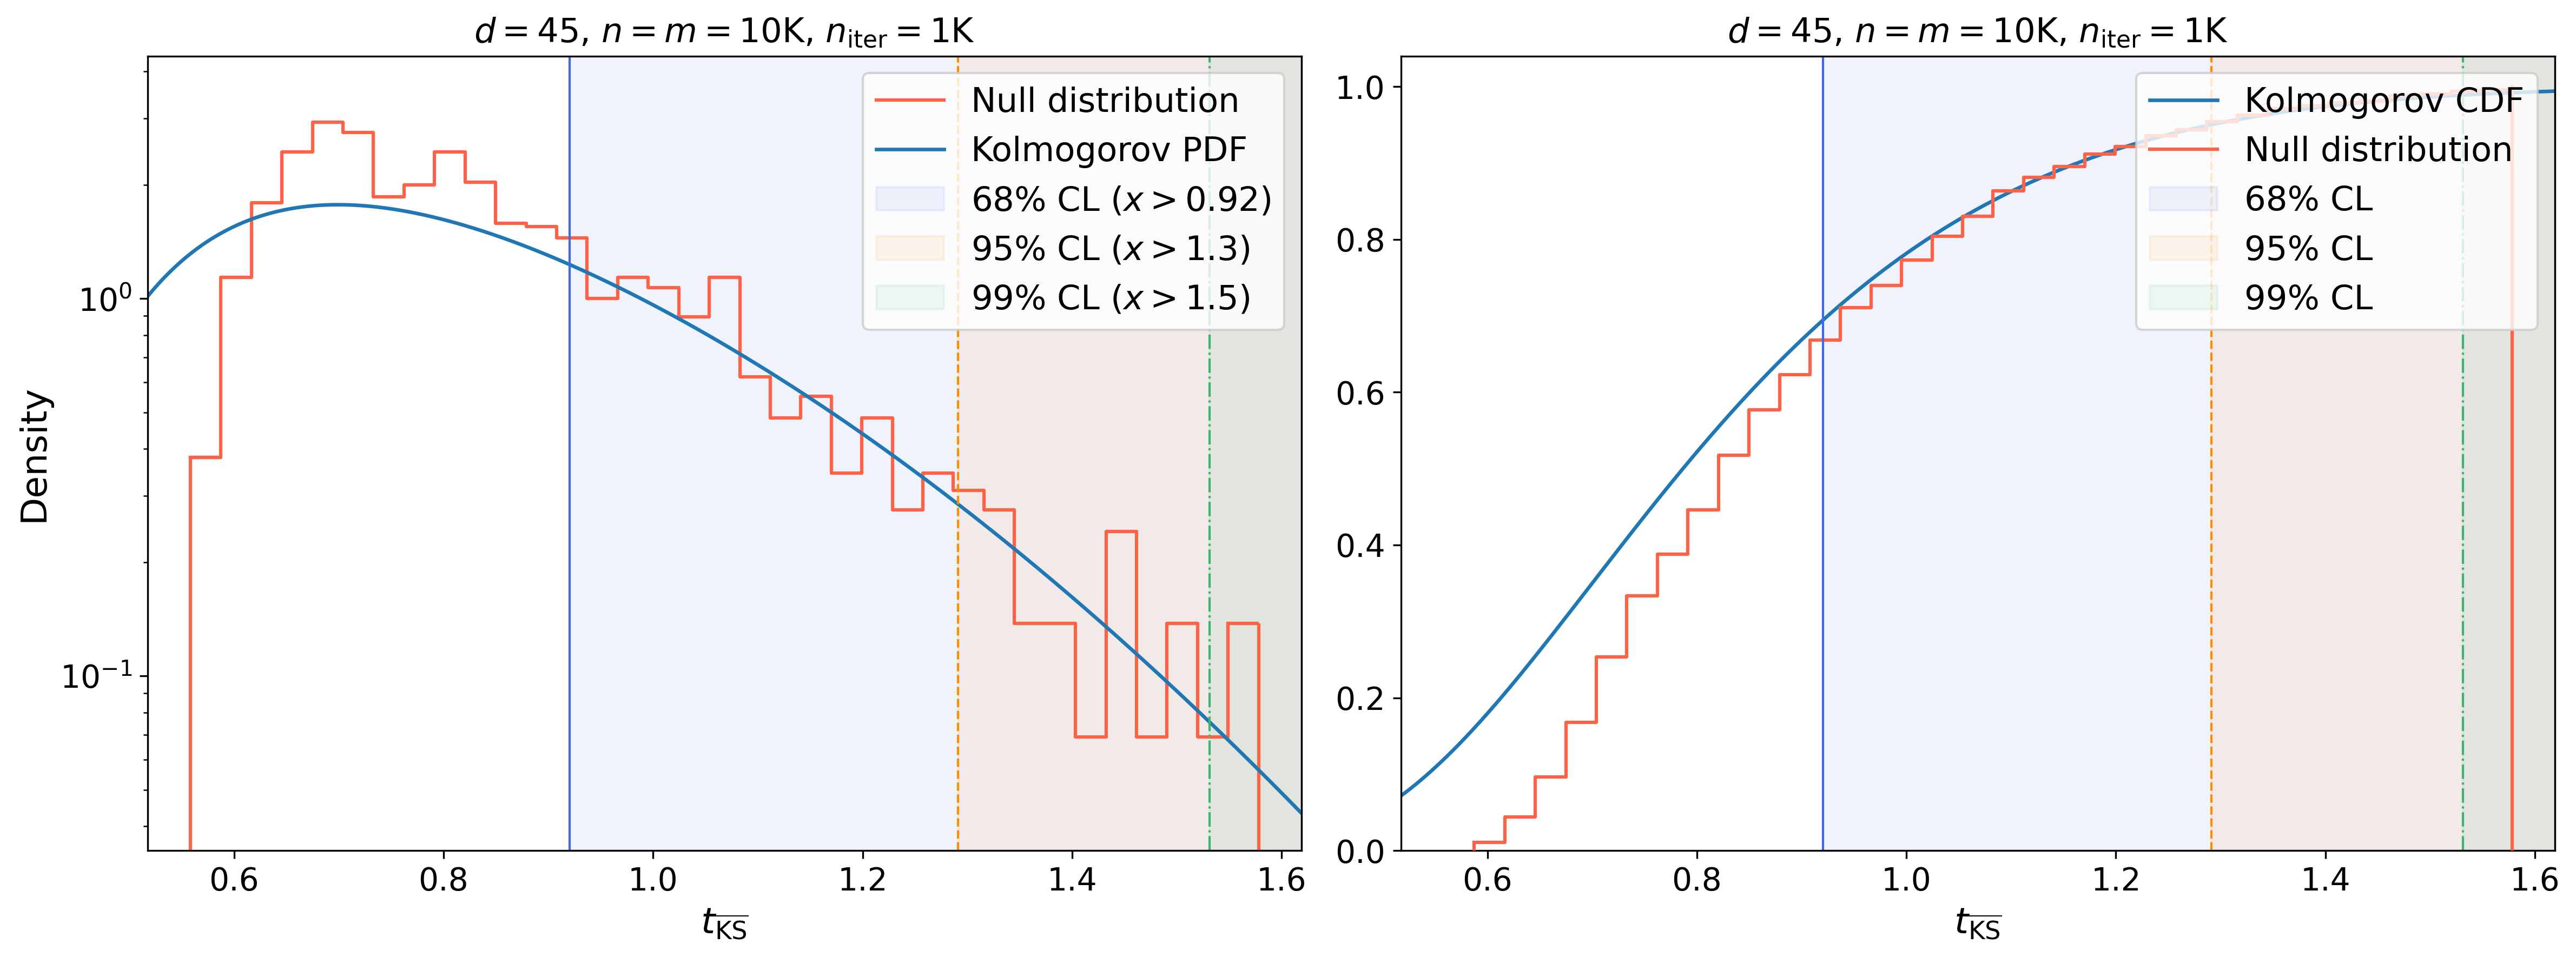

,metric,mean,SE(mean),std,SE(std),Thr68,Thr95,Thr99
0,KS,0.864669,0.006653,0.210382,0.004707,0.920496,1.29102,1.531279


[ks] Time elapsed: 0.77 s



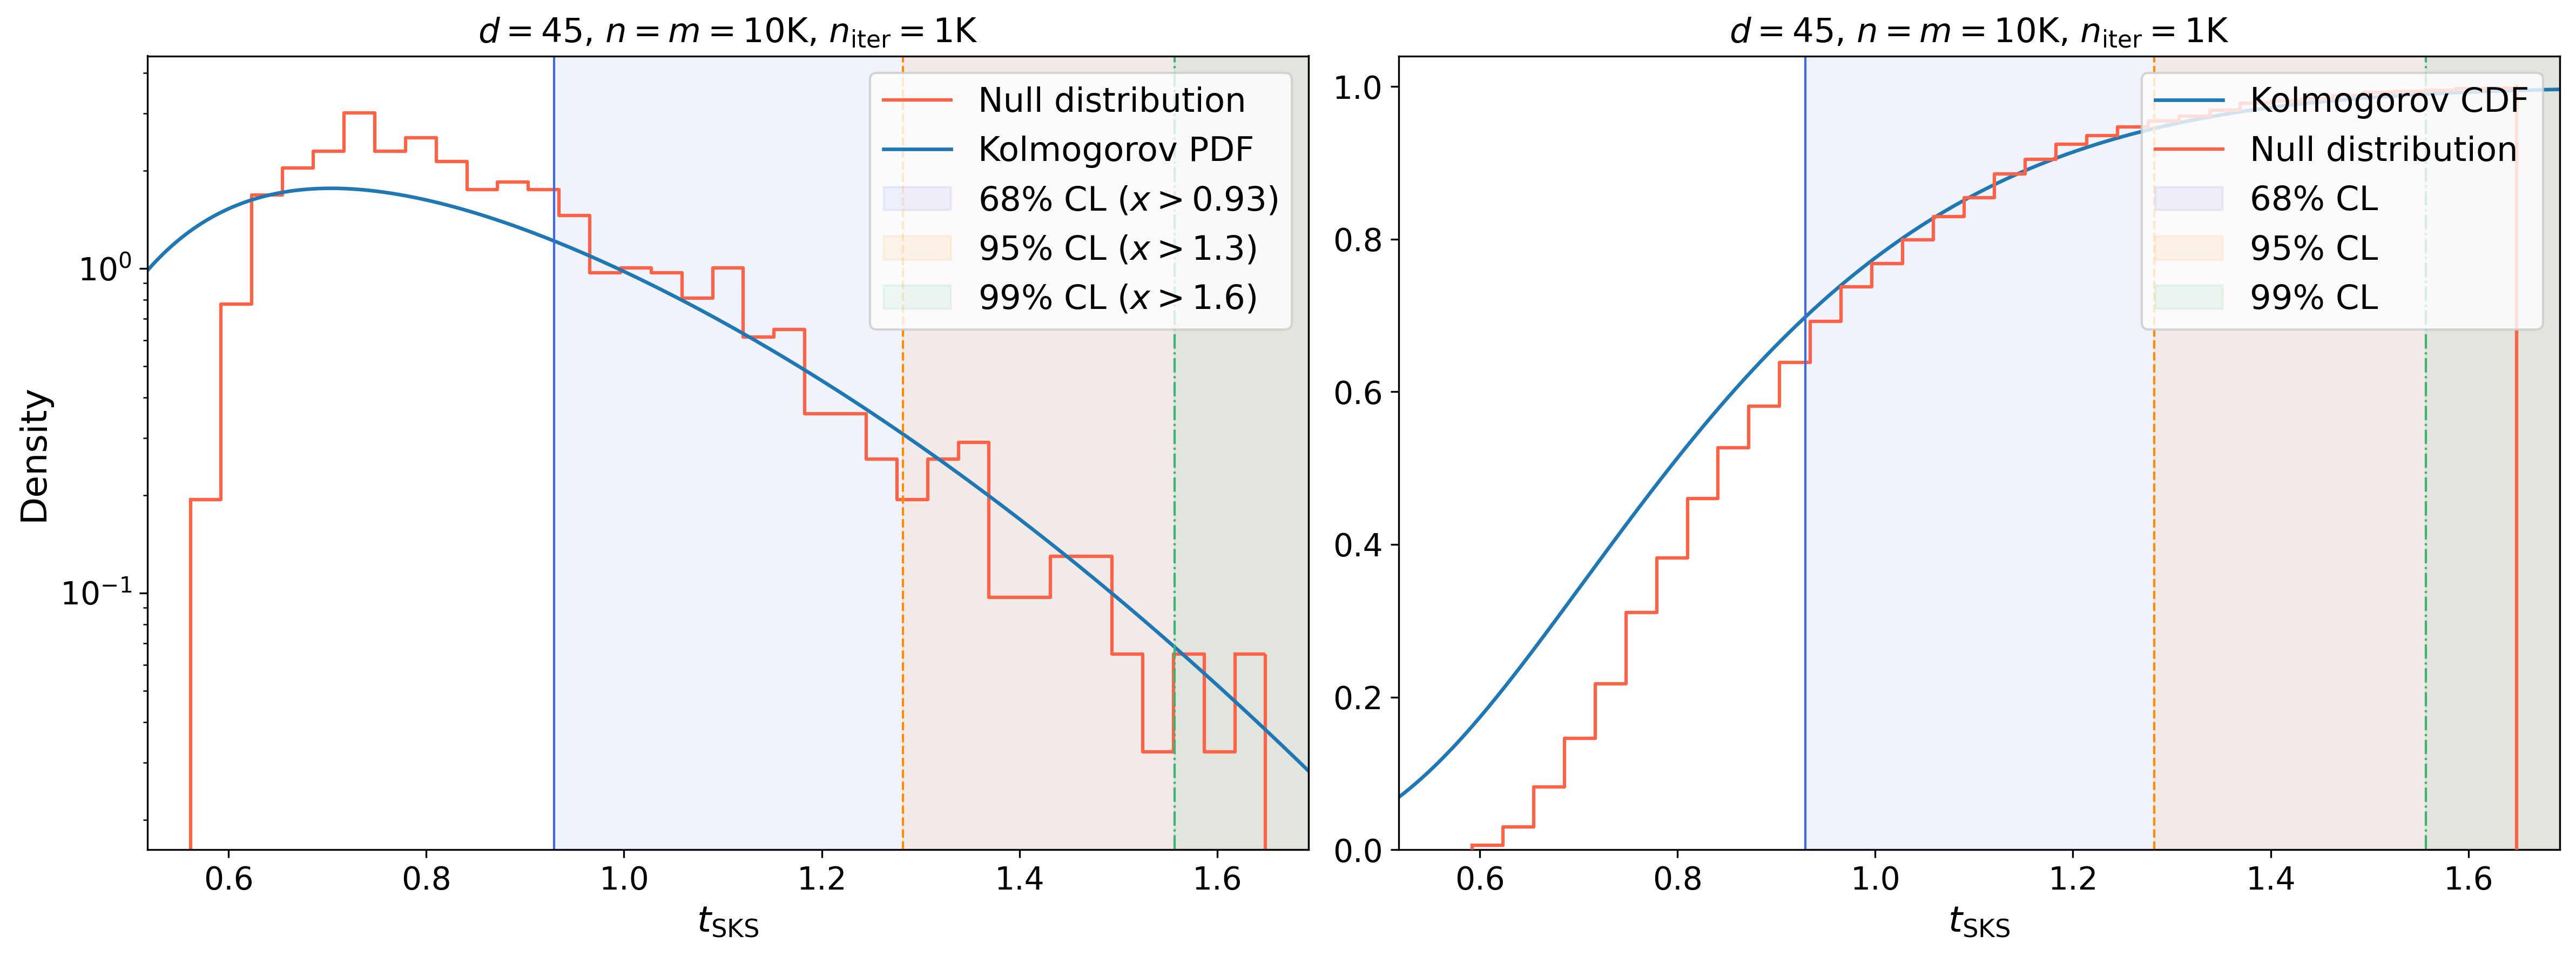

,metric,mean,SE(mean),std,SE(std),Thr68,Thr95,Thr99
0,SKS,0.87831,0.006474,0.204711,0.00458,0.929209,1.282338,1.55712


[sks] Time elapsed: 0.71 s



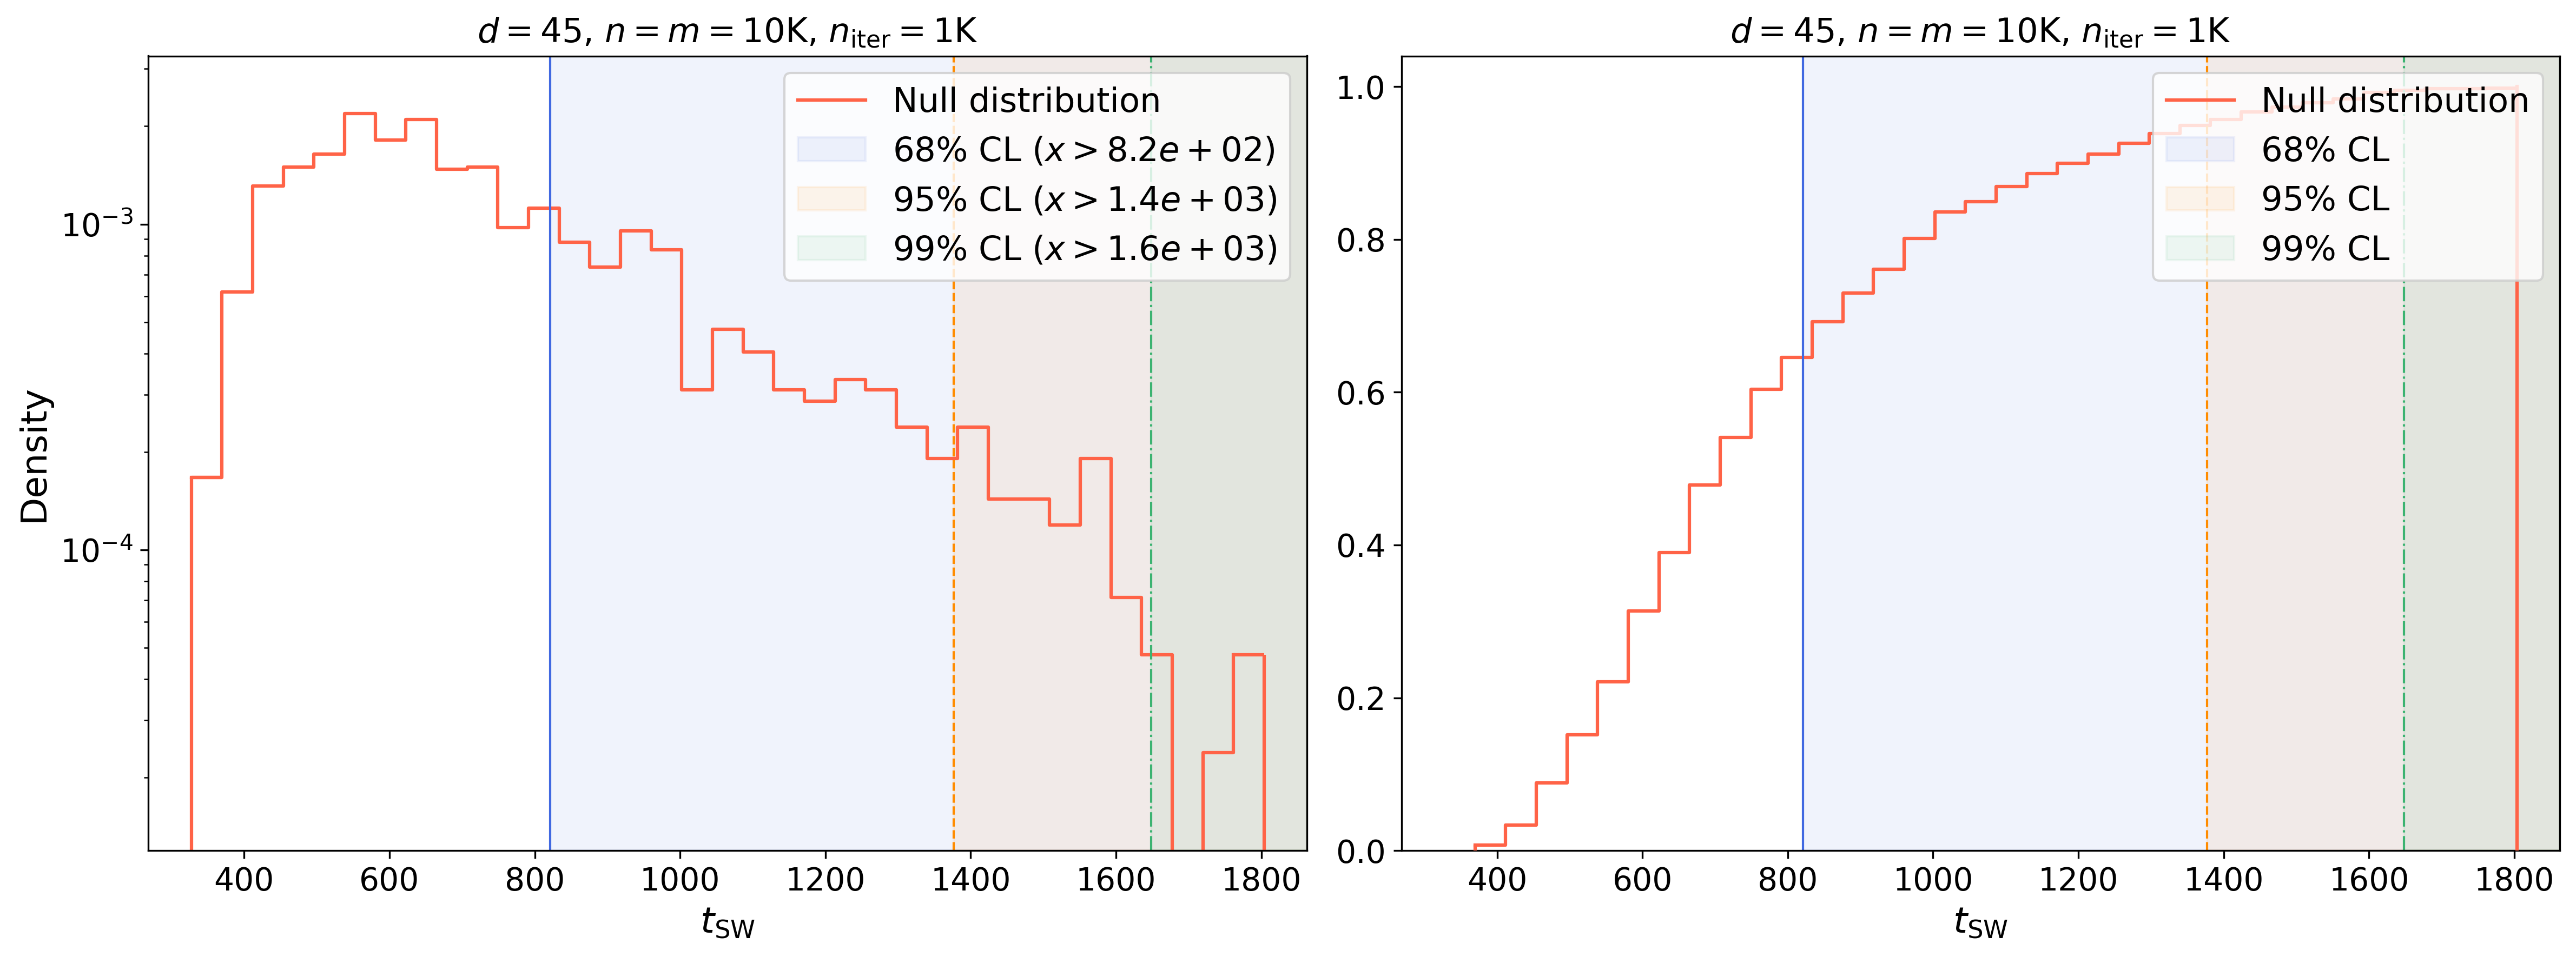

,metric,mean,SE(mean),std,SE(std),Thr68,Thr95,Thr99
0,SWD,760.962345,9.282562,293.540371,6.567047,821.052332,1376.906103,1648.359026


[swd] Time elapsed: 0.68 s



,metric,mean,SE(mean),std,SE(std),Thr68,Thr95,Thr99
0,KS,0.864669,0.006653,0.210382,0.004707,0.920496,1.291020,1.531279
1,SKS,0.878310,0.006474,0.204711,0.004580,0.929209,1.282338,1.557120
2,SWD,760.962345,9.282562,293.540371,6.567047,821.052332,1376.906103,1648.359026


In [ ]:
# === DROP-IN PLOTTING CELL (formal Kolmogorov via kstwobign, unit-matched via thresholds) ===
from timeit import default_timer as timer
import numpy as np, matplotlib.pyplot as plt, pandas as pd
from scipy.stats import kstwobign  # Kolmogorov (asymptotic) distribution

def se_mean(x):
    return np.std(x, ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan

def se_std(x):
    n = len(x); s = np.std(x, ddof=1)
    return s / np.sqrt(2*(n-1)) if n > 1 else np.nan

def _dedup_legend(ax, **kwargs):
    h, l = ax.get_legend_handles_labels()
    seen=set(); H=[]; L=[]
    for hi, li in zip(h,l):
        if li not in seen:
            seen.add(li); H.append(hi); L.append(li)
    ax.legend(H, L, **kwargs)

all_stats_rows = []

for metric in metrics_config[unique_key].values():
    name        = metric["name"]
    name_low    = str(name).lower()
    obj         = eval(metric["object_name"])
    result_key  = metric["result_key"]
    scale_func  = metric["scale_func"]
    figure_file = metric["null_file"].replace("json", "pdf")
    thresholds  = metric["thresholds"]
    latex       = metric["latex"]

    start = timer()

    nsamples = int(obj.Inputs.batch_size_test)
    niter    = int(obj.Inputs.niter)
    nd       = int(ndims)
    ns       = nsamples // 2  # n_eff for two-sample KS when n=m

    dist_null = np.asarray(obj.Results[-1].result_value[result_key], dtype=float)
    dist_null = dist_null * float(scale_func(ns, nd))  # e.g. sqrt(n_eff) for KS

    # Display-only scaling
    scale_factor = 1.0
    if "FGD" in latex:
        scale_factor = 1e-7
        latex = r"$t_{\mathrm{FGD}}\,(\times 10^{-7})$"
    elif "MMD" in latex:
        scale_factor = 1e5
        latex = r"$t_{\mathrm{MMD}}\,(\times 10^{5})$"

    dist_plot = dist_null * scale_factor
    scaled_thresholds = [(cl, idx, thr * scale_factor) for (cl, idx, thr) in thresholds]

    # Summary stats
    mu, mu_se = float(np.mean(dist_plot)), float(se_mean(dist_plot))
    sd, sd_se = float(np.std(dist_plot, ddof=1)), float(se_std(dist_plot))

    row = {"metric": name.upper(), "mean": mu, "SE(mean)": mu_se, "std": sd, "SE(std)": sd_se}
    for cl, _, thr in scaled_thresholds:
        row[f"Thr{int(cl*100)}"] = float(thr)
    all_stats_rows.append(row)

    # Histogram + eCDF on same bins
    clip_q = 0.995
    x_min_data = float(np.min(dist_plot))
    x_max_data = float(np.max(dist_plot))
    x_clip     = float(np.quantile(dist_plot, clip_q))
    x_thr_max  = max([thr for (_, _, thr) in scaled_thresholds], default=x_clip)
    x_min = x_min_data
    x_max = max(x_clip, x_thr_max)

    num_bins          = 35
    counts, bin_edges = np.histogram(dist_plot, bins=num_bins, range=(x_min, x_max), density=True)
    bin_widths        = np.diff(bin_edges)
    cdf_vals          = np.clip(np.cumsum(counts * bin_widths), 0.0, 1.0)

    xpad = 0.04 * (x_max - x_min) if np.isfinite(x_max - x_min) else 0.0
    x_left, x_right = x_min - xpad, x_max + xpad

    fig, ax = plt.subplots(1, 2, figsize=(16, 6), dpi=300)
    dash_styles = ['-', '--', '-.']
    colors      = ["royalblue", "darkorange", "mediumseagreen"]

    # PDF step + bin closures
    pdf_line = ax[0].step(bin_edges[:-1], counts, where='post', color="tomato",
                          label="Null distribution")[0]
    pdf_style = dict(color=pdf_line.get_color(),
                     linewidth=pdf_line.get_linewidth(),
                     linestyle=pdf_line.get_linestyle(),
                     alpha=pdf_line.get_alpha())
    pos_counts = counts[counts > 0]
    y_base = max(float(pos_counts.min()) * 0.5, 1e-12) if len(pos_counts) else 1e-12
    if len(counts) > 0:
        ax[0].hlines(counts[0], bin_edges[0], bin_edges[1], **pdf_style)
        ax[0].hlines(counts[-1], bin_edges[-2], bin_edges[-1], **pdf_style)
        ax[0].vlines(bin_edges[0], y_base, counts[0], **pdf_style)
        ax[0].vlines(bin_edges[-1], y_base, counts[-1], **pdf_style)

    # === FORMAL Kolmogorov overlays via kstwobign (only for KS-like metrics) ===
    add_kolmogorov = ("ks" in name_low)
    if add_kolmogorov:
        # Estimate scale S so kstwobign is plotted in the SAME units as the x-axis
        S_candidates = []
        for cl, _, thr in scaled_thresholds:
            if 0.5 < cl < 1.0 and np.isfinite(thr):
                z_cl = kstwobign.ppf(cl)  # Kolmogorov quantile
                if np.isfinite(z_cl) and z_cl > 0:
                    S_candidates.append(thr / z_cl)
        if len(S_candidates):
            S = float(np.median(S_candidates))
        else:
            # fallback: match std, then mean
            mu_K  = float(kstwobign.mean())
            sd_K  = float(kstwobign.std())
            S = None
            if np.isfinite(sd) and sd_K > 0:
                S = sd / sd_K
            elif np.isfinite(mu) and mu_K > 0:
                S = mu / mu_K
            if S is None or not np.isfinite(S) or S <= 0:
                S = 1.0

        x0 = max(0.0, x_left)           # support x>=0
        xg = np.linspace(x0, x_right, 600)
        zg = xg / max(S, 1e-12)

        pdf_k = kstwobign.pdf(zg) / max(S, 1e-12)
        cdf_k = kstwobign.cdf(zg)

        ax[0].plot(xg, np.clip(pdf_k, y_base, None),
                   label="Kolmogorov PDF", linewidth=1.6)
        ax[1].plot(xg, np.clip(cdf_k, 0.0, 1.0),
                   label="Kolmogorov CDF", linewidth=1.6)

    # Axes + limits
    ax[0].set_yscale('log')
    ax[0].set_xlabel(latex, fontsize=16)
    ax[0].set_ylabel('Density', fontsize=16)
    ax[0].set_title(rf"$d = {nd}$, $n=m={nsamples//1000}$K, $n_{{\mathrm{{iter}}}}={niter//1000}$K", fontsize=15)
    ax[0].set_xlim(x_left, x_right)
    if len(pos_counts):
        y_lo = max(min(pos_counts) * 0.5, 1e-12)
        y_hi = max(pos_counts) * 1.5
    else:
        y_lo, y_hi = 1e-12, 1.0
    if add_kolmogorov:
        try: y_hi = max(y_hi, float(np.nanmax(pdf_k)) * 1.5)
        except Exception: pass
    if y_hi <= y_lo: y_hi = y_lo * 10.0
    ax[0].set_ylim(y_lo, y_hi)

    # Threshold shading
    for i, (cl, _, thr) in enumerate(scaled_thresholds):
        ax[0].axvspan(thr, x_right, color=colors[i % len(colors)], alpha=0.08,
                      label=f"{int(cl*100)}% CL ($x>{thr:.2g}$)")
        ax[0].axvline(thr, linestyle=dash_styles[i % len(dash_styles)],
                      color=colors[i % len(colors)], linewidth=1)
    _dedup_legend(ax[0], loc='upper right', fontsize=15)

    # eCDF
    ecdf_line = ax[1].step(bin_edges[1:], cdf_vals, where='post', color="tomato",
                           label="Null distribution")[0]
    if len(cdf_vals) > 0:
        ax[1].vlines(bin_edges[1], 0.0, cdf_vals[0], color="tomato", zorder=3)
        ax[1].vlines(bin_edges[-1], 0.0, cdf_vals[-1], color="tomato", zorder=3)

    ax[1].set_ylim(0.0, 1.0 + 0.04)
    ax[1].set_xlim(x_left, x_right)
    ax[1].set_xlabel(latex, fontsize=16)
    ax[1].set_title(rf"$d = {nd}$, $n=m={nsamples//1000}$K, $n_{{\mathrm{{iter}}}}={niter//1000}$K", fontsize=15)

    for i, (cl, _, thr) in enumerate(scaled_thresholds):
        ax[1].axvspan(thr, x_right, color=colors[i % len(colors)], alpha=0.08,
                      label=f"{int(cl*100)}% CL")
        ax[1].axvline(thr, linestyle=dash_styles[i % len(dash_styles)],
                      color=colors[i % len(colors)], linewidth=1)
    _dedup_legend(ax[1], loc='upper right', fontsize=15)

    for a in ax:
        a.tick_params(axis='x', labelsize=14)
        a.tick_params(axis='y', labelsize=14)

    plt.tight_layout()
    plt.savefig(figure_file)
    plt.show()
    plt.close()

    # Per-metric table
    df_one = pd.DataFrame([row])
    order = ["metric", "mean", "SE(mean)", "std", "SE(std)"] + [c for c in df_one.columns if c.startswith("Thr")]
    df_one = df_one[order]
    try:
        display(df_one)
    except Exception:
        print(df_one.to_string(index=False))

    metric.update({"null_figure": figure_file})
    print(f"[{name}] Time elapsed: {timer() - start:.2f} s\n")

# Global table
df_all = pd.DataFrame(all_stats_rows)
if len(df_all):
    order = ["metric", "mean", "SE(mean)", "std", "SE(std)"] + [c for c in df_all.columns if c.startswith("Thr")]
    df_all = df_all[order]
    try: display(df_all)
    except Exception: print(df_all.to_string(index=False))
else:
    print("No rows to display in the global table.")


## observed statistichs

In [ ]:
orig_true = layer_true.copy()
orig_gen = layer_gen.copy()
rng1 = np.random.default_rng(12345)
rng2 = np.random.default_rng(56789)
shuffled_true = orig_true[rng1.permutation(orig_true.shape[0])]
shuffled_gen = orig_gen[rng2.permutation(orig_gen.shape[0])]
input_layer_true = EmpiricalNumpyDistribution(shuffled_true.copy(), dtype=np.float32)
input_layer_gen = EmpiricalNumpyDistribution(shuffled_gen.copy(), dtype=np.float32)

In [ ]:
cache = model_dir + "/alternative_hypothesis/alt_hyp_total_layer_energies_10k_100"
observed = utils_eval.compute_observed_distributions(
    metrics_config, unique_key,
    dist_1_num=input_layer_gen,
    dist_2_num=input_layer_true,
    ndims=ndims,
    batch_size_test=batch_size_test,
    niter_obs=1000,
    dtype=tf.float64, use_tf=False, verbose=True,
    cache_file=cache, overwrite=False, show_progress=True
)

[compute_observed_distributions] Loaded cached results from: ./53/total_layer_energy_batchsize_10k_100//alternative_hypothesis/alt_hyp_total_layer_energies_10k_100


[warn] Found 3 metrics, fewer than expected_num_metrics=5.
[GRID] saved ./53/total_layer_energy_batchsize_10k_100/null_vs_alt/config_ndims_45_nsamples_10000_niter_1000_null_vs_alt_PDF_grid_3.pdf


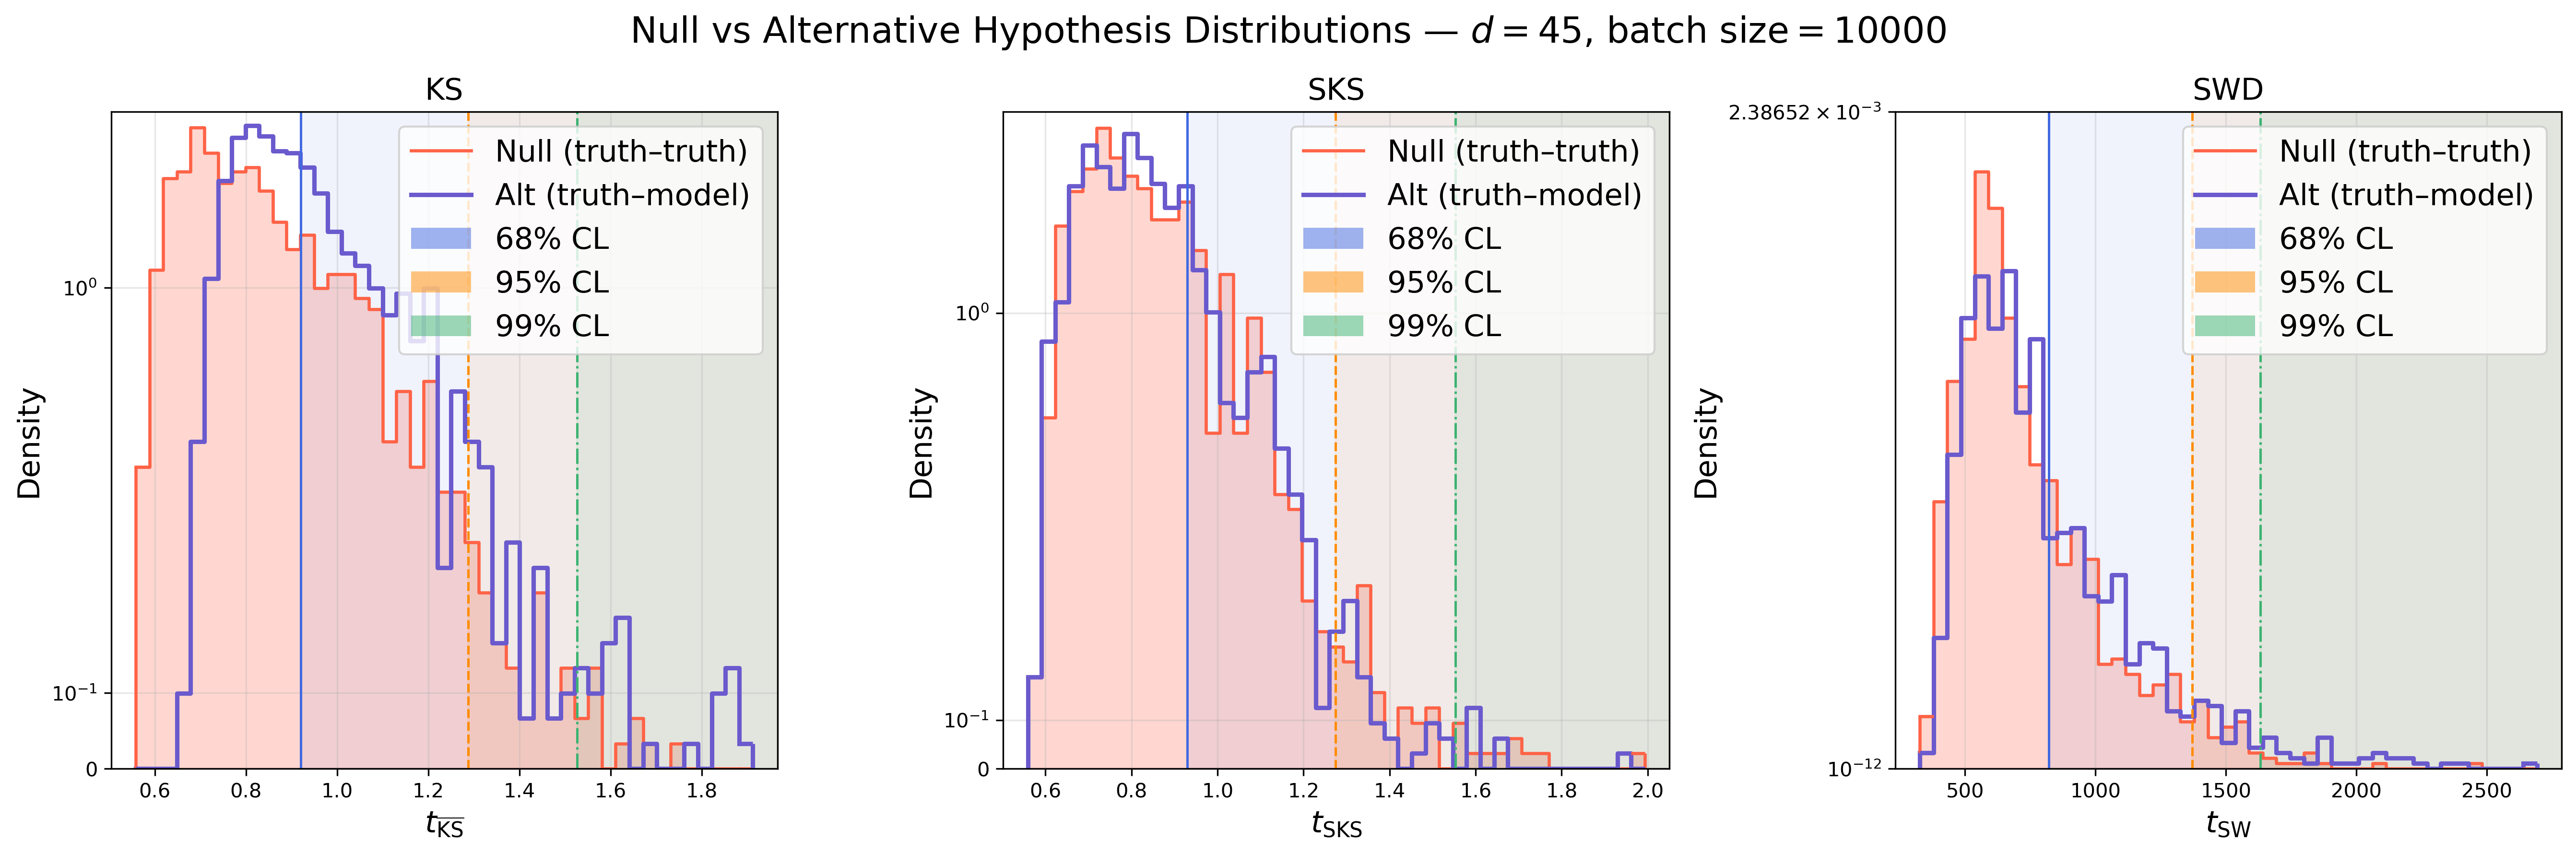

In [ ]:
import eval_plotters
reload(eval_plotters)

# 2) Plot null vs alt (one PDF per metric with CL lines and rejection rates)
eval_plotters.plot_null_vs_alt_pdf(
    metrics_config = metrics_config,
    unique_key     = unique_key,
    observed       = observed,
    ndims          = ndims,
    save_dir       = os.path.join(model_dir, "null_vs_alt/"),
    num_bins=45,
    fill_null=True,
    null_alpha=0.25,
    ypad_frac=0.10,
    show_null_fill_legend = False,
    # FGD
    fgd_x_scale = "linear", fgd_x_linthresh = None,
    fgd_y_scale = "symlog", fgd_y_linthresh = 1e-1,
    # MMD
    mmd_x_scale = "linear", mmd_x_linthresh = 1e-3,
    mmd_y_scale = "symlog", mmd_y_linthresh = 1e-1,
    # KS
    ks_x_scale = "linear", ks_x_linthresh = None,
    ks_y_scale = "symlog", ks_y_linthresh = 5e-1,
    # SKS
    sks_x_scale = "linear", sks_x_linthresh = None,
    sks_y_scale = "symlog", sks_y_linthresh = 9e-1,
    # SWD
    swd_x_scale = "linear", swd_x_linthresh = None,
    swd_y_scale = "symlog", swd_y_linthresh = 9e-2,
    fgd_disp_scale = 1e-8,
    mmd_disp_scale = 1.0,
    ks_disp_scale = 1.0,
    sks_disp_scale = 1.0,
    swd_disp_scale = 1.0,
    show_scale_in_label = True,  # append "(×10^{k})" to xlabel if scale ≠ 1
    plotting_mode="multiple",
    expected_num_metrics=5,  # set what you expect
    batch_size_test=batch_size_test,
)


## computig pvalue

In [ ]:
cache = "./" + str(run_number) + "/pvalues/pvalues_phys_feat/layer_energy_10k.csv"
df_pvals, pvals = utils_eval.compute_pvalues_table(
    metrics_config=metrics_config,
    unique_key=unique_key,
    observed=observed,
    ndims=ndims,
    agg="median",        # or "mean"
    tail="right",        # or "left" / "two-sided"
    save_csv=cache,
    verbose=True,
)


metric,niter,batch_size,nslices,p_value,time_sec
KS,1000,10000,-,0.33,-
SKS,1000,10000,100.0,0.496,-
SWD,1000,10000,100.0,0.419,-


## explainin why p >0.5

Below is a deep, thesis‑level explanation of why (even with the null built correctly as truth–truth and the alternative as truth–model) the median of the alternative distribution can come out LOWER than the median of the null distribution for the metrics you use (KS, SKS, SWD). I preserve your current aggregation choice (median) since you said it is already introduced in the thesis.

---

## 1. Core idea in one sentence

You are comparing a “smoothed” (median‐aggregated) test statistic from the alternative replicates to unsmoothed, noisier single replicates from the null; that asymmetry plus structural properties of the model (variance shrinkage / tail suppression) and high‑dimensional projection effects can legitimately make the alternative aggregated value sit left of (smaller than) the distribution of per‑replicate null values.

---

## 2. Decomposing a two‑sample test statistic

For a typical two‑sample metric \(T\) (KS, sliced Wasserstein, sliced KS, etc.) computed on two samples of size \(n\) and \(n\) from distributions \(F\) (truth) and \(G\) (model), you can conceptually write a single replicate of the statistic under the alternative as:

\[
T_{\text{alt, replicate}} \approx \underbrace{S(F,G)}_{\text{structural difference}} + \underbrace{N}_{\text{sampling noise}}
\]

and under the null (truth vs truth) as:

\[
T_{\text{null, replicate}} \approx \underbrace{0}_{\text{no true shift}} + \underbrace{N'}_{\text{sampling noise (different draw)}}
\]

If the structural difference term \(S(F,G)\) is small or partly cancels with aspects of the noise (more on that below), an *aggregated* alternative statistic such as the median of many replicates can fall below typical single null replicates.

---

## 3. Aggregation asymmetry: median vs raw replicates

### What you do:
- Alternative: You generate many (e.g. 1000) replicate values, then take the **median** \( \tilde{T}_{\text{alt}} = \text{median}\{T_{\text{alt, replicate}, i}\}\).
- Null: You compare \( \tilde{T}_{\text{alt}} \) directly to the raw null replicate cloud \( \{T_{\text{null, replicate}, j}\}\).

### Why this matters:
The median acts as a *variance and extremal shrinker*. Empirically:

- For any positive random variable with right skew (typical for sup- or distance-based statistics), the distribution of the median of \(k\) iid draws is tighter and its central location can shift **left** relative to the mean or typical single draws.
- Your null distribution still reflects single‐replicate *supremum* fluctuations (which can be naturally wide), while the alternative median filters out replicate‐to‐replicate extremes.
- Because the supremum functional (e.g. \(\sup_x |F_n(x)-G_n(x)|\) for KS) is non‑linear and accentuates outliers, removing those outliers via a median produces a systematic downward shift.

Thus even if the *per‑replicate* alternative distribution were stochastically larger than null, taking the median before comparison can partly undo that. If the structural shift \(S(F,G)\) is moderate, the shrinkage can dominate and place \(\tilde{T}_{\text{alt}}\) below many null replicates.

---

## 4. Model variance shrinkage (“smoothing” / mild mode collapse)

Suppose the learned model distribution \(G\) is **narrower** or smoother than the true distribution \(F\):

- Null (truth vs truth): Two independent samples from \(F\) both inherit full tail variability and may produce larger slice‑wise or layer‑wise local deviations (sampling noise generates wide empirical fluctuations).
- Alternative (truth vs model): One side (model sample) lacks some extreme tails or high‑variance microstructure. Counter‑intuitively, for *noise-dominated metrics* this can *reduce* the observed distance:
  - The stochastic envelope of differences \(|F_n - G_n|\) is partly the sum of two empirical process fluctuations. If the model sample’s empirical process is “tighter,” the combined fluctuation width can be *smaller* than two truth processes opposing each other.
  - In KS terms, the statistic under H0 behaves like \(\sup_x |B_1(x) - B_2(x)|\) where \(B_i\) are Brownian bridges; under a variance‑shrunk model one bridge has smaller amplitude. When the genuine shift \(\Delta(x) = F(x)-G(x)\) is small relative to this reduction in noise, the supremum can shrink.

This yields a paradox: slight mode collapse can push the *right‑tail* divergence metric DOWN, not up, if the metric is more sensitive to empirical fluctuation width than to the subtle deterministic shift.

---

## 5. High-dimensional concentration and sliced projections

For SKS/SWD which rely on random slices/projections:

- In moderately high dimension (even 45 components), most random linear projections land near directions of *average* behaviour.
- If the model is “center-clustered,” the projected 1D distributions of truth vs model can appear *closer* than two independent truth projections, because both samples from truth may separately explore tails that the model does not, and those independent tail excursions in two truth samples increase slice-to-slice variation of the null statistic.
- Taking the median across many slice sets further damps occasional large slice distances that would have distinguished the alternative.

Result: The *distribution of per-slice discrepancies* can be wider for truth–truth than truth–model when the model suppresses variance, pushing the aggregated alternative lower.

---

## 6. Discretization / layer energy granularity

Layer energies (45 components) often have:
- Discrete or quasi-discrete peaks
- Inter-layer correlations

Two independent truth samples can disagree on which sparse high-energy bins they hit, inflating sup or sliced distances. If the model under-represents those rare bins, both truth and model samples cluster more in shared moderate bins—reducing per-replicate differences in typical slices and lowering the aggregated measure.

---

## 7. Scale functions and normalization choices

You apply scale functions like \(\sqrt{n_\text{eff}}\) or \(\sqrt{n_\text{eff}/d}\). Those assume classical asymptotic fluctuation magnitudes under *matching* variances. If the model has smaller effective variance, scaling by \(\sqrt{n_\text{eff}}\) can **over-correct** the alternative (multiply a smaller raw discrepancy by the same factor), while null replicates—containing full variance—remain larger after the same scaling. Again, the alternative median can lie left.

---

## 8. Sign / definition subtleties (metric “means” vs “list”)

Metrics stored as `statistic_means` or `metric_means` are already **averages per replicate** inside GMetrics. Your external median adds another averaging layer. The null: single replicate mean (not median across replicates) retains the occasional higher “mean-of-replicate” excursions due to random slice sets. Alternative: median-of-replicate-means compresses the right tail further.

---

## 9. Mathematical sketch for KS shrinkage

Let \(D_n = \sup_x |F_n(x)-G_n(x)|\).

Under H0 (F=G) classical results:
\[
\sqrt{n} D_n \xrightarrow{d} K \quad (K: \text{Kolmogorov distribution})
\]

Under mild alternative with small shift \(\Delta(x)=F(x)-G(x)\):
\[
D_n \approx \sup_x |\Delta(x) + \varepsilon_n(x)|
\]
where \(\varepsilon_n(x)\) is noise of order \(1/\sqrt{n}\).

If \(\Delta(x)\) is concentrated (e.g. nonzero mainly in thin tails the model removes), the supremum may occur at a location where \(\varepsilon_n\) under null tends to be large, but under the “variance-shrunk” model path \(\varepsilon'_n\) has smaller amplitude.

If you take the **median** over 1000 iid copies of \(D_n\) with small deterministic \(\Delta\), the median behaves like
\[
\text{Med}(D_n) \approx \text{Med}(\|\varepsilon'_n\|_\infty)
\]
while the null set you compare to approximates draws of \(\|\varepsilon_n\|_\infty\) (larger). Hence median alternative < many null replicates.

---

## 10. Directionality of the tail you chose

You’re using a right-tailed p-value: p = P(null ≥ observed). If the observed statistic is smaller (for the reasons above), the right-tailed p-value will be large (>0.5). This is *expected* under the scenario “difference manifests as a reduction in stochastic spread” rather than an increase in the metric’s scale.

If, conceptually, “smaller than null” also signals a model–truth discrepancy (e.g. model variance collapse), a left-tailed or two-sided test would produce small p-values, but since the thesis already fixes tail="right", you just interpret large p-values as “no evidence of the *increase-type* discrepancy,” while noting separately the variance-suppression phenomenon.

---

## 11. Empirical diagnostics to reinforce your justification

You can include in the thesis some simple reported quantities:

1. Compare per-replicate variances:
   - Var(null replicates) vs Var(alternative replicates) for each metric.
2. Quantile compression:
   - Show that Q90(null) - Q10(null) > Q90(alt) - Q10(alt).
3. Tail occupancy:
   - Fraction of truth events in extreme layer-energy bins vs fraction of model events (model likely underpopulates extremes).
4. Slice dispersion:
   - For SKS/SWD: mean slice distance and its standard deviation over slices for null vs alternative (null slices show larger dispersion).

These back up the narrative statistically.

---

## 12. Recommended wording for the thesis

You can phrase it like this (feel free to adapt verbatim or paraphrase):

“In the layer-energy setting we aggregate the per-replicate two-sample statistics by their median, while the empirical null distribution comprises single-replicate values. This introduces a variance reduction on the alternative side. Moreover, the trained generative model exhibits variance shrinkage and suppressed tail occupancy relative to the truth sample. Two independent truth resamples therefore create a broader envelope of empirical process fluctuations than the truth–model pairing. Because the KS/SKS/SWD statistics blend structural shifts with sampling variability, the alternative median can fall below the typical null replicate. Under our right-tailed convention (‘large value = difference’) such cases yield large p-values. This is not a bug but a manifestation of the discrepancy type: the model’s deviation reduces the fluctuation scale instead of enlarging the distance functional.”

---

## 13. When is this not acceptable?

If the structural discrepancy is *supposed* to increase these metrics (e.g., the model misses tail mass so KS should rise), persistent alternative < null suggests:
- Metric sensitivity dominated by sampling noise
- Or severe mode collapse reducing empirical process variability

You can then justify focusing on complementary metrics (e.g. raw tail probability comparisons, energy moment ratios) that respond monotonically to variance shrinkage.

---

## 14. Optional simulation paragraph (if you want a figure)

Simulate 1D: truth = mixture of two Gaussians (wider tails), model = single central Gaussian with same mean. Draw n=1000 samples; compute KS per replicate for 1000 replicates for both (truth–truth and truth–model). The per-replicate KS for truth–truth has heavier right tail (two independent heavy tails). Taking the median of the truth–model replicates yields a statistic below the median of the raw truth–truth replicates. This illustrates variance-induced downward shift.

---

## 15. Summary bullets (handy for a section ending)

- Alternative median < null median can occur with aggregation asymmetry (median vs single)
- Variance shrinkage / tail suppression in the model reduces sample noise amplitude
- High-dimensional random slicing further dampens observed distances
- Scale functions do not adjust for reduced model variance, preserving the asymmetry
- Right-tailed p-values then exceed 0.5 without indicating a calculation error
- Interpreting large p-values must consider the direction: metric designed for “inflation” type differences, not “contraction” differences.

---

If you’d like, I can help you draft the exact thesis subsection or generate a quick simulation cell. Just let me know your preference.

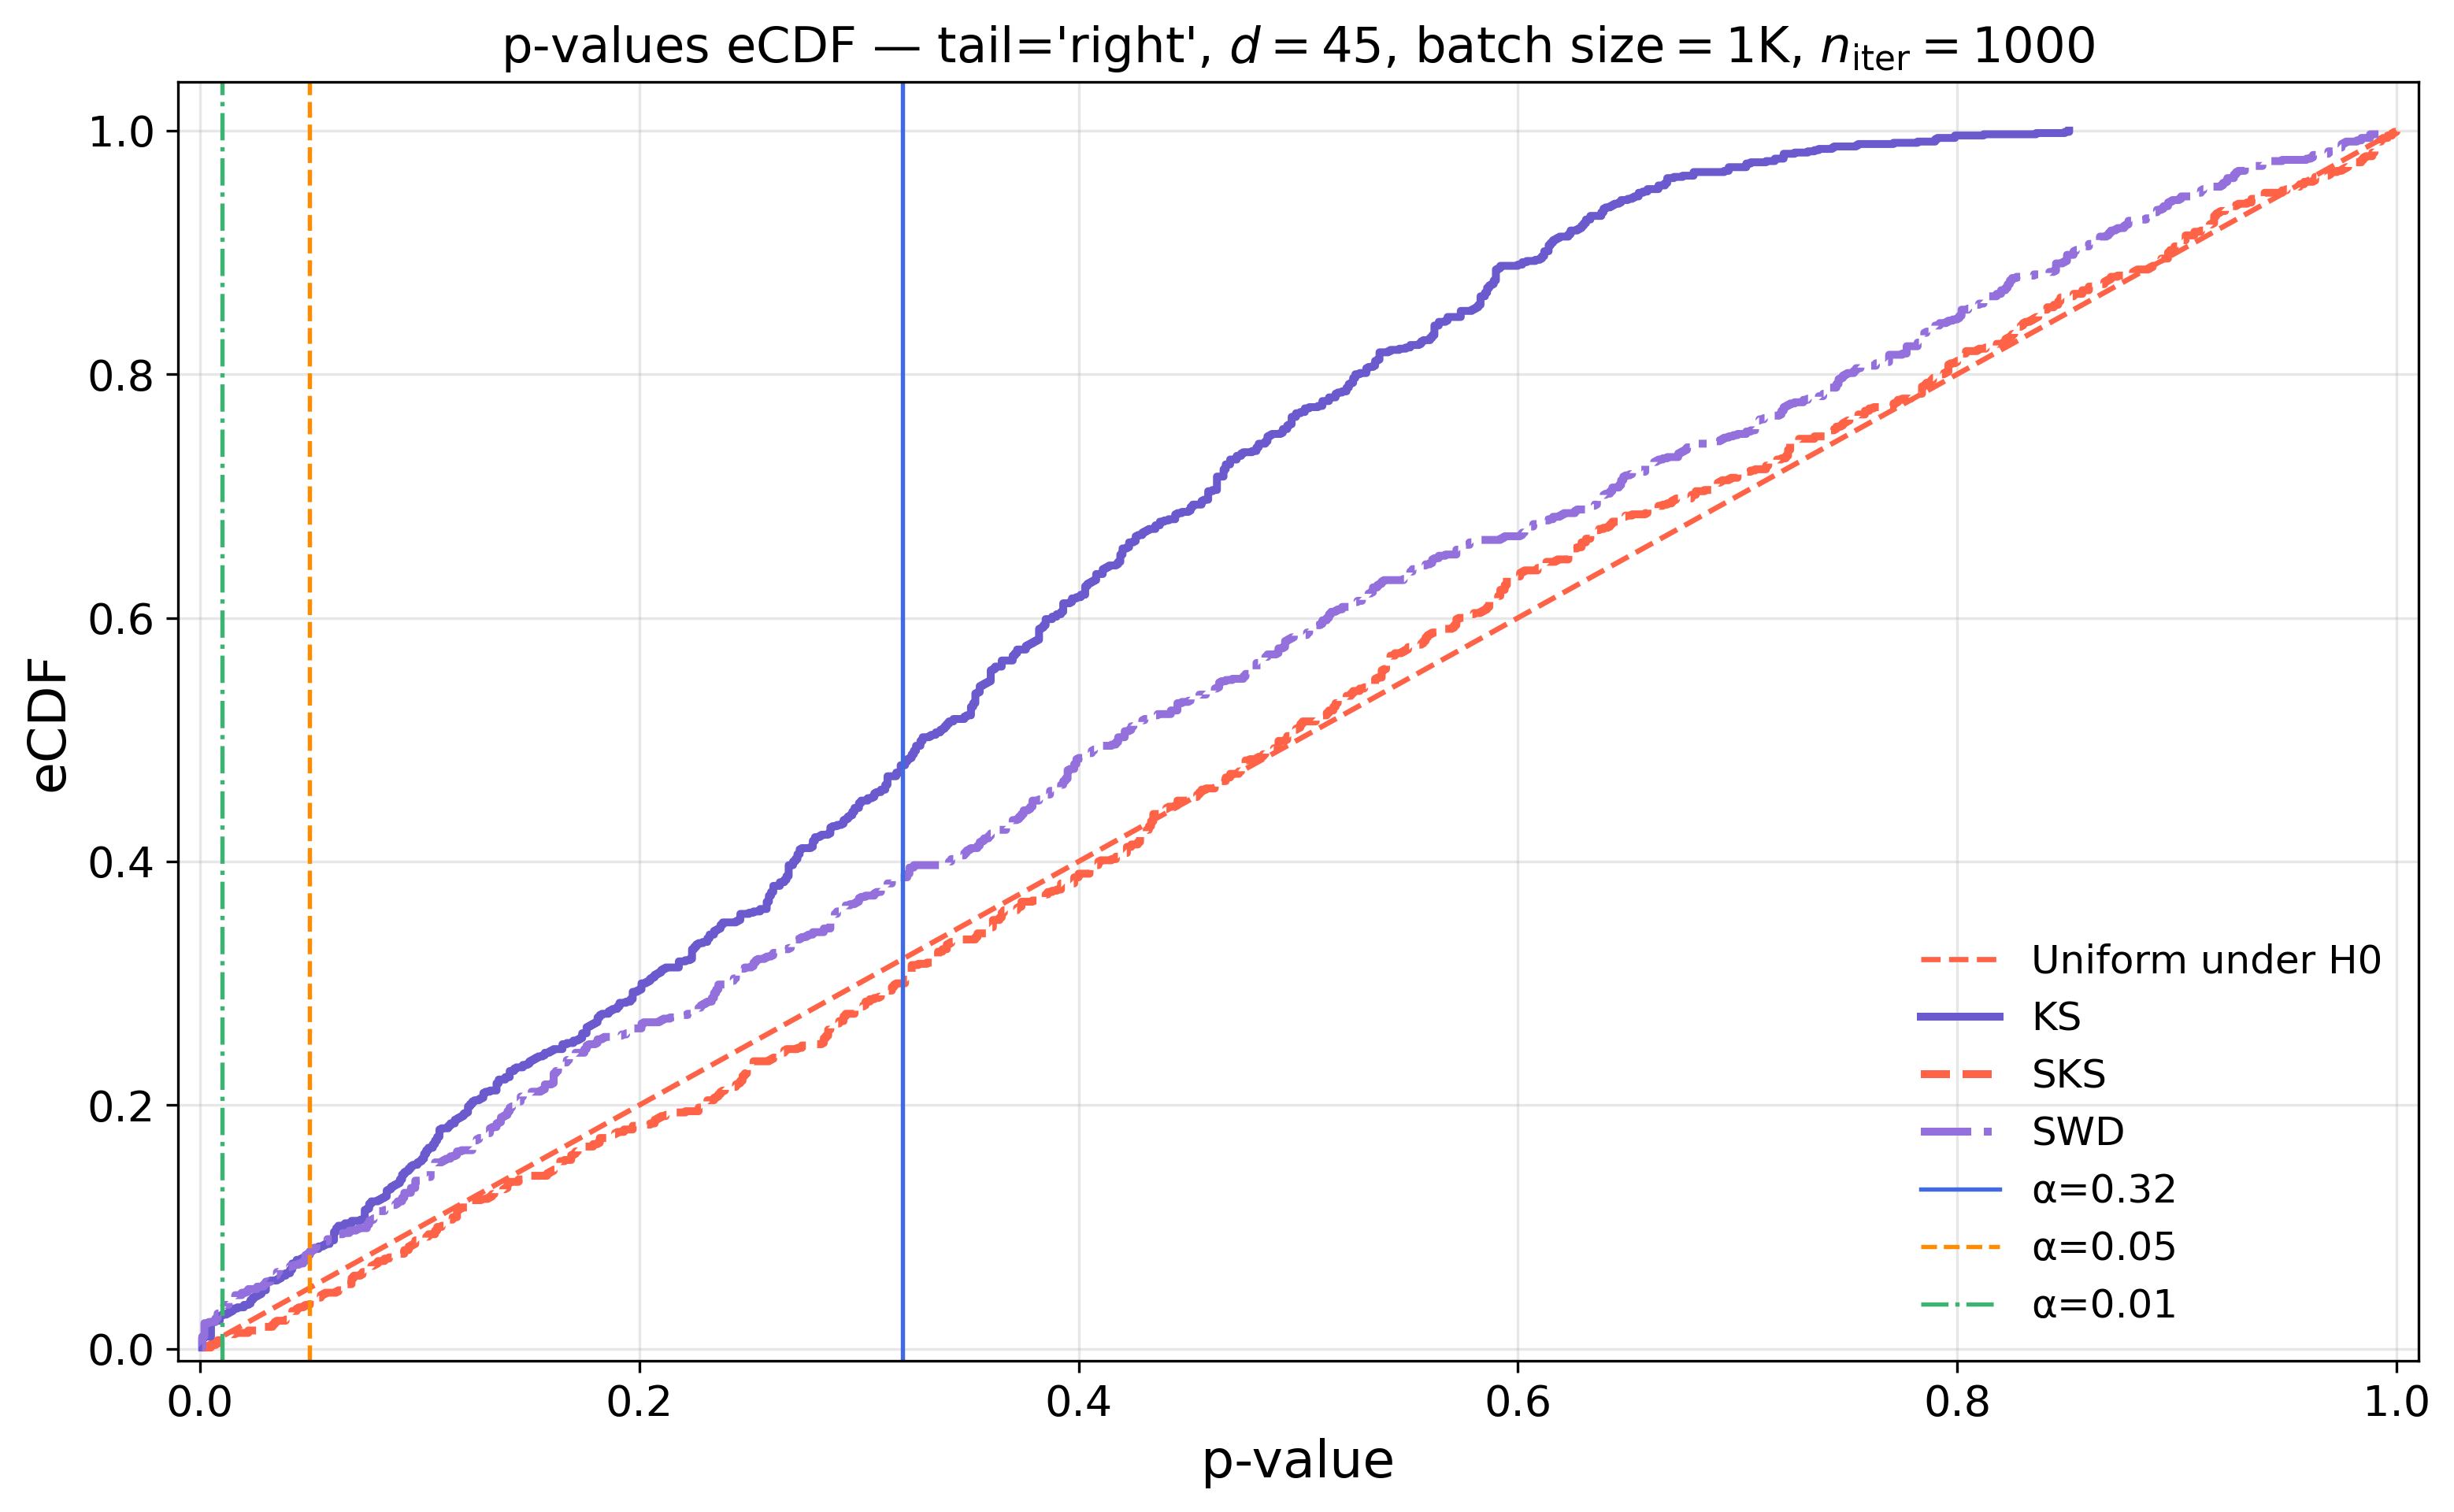

In [ ]:
_ = eval_plotters.compute_and_plot_alt_pvalues(
    metrics_config,
    unique_key,
    observed,
    ndims,
    save_dir=None,
    num_bins = 40,
    top_pad_ecdf = 0.04,
    plot_kind = "cdf")

# Evaluating Full shower 1k 7k

## directory path

In [ ]:
#model_dir = "./53/"
model_dir = os.path.join("./", str(run_number) + "/Full_showers_eval_tf_batchsize_1k_nslices_7k/")
if os.path.exists(model_dir):
    print("Model directory exists")
else:
    os.makedirs(model_dir)
    print("Model directory was created")
null_hypotheses_dir = model_dir + "null_hypothesis/"
if os.path.exists(null_hypotheses_dir):
    print("Null hypothesis directory exists")
else:
    os.makedirs(null_hypotheses_dir)
    print("Null hypothesis directory was created")
metrics_config_file = model_dir + "metrics_config.json"

## loading data

In [ ]:
import utils_eval
reload(utils_eval)

In [ ]:
input_true, input_gen = utils_eval.load_full_showers(
    results_h5="/teo_fs_fast/users/acosso/Dataset/eval_results_A.hdf5",
    n_events=100_000,             # target events
    ncoarse_per_event=648,    # 648
    dtype="float32",
    events_chunk=1024,            # tune if you want larger or smaller memory bursts
    verbose=False,
)

print(input_true.shape, input_gen.shape, input_true.dtype)
# (100000, 6480) (100000, 6480) float32


In [ ]:
orig_true = input_true.copy()
orig_gen = input_gen.copy()
rng1 = np.random.default_rng(1234)
rng2 = np.random.default_rng(5678)
shuffled_true = orig_true[rng1.permutation(orig_true.shape[0])]
shuffled_gen = orig_gen[rng2.permutation(orig_gen.shape[0])]
input_full_showers_true = EmpiricalNumpyDistribution(shuffled_true.copy(), dtype=np.float32)
input_full_showers_gen = EmpiricalNumpyDistribution(shuffled_gen.copy(), dtype=np.float32)


## input builder 

In [ ]:
batch_size_test = 1000
niter = 1000
TwoSampleTestInputs = GMetrics.TwoSampleTestInputs(dist_1_input = input_full_showers_true,
                                                   dist_2_input = input_full_showers_gen,
                                                   niter = niter,
                                                   batch_size_test = batch_size_test,
                                                   batch_size_gen = 1, # not used if numerical samples are provided
                                                   small_sample_threshold = 1,
                                                   dtype_input = tf.float32,
                                                   seed_input = seed_test,
                                                   use_tf = True, 
                                                   mirror_strategy = False,
                                                   verbose = True)
print("nsamples",TwoSampleTestInputs.nsamples)
print("batch_size",TwoSampleTestInputs.batch_size_test)
print("niter",TwoSampleTestInputs.niter)
print("niter * batch_size",TwoSampleTestInputs.niter*TwoSampleTestInputs.batch_size_test)
print("small_sample",TwoSampleTestInputs.small_sample)

## metric init

In [ ]:
nslices = 7000

In [ ]:
KSTest = GMetrics.KSTest(TwoSampleTestInputs,
                         progress_bar = True,
                         verbose = True)
SKSTest = GMetrics.SKSTest(TwoSampleTestInputs,
                           nslices = nslices, # to be included in metric kwargs
                           seed_slicing = 0, # to be included in metric kwargs
                           progress_bar = True,
                           verbose = True)
SWDMetric = GMetrics.SWDMetric(TwoSampleTestInputs,
                               nslices = nslices, # to be included in metric kwargs
                               seed_slicing = 0, # to be included in metric kwargs
                               progress_bar = True,
                               verbose = True)

In [ ]:
test_config_null = {}
test_config_tmp = dict(TwoSampleTestInputs.__dict__)
keys_to_remove = ["_dist_1_input", "_dist_2_input", "_dist_1_num", "_dist_2_num", "_dist_1_symb", "_dist_2_symb", "_seed_generator"]
for key in keys_to_remove:
    test_config_tmp.pop(key, None)
for key, value in test_config_tmp.items():
    new_key = key.lstrip('_')
    
    if isinstance(value, tf.Tensor):
        new_value = value.numpy() # type: ignore
    elif isinstance(value, np.ndarray):
        new_value = value.tolist()
    elif isinstance(value, np.generic):
        new_value = value.item() # Convert NumPy scalars to Python scalars
    elif isinstance(value, tf.DType):
        new_value = value.name
    elif isinstance(value, np.dtype):
        new_value = np.dtype(value).name
    else:
        new_value = value
    
    test_config_null[new_key] = new_value

pd.DataFrame([test_config_null])

In [ ]:
TwoSampleTestInputs.ndims

In [ ]:
ndims = TwoSampleTestInputs.ndims
max_vectorize = 6480*2
unique_key = "config_ndims_"+str(TwoSampleTestInputs.ndims)+"_nsamples_"+str(TwoSampleTestInputs.batch_size_test)+"_niter_"+str(TwoSampleTestInputs.niter)
metrics_config = {unique_key: {
                               "ks":  {"name": "ks",
                                       "object_name": "KSTest",
                                       "class_name": "GMetrics.KSTest", 
                                       "kwargs": {},
                                       "result_key": "statistic_means", 
                                       "scale_func": lambda ns, _ : np.sqrt(ns),
                                       "scale_func_string": "lambda ns, _: np.sqrt(ns)",
                                       "test_config": test_config_null,
                                       "max_vectorize": max_vectorize,
                                       "latex": "$t_{\overline{\mathrm{KS}}}$",
                                       "null_file": null_hypotheses_dir+"KS.json"},
                               "sks": {"name": "sks",
                                       "object_name": "SKSTest",
                                       "class_name": "GMetrics.SKSTest", 
                                       "kwargs": {"nslices": nslices, 
                                                  "seed_slicing": 0},
                                       "result_key": "metric_means", 
                                       "scale_func": lambda ns, _ : np.sqrt(ns),
                                       "scale_func_string": "lambda ns, _: np.sqrt(ns)",
                                       "test_config": test_config_null,
                                       "max_vectorize": max_vectorize,
                                       "latex": "$t_{\mathrm{SKS}}$",
                                       "null_file": null_hypotheses_dir+"SKS.json"},
                               "swd": {"name": "swd",
                                       "object_name": "SWDMetric",
                                       "class_name": "GMetrics.SWDMetric", 
                                       "kwargs": {"nslices": nslices, 
                                                  "seed_slicing": 0},
                                       "result_key": "metric_means", 
                                       "scale_func": lambda ns, ndims: np.sqrt(ns/ndims),
                                       "scale_func_string": "lambda ns, ndims: np.sqrt(ns/ndims)",
                                       "test_config": test_config_null,
                                       "max_vectorize": max_vectorize,
                                       "latex": "$t_{\mathrm{SW}}$",
                                       "null_file": null_hypotheses_dir+"SWD.json"}}}

## Null hypothesis evaluation

In [ ]:
import inspect

for metric in list(metrics_config[unique_key].values()):
    file = metric["null_file"]
    name = metric["name"]
    max_vectorize = metric.get("max_vectorize", None)
    obj = eval(metric["object_name"])

    os.makedirs(os.path.dirname(file), exist_ok=True)

    use_tf_flag = getattr(obj.Inputs, "use_tf", False)
    test_fn = getattr(obj, "Test_tf", None) if use_tf_flag else getattr(obj, "Test_np", None)
    if test_fn is None:
        raise RuntimeError(f"{name}: no test function for use_tf={use_tf_flag}")

    if os.path.exists(file):
        print(f"Loading {name} from {file}")
        obj.Results.load_from_json(file)
    else:
        print(f"Computing and saving {name} (use_tf={use_tf_flag})")
        sig = inspect.signature(test_fn)
        call_kwargs = {}
        if "max_vectorize" in sig.parameters and max_vectorize is not None:
            call_kwargs["max_vectorize"] = max_vectorize
        test_fn(**call_kwargs)
        print(f"Saving {name} to {file}")
        obj.Results.save_to_json(file)


## Thresholds and summary

In [ ]:
cl_list = [0.68, 0.95, 0.99]
null_times = []

for metric in list(metrics_config[unique_key].values()):
    name = metric["name"]
    obj = eval(metric["object_name"])
    result_key = metric["result_key"]
    scale_func = metric["scale_func"]
    
    #params = obj.Results[-1].__dict__  # parameters are in the result object
    #bs_used = int(params.get('batch_size_test_used', obj.Inputs.batch_size_test))
    #ns_eff = bs_used / 2.0
    #dist_null = np.array(obj.Results[-1].result_value[result_key]) * scale_func(ns_eff, ndims)
    nsamples = obj.Inputs.batch_size_test
    ns = nsamples**2 /(2*nsamples)  # == nsamples/2
    dist_null = np.array(obj.Results[-1].result_value[result_key]) * scale_func(ns, ndims)

    metric_thresholds = [[cl, 
                          [int(cl*len(dist_null)), 
                           int((1-cl)*len(dist_null))], 
                          np.sort(dist_null)[int(len(dist_null)*cl)]] for cl in cl_list]
    print(f"ThresholdS for metric {metric['name']}: {metric_thresholds}")
    null_time = obj.Results[-1].__dict__['computing_time']
    null_times.append([name, int(null_time)])
    print(f"Computing time for metric {metric['name']}: {null_time}")
    
    metric.update({"thresholds": metric_thresholds})
    
#metrics_config[unique_key]["lr"]["thresholds"] = [] #likelihood ratio test not computed

GMetrics.utils.save_update_metrics_config(metrics_config = metrics_config, metrics_config_file = metrics_config_file) # type: ignore

## Null distrib. plot

In [ ]:
# === DROP-IN PLOTTING CELL (formal Kolmogorov via kstwobign, unit-matched via thresholds) ===
from timeit import default_timer as timer
import numpy as np, matplotlib.pyplot as plt, pandas as pd
from scipy.stats import kstwobign  # Kolmogorov (asymptotic) distribution

def se_mean(x):
    return np.std(x, ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan

def se_std(x):
    n = len(x); s = np.std(x, ddof=1)
    return s / np.sqrt(2*(n-1)) if n > 1 else np.nan

def _dedup_legend(ax, **kwargs):
    h, l = ax.get_legend_handles_labels()
    seen=set(); H=[]; L=[]
    for hi, li in zip(h,l):
        if li not in seen:
            seen.add(li); H.append(hi); L.append(li)
    ax.legend(H, L, **kwargs)

all_stats_rows = []

for metric in metrics_config[unique_key].values():
    name        = metric["name"]
    name_low    = str(name).lower()
    obj         = eval(metric["object_name"])
    result_key  = metric["result_key"]
    scale_func  = metric["scale_func"]
    figure_file = metric["null_file"].replace("json", "pdf")
    thresholds  = metric["thresholds"]
    latex       = metric["latex"]

    start = timer()

    nsamples = int(obj.Inputs.batch_size_test)
    niter    = int(obj.Inputs.niter)
    nd       = int(ndims)
    ns       = nsamples // 2  # n_eff for two-sample KS when n=m

    dist_null = np.asarray(obj.Results[-1].result_value[result_key], dtype=float)
    dist_null = dist_null * float(scale_func(ns, nd))  # e.g. sqrt(n_eff) for KS

    # Display-only scaling
    scale_factor = 1.0
    if "FGD" in latex:
        scale_factor = 1e-7
        latex = r"$t_{\mathrm{FGD}}\,(\times 10^{-7})$"
    elif "MMD" in latex:
        scale_factor = 1e5
        latex = r"$t_{\mathrm{MMD}}\,(\times 10^{5})$"

    dist_plot = dist_null * scale_factor
    scaled_thresholds = [(cl, idx, thr * scale_factor) for (cl, idx, thr) in thresholds]

    # Summary stats
    mu, mu_se = float(np.mean(dist_plot)), float(se_mean(dist_plot))
    sd, sd_se = float(np.std(dist_plot, ddof=1)), float(se_std(dist_plot))

    row = {"metric": name.upper(), "mean": mu, "SE(mean)": mu_se, "std": sd, "SE(std)": sd_se}
    for cl, _, thr in scaled_thresholds:
        row[f"Thr{int(cl*100)}"] = float(thr)
    all_stats_rows.append(row)

    # Histogram + eCDF on same bins
    clip_q = 0.995
    x_min_data = float(np.min(dist_plot))
    x_max_data = float(np.max(dist_plot))
    x_clip     = float(np.quantile(dist_plot, clip_q))
    x_thr_max  = max([thr for (_, _, thr) in scaled_thresholds], default=x_clip)
    x_min = x_min_data
    x_max = max(x_clip, x_thr_max)

    num_bins          = 35
    counts, bin_edges = np.histogram(dist_plot, bins=num_bins, range=(x_min, x_max), density=True)
    bin_widths        = np.diff(bin_edges)
    cdf_vals          = np.clip(np.cumsum(counts * bin_widths), 0.0, 1.0)

    xpad = 0.04 * (x_max - x_min) if np.isfinite(x_max - x_min) else 0.0
    x_left, x_right = x_min - xpad, x_max + xpad

    fig, ax = plt.subplots(1, 2, figsize=(16, 6), dpi=300)
    dash_styles = ['-', '--', '-.']
    colors      = ["royalblue", "darkorange", "mediumseagreen"]

    # PDF step + bin closures
    pdf_line = ax[0].step(bin_edges[:-1], counts, where='post', color="tomato",
                          label="Null distribution")[0]
    pdf_style = dict(color=pdf_line.get_color(),
                     linewidth=pdf_line.get_linewidth(),
                     linestyle=pdf_line.get_linestyle(),
                     alpha=pdf_line.get_alpha())
    pos_counts = counts[counts > 0]
    y_base = max(float(pos_counts.min()) * 0.5, 1e-12) if len(pos_counts) else 1e-12
    if len(counts) > 0:
        ax[0].hlines(counts[0], bin_edges[0], bin_edges[1], **pdf_style)
        ax[0].hlines(counts[-1], bin_edges[-2], bin_edges[-1], **pdf_style)
        ax[0].vlines(bin_edges[0], y_base, counts[0], **pdf_style)
        ax[0].vlines(bin_edges[-1], y_base, counts[-1], **pdf_style)

    # === FORMAL Kolmogorov overlays via kstwobign (only for KS-like metrics) ===
    add_kolmogorov = ("ks" in name_low)
    if add_kolmogorov:
        # Estimate scale S so kstwobign is plotted in the SAME units as the x-axis
        S_candidates = []
        for cl, _, thr in scaled_thresholds:
            if 0.5 < cl < 1.0 and np.isfinite(thr):
                z_cl = kstwobign.ppf(cl)  # Kolmogorov quantile
                if np.isfinite(z_cl) and z_cl > 0:
                    S_candidates.append(thr / z_cl)
        if len(S_candidates):
            S = float(np.median(S_candidates))
        else:
            # fallback: match std, then mean
            mu_K  = float(kstwobign.mean())
            sd_K  = float(kstwobign.std())
            S = None
            if np.isfinite(sd) and sd_K > 0:
                S = sd / sd_K
            elif np.isfinite(mu) and mu_K > 0:
                S = mu / mu_K
            if S is None or not np.isfinite(S) or S <= 0:
                S = 1.0

        x0 = max(0.0, x_left)           # support x>=0
        xg = np.linspace(x0, x_right, 600)
        zg = xg / max(S, 1e-12)

        pdf_k = kstwobign.pdf(zg) / max(S, 1e-12)
        cdf_k = kstwobign.cdf(zg)

        ax[0].plot(xg, np.clip(pdf_k, y_base, None),
                   label="Kolmogorov PDF", linewidth=1.6)
        ax[1].plot(xg, np.clip(cdf_k, 0.0, 1.0),
                   label="Kolmogorov CDF", linewidth=1.6)

    # Axes + limits
    ax[0].set_yscale('log')
    ax[0].set_xlabel(latex, fontsize=16)
    ax[0].set_ylabel('Density', fontsize=16)
    ax[0].set_title(rf"$d = {nd}$, $n=m={nsamples//1000}$K, $n_{{\mathrm{{iter}}}}={niter//1000}$K", fontsize=15)
    ax[0].set_xlim(x_left, x_right)
    if len(pos_counts):
        y_lo = max(min(pos_counts) * 0.5, 1e-12)
        y_hi = max(pos_counts) * 1.5
    else:
        y_lo, y_hi = 1e-12, 1.0
    if add_kolmogorov:
        try: y_hi = max(y_hi, float(np.nanmax(pdf_k)) * 1.5)
        except Exception: pass
    if y_hi <= y_lo: y_hi = y_lo * 10.0
    ax[0].set_ylim(y_lo, y_hi)

    # Threshold shading
    for i, (cl, _, thr) in enumerate(scaled_thresholds):
        ax[0].axvspan(thr, x_right, color=colors[i % len(colors)], alpha=0.08,
                      label=f"{int(cl*100)}% CL ($x>{thr:.2g}$)")
        ax[0].axvline(thr, linestyle=dash_styles[i % len(dash_styles)],
                      color=colors[i % len(colors)], linewidth=1)
    _dedup_legend(ax[0], loc='upper right', fontsize=15)

    # eCDF
    ecdf_line = ax[1].step(bin_edges[1:], cdf_vals, where='post', color="tomato",
                           label="Null distribution")[0]
    if len(cdf_vals) > 0:
        ax[1].vlines(bin_edges[1], 0.0, cdf_vals[0], color="tomato", zorder=3)
        ax[1].vlines(bin_edges[-1], 0.0, cdf_vals[-1], color="tomato", zorder=3)

    ax[1].set_ylim(0.0, 1.0 + 0.04)
    ax[1].set_xlim(x_left, x_right)
    ax[1].set_xlabel(latex, fontsize=16)
    ax[1].set_title(rf"$d = {nd}$, $n=m={nsamples//1000}$K, $n_{{\mathrm{{iter}}}}={niter//1000}$K", fontsize=15)

    for i, (cl, _, thr) in enumerate(scaled_thresholds):
        ax[1].axvspan(thr, x_right, color=colors[i % len(colors)], alpha=0.08,
                      label=f"{int(cl*100)}% CL")
        ax[1].axvline(thr, linestyle=dash_styles[i % len(dash_styles)],
                      color=colors[i % len(colors)], linewidth=1)
    _dedup_legend(ax[1], loc='upper right', fontsize=15)

    for a in ax:
        a.tick_params(axis='x', labelsize=14)
        a.tick_params(axis='y', labelsize=14)

    plt.tight_layout()
    plt.savefig(figure_file)
    plt.show()
    plt.close()

    # Per-metric table
    df_one = pd.DataFrame([row])
    order = ["metric", "mean", "SE(mean)", "std", "SE(std)"] + [c for c in df_one.columns if c.startswith("Thr")]
    df_one = df_one[order]
    try:
        display(df_one)
    except Exception:
        print(df_one.to_string(index=False))

    metric.update({"null_figure": figure_file})
    print(f"[{name}] Time elapsed: {timer() - start:.2f} s\n")

# Global table
df_all = pd.DataFrame(all_stats_rows)
if len(df_all):
    order = ["metric", "mean", "SE(mean)", "std", "SE(std)"] + [c for c in df_all.columns if c.startswith("Thr")]
    df_all = df_all[order]
    try: display(df_all)
    except Exception: print(df_all.to_string(index=False))
else:
    print("No rows to display in the global table.")


## observed statistichs

In [ ]:
cache = model_dir + "/alternative_hypothesis/atl_hyp_full_1k_7k"
observed = utils_eval.compute_observed_distributions(
    metrics_config, unique_key,
    dist_1_num=input_true,
    dist_2_num=input_gen,
    ndims=ndims,
    batch_size_test=batch_size_test,
    niter_obs=1000,
    dtype=tf.float64, use_tf=False, verbose=False,
    cache_file=cache, overwrite=False, show_progress=True
)

In [ ]:
import eval_plotters
reload(eval_plotters)

# 2) Plot null vs alt (one PDF per metric with CL lines and rejection rates)
eval_plotters.plot_null_vs_alt_pdf(
    metrics_config = metrics_config,
    unique_key     = unique_key,
    observed       = observed,
    ndims          = ndims,
    save_dir       = os.path.join(model_dir, "null_vs_alt/"),
    num_bins=45,
    fill_null=True,
    null_alpha=0.25,
    ypad_frac=0.10,
    show_null_fill_legend = False,
    # FGD
    fgd_x_scale = "linear", fgd_x_linthresh = None,
    fgd_y_scale = "symlog", fgd_y_linthresh = 1e-2,
    # MMD
    mmd_x_scale = "linear", mmd_x_linthresh = 1e-3,
    mmd_y_scale = "symlog", mmd_y_linthresh = 1e-2,
    # KS
    ks_x_scale = "linear", ks_x_linthresh = None,
    ks_y_scale = "symlog", ks_y_linthresh = 5e-1,
    # SKS
    sks_x_scale = "linear", sks_x_linthresh = None,
    sks_y_scale = "symlog", sks_y_linthresh = 9e-1,
    # SWD
    swd_x_scale = "linear", swd_x_linthresh = None,
    swd_y_scale = "symlog", swd_y_linthresh = 5e-1,
    fgd_disp_scale = 1e-8,
    mmd_disp_scale = 1.0,
    ks_disp_scale = 1.0,
    sks_disp_scale = 1.0,
    swd_disp_scale = 1.0,
    show_scale_in_label = True,  # append "(×10^{k})" to xlabel if scale ≠ 1
    plotting_mode='multiple'
)


## computig pvalue

In [ ]:
'''
cache = "./" + str(run_number) + "/pvalues/p_full_shower_1k_7k.csv"
df_pvals, pvals = utils_eval.compute_pvalues_table(
    metrics_config=metrics_config,
    unique_key=unique_key,
    observed=observed,
    ndims=ndims,
    agg="median",        # or "mean"
    tail="right",        # or "left" / "two-sided"
    save_csv=cache,
    verbose=True,
)
'''

In [ ]:
'''
reload(eval_plotters)
eval_plotters.plot_null_vs_alt_pdf(
    metrics_config, unique_key, observed, ndims, save_dir=None,
    plotting_mode="multiple", expected_num_metrics=3, num_bins=42  # set what you expect
)
'''

In [ ]:
_ = eval_plotters.compute_and_plot_alt_pvalues(
    metrics_config,
    unique_key,
    observed,
    ndims,
    save_dir=None,
    num_bins = 40,
    top_pad_ecdf = 0.04,
    plot_kind = "cdf")

# Evaluating total energy

## directory path

In [ ]:
#model_dir = "./53/"
model_dir = os.path.join("./", str(run_number) + "/total_energy_batchsize_5k/")
if os.path.exists(model_dir):
    print("Model directory exists")
else:
    os.makedirs(model_dir)
    print("Model directory was created")
null_hypotheses_dir = model_dir + "null_hypothesis/"
if os.path.exists(null_hypotheses_dir):
    print("Null hypothesis directory exists")
else:
    os.makedirs(null_hypotheses_dir)
    print("Null hypothesis directory was created")
metrics_config_file = model_dir + "metrics_config.json"

## loading data

In [ ]:
import utils_eval
reload(utils_eval)

In [ ]:
sum_true, sum_gen, meta = utils_eval.load_total_energies(
    "/teo_fs_fast/users/acosso/Dataset/eval_features_A.hdf5",
    dtype=np.float32,
)

print(sum_true.shape, sum_gen.shape)  # expect (100000, 1) (100000, 1)
print(meta)

In [ ]:
orig_true = sum_true.copy()
orig_gen = sum_gen.copy()
rng1 = np.random.default_rng(1234)
rng2 = np.random.default_rng(5678)
shuffled_true = orig_true[rng1.permutation(orig_true.shape[0])]
shuffled_gen = orig_gen[rng2.permutation(orig_gen.shape[0])]
input_total_true = EmpiricalNumpyDistribution(shuffled_true.copy(), dtype=np.float32)
input_total_gen = EmpiricalNumpyDistribution(shuffled_gen.copy(), dtype=np.float32)


## input builder 

In [ ]:
batch_size_test = 5000
niter = 1000
TwoSampleTestInputs = GMetrics.TwoSampleTestInputs(dist_1_input = input_total_true,
                                                   dist_2_input = input_total_gen,
                                                   niter = niter,
                                                   batch_size_test = batch_size_test,
                                                   batch_size_gen = 1, # not used if numerical samples are provided
                                                   small_sample_threshold = 1,
                                                   dtype_input = tf.float32,
                                                   seed_input = seed_test,
                                                   use_tf = False, 
                                                   mirror_strategy = False,
                                                   verbose = True)
print("nsamples",TwoSampleTestInputs.nsamples)
print("batch_size",TwoSampleTestInputs.batch_size_test)
print("niter",TwoSampleTestInputs.niter)
print("niter * batch_size",TwoSampleTestInputs.niter*TwoSampleTestInputs.batch_size_test)
print("small_sample",TwoSampleTestInputs.small_sample)

## metric init

In [ ]:
nslices = 100
fgd_num_points = 10
fgd_num_batches = 20

In [ ]:
KSTest = GMetrics.KSTest(TwoSampleTestInputs,
                         progress_bar = True,
                         verbose = True)
#SKSTest = GMetrics.SKSTest(TwoSampleTestInputs,
#                           nslices = nslices, # to be included in metric kwargs
#                           seed_slicing = 0, # to be included in metric kwargs
#                           progress_bar = True,
#                           verbose = True)
#SWDMetric = GMetrics.SWDMetric(TwoSampleTestInputs,
#                               nslices = nslices, # to be included in metric kwargs
#                               seed_slicing = 0, # to be included in metric kwargs
#                               progress_bar = True,
#                               verbose = True)

FGDMetric = GMetrics.FGDMetric(TwoSampleTestInputs,
                               progress_bar = True,
                               verbose = True,
                               num_batches = fgd_num_batches, # to be included in metric kwargs
                               num_points = fgd_num_points, # to be included in metric kwargs
                               normalise = False) # to be included in metric kwargs
MMDMetric = GMetrics.MMDMetric(TwoSampleTestInputs,
                               progress_bar = True,
                               verbose = True,
                               degree = 4, # to be included in metric kwargs
                               block_size = 10_000, # to be included in metric kwargs
                               normalise = False) # to be included in metric kwargs


In [ ]:
test_config_null = {}
test_config_tmp = dict(TwoSampleTestInputs.__dict__)
keys_to_remove = ["_dist_1_input", "_dist_2_input", "_dist_1_num", "_dist_2_num", "_dist_1_symb", "_dist_2_symb", "_seed_generator"]
for key in keys_to_remove:
    test_config_tmp.pop(key, None)
for key, value in test_config_tmp.items():
    new_key = key.lstrip('_')
    
    if isinstance(value, tf.Tensor):
        new_value = value.numpy() # type: ignore
    elif isinstance(value, np.ndarray):
        new_value = value.tolist()
    elif isinstance(value, np.generic):
        new_value = value.item() # Convert NumPy scalars to Python scalars
    elif isinstance(value, tf.DType):
        new_value = value.name
    elif isinstance(value, np.dtype):
        new_value = np.dtype(value).name
    else:
        new_value = value
    
    test_config_null[new_key] = new_value

pd.DataFrame([test_config_null])

In [ ]:
TwoSampleTestInputs.ndims

In [ ]:
ndims = TwoSampleTestInputs.ndims
max_vectorize = 45*200
unique_key = "config_ndims_"+str(TwoSampleTestInputs.ndims)+"_nsamples_"+str(TwoSampleTestInputs.batch_size_test)+"_niter_"+str(TwoSampleTestInputs.niter)
metrics_config = {unique_key: {
                                "fgd": {"name": "fgd",
                                       "object_name": "FGDMetric",
                                       "class_name": "GMetrics.FGDMetric",
                                       "kwargs": {"num_batches": fgd_num_batches,
                                                  "num_points": fgd_num_points,
                                                  "normalise": False},
                                       "result_key": "metric_list", 
                                       "scale_func": lambda ns, ndims: 1,
                                       "scale_func_string": "lambda ns, ndims: 1",
                                       "test_config": test_config_null,
                                       "max_vectorize": 100, # optimized for 5D
                                       "latex": "$t_{\mathrm{FGD}}$",
                                       "null_file": null_hypotheses_dir+"FGD.json"},
                                "mmd": {"name": "mmd",
                                       "object_name": "MMDMetric" ,
                                       "class_name": "GMetrics.MMDMetric",
                                       "kwargs": {"degree": 4, 
                                                  "block_size": 10_000, 
                                                  "normalise": False},
                                       "result_key": "metric_list", 
                                       "scale_func": lambda ns, ndims: 1,
                                       "scale_func_string": "lambda ns, ndims: 1",
                                       "test_config": test_config_null,
                                       "max_vectorize": 2, # optimized for 5D
                                       "latex": "$t_{\mathrm{MMD}}$",
                                       "null_file": null_hypotheses_dir+"MMD.json"},
                               "ks":  {"name": "ks",
                                       "object_name": "KSTest",
                                       "class_name": "GMetrics.KSTest", 
                                       "kwargs": {},
                                       "result_key": "statistic_means", 
                                       "scale_func": lambda ns, _ : np.sqrt(ns),
                                       "scale_func_string": "lambda ns, _: np.sqrt(ns)",
                                       "test_config": test_config_null,
                                       "max_vectorize": max_vectorize,
                                       "latex": "$t_{\overline{\mathrm{KS}}}$",
                                       "null_file": null_hypotheses_dir+"KS.json"},
                               #"sks": {"name": "sks",
                               #        "object_name": "SKSTest",
                               #        "class_name": "GMetrics.SKSTest", 
                               #        "kwargs": {"nslices": nslices, 
                               #                   "seed_slicing": 0},
                               #        "result_key": "metric_means", 
                               #        "scale_func": lambda ns, _ : np.sqrt(ns),
                               #        "scale_func_string": "lambda ns, _: np.sqrt(ns)",
                               #        "test_config": test_config_null,
                               #        "max_vectorize": max_vectorize,
                               #        "latex": "$t_{\mathrm{SKS}}$",
                               #        "null_file": null_hypotheses_dir+"SKS.json"},
                               #"swd": {"name": "swd",
                               #        "object_name": "SWDMetric",
                               #        "class_name": "GMetrics.SWDMetric", 
                               #        "kwargs": {"nslices": nslices, 
                               #                   "seed_slicing": 0},
                               #        "result_key": "metric_means", 
                               #        "scale_func": lambda ns, ndims: np.sqrt(ns/ndims),
                               #        "scale_func_string": "lambda ns, ndims: np.sqrt(ns/ndims)",
                               #        "test_config": test_config_null,
                               #        "max_vectorize": max_vectorize,
                               #        "latex": "$t_{\mathrm{SW}}$",
                               #        "null_file": null_hypotheses_dir+"SWD.json"}
                               }}

## Null hypothesis evaluation

In [ ]:
import inspect

for metric in list(metrics_config[unique_key].values()):
    file = metric["null_file"]
    name = metric["name"]
    max_vectorize = metric.get("max_vectorize", None)
    obj = eval(metric["object_name"])

    os.makedirs(os.path.dirname(file), exist_ok=True)

    use_tf_flag = getattr(obj.Inputs, "use_tf", False)
    test_fn = getattr(obj, "Test_tf", None) if use_tf_flag else getattr(obj, "Test_np", None)
    if test_fn is None:
        raise RuntimeError(f"{name}: no test function for use_tf={use_tf_flag}")

    if os.path.exists(file):
        print(f"Loading {name} from {file}")
        obj.Results.load_from_json(file)
    else:
        print(f"Computing and saving {name} (use_tf={use_tf_flag})")
        sig = inspect.signature(test_fn)
        call_kwargs = {}
        if "max_vectorize" in sig.parameters and max_vectorize is not None:
            call_kwargs["max_vectorize"] = max_vectorize
        test_fn(**call_kwargs)
        print(f"Saving {name} to {file}")
        obj.Results.save_to_json(file)


### Note, 5k
- FGD: test calculation completed in 808.8090707818046 seconds.
- MMd: test calculation completed in 2163.541002784157 seconds.
- KS : test calculation completed in 1.4223022731021047 seconds.

## Thresholds and summary

In [ ]:
cl_list = [0.68, 0.95, 0.99]
null_times = []

for metric in list(metrics_config[unique_key].values()):
    name = metric["name"]
    obj = eval(metric["object_name"])
    result_key = metric["result_key"]
    scale_func = metric["scale_func"]
    
    #params = obj.Results[-1].__dict__  # parameters are in the result object
    #bs_used = int(params.get('batch_size_test_used', obj.Inputs.batch_size_test))
    #ns_eff = bs_used / 2.0
    #dist_null = np.array(obj.Results[-1].result_value[result_key]) * scale_func(ns_eff, ndims)
    nsamples = obj.Inputs.batch_size_test
    ns = nsamples**2 /(2*nsamples)  # == nsamples/2
    dist_null = np.array(obj.Results[-1].result_value[result_key]) * scale_func(ns, ndims)

    metric_thresholds = [[cl, 
                          [int(cl*len(dist_null)), 
                           int((1-cl)*len(dist_null))], 
                          np.sort(dist_null)[int(len(dist_null)*cl)]] for cl in cl_list]
    print(f"ThresholdS for metric {metric['name']}: {metric_thresholds}")
    null_time = obj.Results[-1].__dict__['computing_time']
    null_times.append([name, int(null_time)])
    print(f"Computing time for metric {metric['name']}: {null_time}")
    
    metric.update({"thresholds": metric_thresholds})
    
#metrics_config[unique_key]["lr"]["thresholds"] = [] #likelihood ratio test not computed

GMetrics.utils.save_update_metrics_config(metrics_config = metrics_config, metrics_config_file = metrics_config_file) # type: ignore

## Null distrib. plot

In [ ]:
'''
# === DROP-IN PLOTTING CELL (formal Kolmogorov via kstwobign, unit-matched via thresholds) ===
from timeit import default_timer as timer
import numpy as np, matplotlib.pyplot as plt, pandas as pd
from scipy.stats import kstwobign  # Kolmogorov (asymptotic) distribution

def se_mean(x):
    return np.std(x, ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan

def se_std(x):
    n = len(x); s = np.std(x, ddof=1)
    return s / np.sqrt(2*(n-1)) if n > 1 else np.nan

def _dedup_legend(ax, **kwargs):
    h, l = ax.get_legend_handles_labels()
    seen=set(); H=[]; L=[]
    for hi, li in zip(h,l):
        if li not in seen:
            seen.add(li); H.append(hi); L.append(li)
    ax.legend(H, L, **kwargs)

all_stats_rows = []

for metric in metrics_config[unique_key].values():
    name        = metric["name"]
    name_low    = str(name).lower()
    obj         = eval(metric["object_name"])
    result_key  = metric["result_key"]
    scale_func  = metric["scale_func"]
    figure_file = metric["null_file"].replace("json", "pdf")
    thresholds  = metric["thresholds"]
    latex       = metric["latex"]

    start = timer()

    nsamples = int(obj.Inputs.batch_size_test)
    niter    = int(obj.Inputs.niter)
    nd       = int(ndims)
    ns       = nsamples // 2  # n_eff for two-sample KS when n=m

    dist_null = np.asarray(obj.Results[-1].result_value[result_key], dtype=float)
    dist_null = dist_null * float(scale_func(ns, nd))  # e.g. sqrt(n_eff) for KS

    # Display-only scaling
    scale_factor = 1.0
    if "FGD" in latex:
        scale_factor = 1e-7
        latex = r"$t_{\mathrm{FGD}}\,(\times 10^{-7})$"
    elif "MMD" in latex:
        scale_factor = 1e5
        latex = r"$t_{\mathrm{MMD}}\,(\times 10^{5})$"

    dist_plot = dist_null * scale_factor
    scaled_thresholds = [(cl, idx, thr * scale_factor) for (cl, idx, thr) in thresholds]

    # Summary stats
    mu, mu_se = float(np.mean(dist_plot)), float(se_mean(dist_plot))
    sd, sd_se = float(np.std(dist_plot, ddof=1)), float(se_std(dist_plot))

    row = {"metric": name.upper(), "mean": mu, "SE(mean)": mu_se, "std": sd, "SE(std)": sd_se}
    for cl, _, thr in scaled_thresholds:
        row[f"Thr{int(cl*100)}"] = float(thr)
    all_stats_rows.append(row)

    # Histogram + eCDF on same bins
    clip_q = 0.995
    x_min_data = float(np.min(dist_plot))
    x_max_data = float(np.max(dist_plot))
    x_clip     = float(np.quantile(dist_plot, clip_q))
    x_thr_max  = max([thr for (_, _, thr) in scaled_thresholds], default=x_clip)
    x_min = x_min_data
    x_max = max(x_clip, x_thr_max)

    num_bins          = 35
    counts, bin_edges = np.histogram(dist_plot, bins=num_bins, range=(x_min, x_max), density=True)
    bin_widths        = np.diff(bin_edges)
    cdf_vals          = np.clip(np.cumsum(counts * bin_widths), 0.0, 1.0)

    xpad = 0.04 * (x_max - x_min) if np.isfinite(x_max - x_min) else 0.0
    x_left, x_right = x_min - xpad, x_max + xpad

    fig, ax = plt.subplots(1, 2, figsize=(16, 6), dpi=300)
    dash_styles = ['-', '--', '-.']
    colors      = ["royalblue", "darkorange", "mediumseagreen"]

    # PDF step + bin closures
    pdf_line = ax[0].step(bin_edges[:-1], counts, where='post', color="tomato",
                          label="Null distribution")[0]
    pdf_style = dict(color=pdf_line.get_color(),
                     linewidth=pdf_line.get_linewidth(),
                     linestyle=pdf_line.get_linestyle(),
                     alpha=pdf_line.get_alpha())
    pos_counts = counts[counts > 0]
    y_base = max(float(pos_counts.min()) * 0.5, 1e-12) if len(pos_counts) else 1e-12
    if len(counts) > 0:
        ax[0].hlines(counts[0], bin_edges[0], bin_edges[1], **pdf_style)
        ax[0].hlines(counts[-1], bin_edges[-2], bin_edges[-1], **pdf_style)
        ax[0].vlines(bin_edges[0], y_base, counts[0], **pdf_style)
        ax[0].vlines(bin_edges[-1], y_base, counts[-1], **pdf_style)

    # === FORMAL Kolmogorov overlays via kstwobign (only for KS-like metrics) ===
    add_kolmogorov = ("ks" in name_low)
    if add_kolmogorov:
        # Estimate scale S so kstwobign is plotted in the SAME units as the x-axis
        S_candidates = []
        for cl, _, thr in scaled_thresholds:
            if 0.5 < cl < 1.0 and np.isfinite(thr):
                z_cl = kstwobign.ppf(cl)  # Kolmogorov quantile
                if np.isfinite(z_cl) and z_cl > 0:
                    S_candidates.append(thr / z_cl)
        if len(S_candidates):
            S = float(np.median(S_candidates))
        else:
            # fallback: match std, then mean
            mu_K  = float(kstwobign.mean())
            sd_K  = float(kstwobign.std())
            S = None
            if np.isfinite(sd) and sd_K > 0:
                S = sd / sd_K
            elif np.isfinite(mu) and mu_K > 0:
                S = mu / mu_K
            if S is None or not np.isfinite(S) or S <= 0:
                S = 1.0

        x0 = max(0.0, x_left)           # support x>=0
        xg = np.linspace(x0, x_right, 600)
        zg = xg / max(S, 1e-12)

        pdf_k = kstwobign.pdf(zg) / max(S, 1e-12)
        cdf_k = kstwobign.cdf(zg)

        ax[0].plot(xg, np.clip(pdf_k, y_base, None),
                   label="Kolmogorov PDF", linewidth=1.6)
        ax[1].plot(xg, np.clip(cdf_k, 0.0, 1.0),
                   label="Kolmogorov CDF", linewidth=1.6)

    # Axes + limits
    ax[0].set_yscale('log')
    ax[0].set_xlabel(latex, fontsize=16)
    ax[0].set_ylabel('Density', fontsize=16)
    ax[0].set_title(rf"$d = {nd}$, $n=m={nsamples//1000}$K, $n_{{\mathrm{{iter}}}}={niter//1000}$K", fontsize=15)
    ax[0].set_xlim(x_left, x_right)
    if len(pos_counts):
        y_lo = max(min(pos_counts) * 0.5, 1e-12)
        y_hi = max(pos_counts) * 1.5
    else:
        y_lo, y_hi = 1e-12, 1.0
    if add_kolmogorov:
        try: y_hi = max(y_hi, float(np.nanmax(pdf_k)) * 1.5)
        except Exception: pass
    if y_hi <= y_lo: y_hi = y_lo * 10.0
    ax[0].set_ylim(y_lo, y_hi)

    # Threshold shading
    for i, (cl, _, thr) in enumerate(scaled_thresholds):
        ax[0].axvspan(thr, x_right, color=colors[i % len(colors)], alpha=0.08,
                      label=f"{int(cl*100)}% CL ($x>{thr:.2g}$)")
        ax[0].axvline(thr, linestyle=dash_styles[i % len(dash_styles)],
                      color=colors[i % len(colors)], linewidth=1)
    _dedup_legend(ax[0], loc='upper right', fontsize=15)

    # eCDF
    ecdf_line = ax[1].step(bin_edges[1:], cdf_vals, where='post', color="tomato",
                           label="Null distribution")[0]
    if len(cdf_vals) > 0:
        ax[1].vlines(bin_edges[1], 0.0, cdf_vals[0], color="tomato", zorder=3)
        ax[1].vlines(bin_edges[-1], 0.0, cdf_vals[-1], color="tomato", zorder=3)

    ax[1].set_ylim(0.0, 1.0 + 0.04)
    ax[1].set_xlim(x_left, x_right)
    ax[1].set_xlabel(latex, fontsize=16)
    ax[1].set_title(rf"$d = {nd}$, $n=m={nsamples//1000}$K, $n_{{\mathrm{{iter}}}}={niter//1000}$K", fontsize=15)

    for i, (cl, _, thr) in enumerate(scaled_thresholds):
        ax[1].axvspan(thr, x_right, color=colors[i % len(colors)], alpha=0.08,
                      label=f"{int(cl*100)}% CL")
        ax[1].axvline(thr, linestyle=dash_styles[i % len(dash_styles)],
                      color=colors[i % len(colors)], linewidth=1)
    _dedup_legend(ax[1], loc='upper right', fontsize=15)

    for a in ax:
        a.tick_params(axis='x', labelsize=14)
        a.tick_params(axis='y', labelsize=14)

    plt.tight_layout()
    plt.savefig(figure_file)
    plt.show()
    plt.close()

    # Per-metric table
    df_one = pd.DataFrame([row])
    order = ["metric", "mean", "SE(mean)", "std", "SE(std)"] + [c for c in df_one.columns if c.startswith("Thr")]
    df_one = df_one[order]
    try:
        display(df_one)
    except Exception:
        print(df_one.to_string(index=False))

    metric.update({"null_figure": figure_file})
    print(f"[{name}] Time elapsed: {timer() - start:.2f} s\n")

# Global table
df_all = pd.DataFrame(all_stats_rows)
if len(df_all):
    order = ["metric", "mean", "SE(mean)", "std", "SE(std)"] + [c for c in df_all.columns if c.startswith("Thr")]
    df_all = df_all[order]
    try: display(df_all)
    except Exception: print(df_all.to_string(index=False))
else:
    print("No rows to display in the global table.")
'''

## observed statistichs

In [ ]:
cache = model_dir + "/alternative_hypothesis/alt_hyp_incident_energy_5k"
observed = utils_eval.compute_observed_distributions(
    metrics_config, unique_key,
    dist_1_num=input_total_gen,
    dist_2_num=input_total_true,
    ndims=ndims,
    batch_size_test=batch_size_test,
    niter_obs=1000,
    dtype=tf.float64, use_tf=False, verbose=True,
    cache_file=cache, overwrite=False, show_progress=True
)

In [ ]:
import eval_plotters
reload(eval_plotters)

# 2) Plot null vs alt (one PDF per metric with CL lines and rejection rates)
eval_plotters.plot_null_vs_alt_pdf(
    metrics_config = metrics_config,
    unique_key     = unique_key,
    observed       = observed,
    ndims          = ndims,
    save_dir       = os.path.join(model_dir, "null_vs_alt/"),
    num_bins=45,
    fill_null=True,
    null_alpha=0.25,
    ypad_frac=0.10,
    show_null_fill_legend = False,
    # FGD
    fgd_x_scale = "linear", fgd_x_linthresh = None,
    fgd_y_scale = "symlog", fgd_y_linthresh = 1e-2,
    # MMD
    mmd_x_scale = "linear", mmd_x_linthresh = 1e-3,
    mmd_y_scale = "symlog", mmd_y_linthresh = 1e2,
    # KS
    ks_x_scale = "linear", ks_x_linthresh = None,
    ks_y_scale = "symlog", ks_y_linthresh = 5e-1,
    # SKS
    sks_x_scale = "linear", sks_x_linthresh = None,
    sks_y_scale = "symlog", sks_y_linthresh = 9e-1,
    # SWD
    swd_x_scale = "linear", swd_x_linthresh = None,
    swd_y_scale = "symlog", swd_y_linthresh = 9e-2,
    fgd_disp_scale = 1e-8,
    mmd_disp_scale = 1.0,
    ks_disp_scale = 1.0,
    sks_disp_scale = 1.0,
    swd_disp_scale = 1.0,
    show_scale_in_label = True,  # append "(×10^{k})" to xlabel if scale ≠ 1
    plotting_mode="multiple",
    expected_num_metrics=5,  # set what you expect
)


## computig pvalue

In [ ]:
cache = "./" + str(run_number) + "/pvalues/pvalues_phys_feat/total_energies_5k.csv"
df_pvals, pvals = utils_eval.compute_pvalues_table(
    metrics_config=metrics_config,
    unique_key=unique_key,
    observed=observed,
    ndims=ndims,
    agg="median",        # or "mean"
    tail="right",        # or "left" / "two-sided"
    save_csv=cache,
    verbose=True,
)


In [ ]:
_ = eval_plotters.compute_and_plot_alt_pvalues(
    metrics_config,
    unique_key,
    observed,
    ndims,
    save_dir=None,
    num_bins = 70,
    top_pad_ecdf = 0.04,
    plot_kind = "cdf")

# Evaluating centroid postion

## directory path

In [ ]:
#model_dir = "./53/"
model_dir = os.path.join("./", str(run_number) + "/centroid_batchsize_1k/")
if os.path.exists(model_dir):
    print("Model directory exists")
else:
    os.makedirs(model_dir)
    print("Model directory was created")
null_hypotheses_dir = model_dir + "null_hypothesis/"
if os.path.exists(null_hypotheses_dir):
    print("Null hypothesis directory exists")
else:
    os.makedirs(null_hypotheses_dir)
    print("Null hypothesis directory was created")
metrics_config_file = model_dir + "metrics_config.json"

Model directory exists
Null hypothesis directory exists


## loading data

In [ ]:
import utils_eval
reload(utils_eval)

<module 'utils_eval' from '/auto_home/users/acosso/Thesis/evaluation/utils_eval.py'>

In [ ]:
cent_true, cent_gen = utils_eval.load_centroids_raz(
    "/teo_fs_fast/users/acosso/Dataset/eval_features_A.hdf5",
    dtype=np.float32
)
print(cent_true.shape, cent_gen.shape)  # (100000, 3) (100000, 3) expected
# Columns are in order: r, alpha, z


(100000, 3) (100000, 3)


In [ ]:
orig = cent_true.copy()   # keep original intact
rng1 = np.random.default_rng(420)
perm1 = rng1.permutation(len(orig))
input_true1 = orig[perm1].copy()

rng2 = np.random.default_rng(421)
perm2 = rng2.permutation(len(orig))
input_true2 = orig[perm2].copy()
print(input_true1.shape, input_true2.shape)
input_cent_true1 = EmpiricalNumpyDistribution(input_true1.copy(), dtype=np.float32)
input_cent_true2 = EmpiricalNumpyDistribution(input_true2.copy(), dtype=np.float32)


(100000, 3) (100000, 3)


## input builder 

In [ ]:
batch_size_test = 1000
niter = 1000
TwoSampleTestInputs = GMetrics.TwoSampleTestInputs(dist_1_input = input_cent_true1,
                                                   dist_2_input = input_cent_true2,
                                                   niter = niter,
                                                   batch_size_test = batch_size_test,
                                                   batch_size_gen = 1, # not used if numerical samples are provided
                                                   small_sample_threshold = 1,
                                                   dtype_input = tf.float32,
                                                   seed_input = seed_test,
                                                   use_tf = False, 
                                                   mirror_strategy = False,
                                                   verbose = True)
print("nsamples",TwoSampleTestInputs.nsamples)
print("batch_size",TwoSampleTestInputs.batch_size_test)
print("niter",TwoSampleTestInputs.niter)
print("niter * batch_size",TwoSampleTestInputs.niter*TwoSampleTestInputs.batch_size_test)
print("small_sample",TwoSampleTestInputs.small_sample)

Parsing input distribution...
Input distribution is a NumpyDistribution object.
Parsing input distribution...
Input distribution is a NumpyDistribution object.
nsamples 1000000
batch_size 1000
niter 1000
niter * batch_size 1000000
small_sample False


## metric init

In [ ]:
nslices = 100
fgd_num_points = 10
fgd_num_batches = 20

In [ ]:
KSTest = GMetrics.KSTest(TwoSampleTestInputs,
                         progress_bar = True,
                         verbose = True)
SKSTest = GMetrics.SKSTest(TwoSampleTestInputs,
                           nslices = nslices, # to be included in metric kwargs
                           seed_slicing = 0, # to be included in metric kwargs
                           progress_bar = True,
                           verbose = True)
SWDMetric = GMetrics.SWDMetric(TwoSampleTestInputs,
                               nslices = nslices, # to be included in metric kwargs
                               seed_slicing = 0, # to be included in metric kwargs
                               progress_bar = True,
                               verbose = True)

FGDMetric = GMetrics.FGDMetric(TwoSampleTestInputs,
                               progress_bar = True,
                               verbose = True,
                               num_batches = fgd_num_batches, # to be included in metric kwargs
                               num_points = fgd_num_points, # to be included in metric kwargs
                               normalise = False) # to be included in metric kwargs
MMDMetric = GMetrics.MMDMetric(TwoSampleTestInputs,
                               progress_bar = True,
                               verbose = True,
                               degree = 4, # to be included in metric kwargs
                               block_size = 10_000, # to be included in metric kwargs
                               normalise = False) # to be included in metric kwargs


Generating random directions based on nslices, ndims, and seed_slicing.
Generating random directions based on nslices, ndims, and seed_slicing.


In [ ]:
test_config_null = {}
test_config_tmp = dict(TwoSampleTestInputs.__dict__)
keys_to_remove = ["_dist_1_input", "_dist_2_input", "_dist_1_num", "_dist_2_num", "_dist_1_symb", "_dist_2_symb", "_seed_generator"]
for key in keys_to_remove:
    test_config_tmp.pop(key, None)
for key, value in test_config_tmp.items():
    new_key = key.lstrip('_')
    
    if isinstance(value, tf.Tensor):
        new_value = value.numpy() # type: ignore
    elif isinstance(value, np.ndarray):
        new_value = value.tolist()
    elif isinstance(value, np.generic):
        new_value = value.item() # Convert NumPy scalars to Python scalars
    elif isinstance(value, tf.DType):
        new_value = value.name
    elif isinstance(value, np.dtype):
        new_value = np.dtype(value).name
    else:
        new_value = value
    
    test_config_null[new_key] = new_value

pd.DataFrame([test_config_null])

,niter,batch_size_test,batch_size_gen,small_sample_threshold,dtype_input,seed,use_tf,mirror_strategy,strategy,verbose,is_symb_1,ndims_1,nsamples_1,is_symb_2,ndims_2,nsamples_2,dtype,ndims,nsamples,small_sample
0,1000,1000,1,1,float32,42,False,False,None,True,True,3,0,True,3,0,float32,3,1000000,False


In [ ]:
TwoSampleTestInputs.ndims

3

In [ ]:
ndims = TwoSampleTestInputs.ndims
max_vectorize = 45*200
unique_key = "config_ndims_"+str(TwoSampleTestInputs.ndims)+"_nsamples_"+str(TwoSampleTestInputs.batch_size_test)+"_niter_"+str(TwoSampleTestInputs.niter)
metrics_config = {unique_key: {
                                "fgd": {"name": "fgd",
                                       "object_name": "FGDMetric",
                                       "class_name": "GMetrics.FGDMetric",
                                       "kwargs": {"num_batches": fgd_num_batches,
                                                  "num_points": fgd_num_points,
                                                  "normalise": False},
                                       "result_key": "metric_list", 
                                       "scale_func": lambda ns, ndims: 1,
                                       "scale_func_string": "lambda ns, ndims: 1",
                                       "test_config": test_config_null,
                                       "max_vectorize": 100, # optimized for 5D
                                       "latex": "$t_{\mathrm{FGD}}$",
                                       "null_file": null_hypotheses_dir+"FGD.json"},
                                "mmd": {"name": "mmd",
                                       "object_name": "MMDMetric" ,
                                       "class_name": "GMetrics.MMDMetric",
                                       "kwargs": {"degree": 4, 
                                                  "block_size": 10_000, 
                                                  "normalise": False},
                                       "result_key": "metric_list", 
                                       "scale_func": lambda ns, ndims: 1,
                                       "scale_func_string": "lambda ns, ndims: 1",
                                       "test_config": test_config_null,
                                       "max_vectorize": 2, # optimized for 5D
                                       "latex": "$t_{\mathrm{MMD}}$",
                                       "null_file": null_hypotheses_dir+"MMD.json"},
                               "ks":  {"name": "ks",
                                       "object_name": "KSTest",
                                       "class_name": "GMetrics.KSTest", 
                                       "kwargs": {},
                                       "result_key": "statistic_means", 
                                       "scale_func": lambda ns, _ : np.sqrt(ns),
                                       "scale_func_string": "lambda ns, _: np.sqrt(ns)",
                                       "test_config": test_config_null,
                                       "max_vectorize": max_vectorize,
                                       "latex": "$t_{\overline{\mathrm{KS}}}$",
                                       "null_file": null_hypotheses_dir+"KS.json"},
                               "sks": {"name": "sks",
                                       "object_name": "SKSTest",
                                       "class_name": "GMetrics.SKSTest", 
                                       "kwargs": {"nslices": nslices, 
                                                  "seed_slicing": 0},
                                       "result_key": "metric_means", 
                                       "scale_func": lambda ns, _ : np.sqrt(ns),
                                       "scale_func_string": "lambda ns, _: np.sqrt(ns)",
                                       "test_config": test_config_null,
                                       "max_vectorize": max_vectorize,
                                       "latex": "$t_{\mathrm{SKS}}$",
                                       "null_file": null_hypotheses_dir+"SKS.json"},
                               "swd": {"name": "swd",
                                       "object_name": "SWDMetric",
                                       "class_name": "GMetrics.SWDMetric", 
                                       "kwargs": {"nslices": nslices, 
                                                  "seed_slicing": 0},
                                       "result_key": "metric_means", 
                                       "scale_func": lambda ns, ndims: np.sqrt(ns/ndims),
                                       "scale_func_string": "lambda ns, ndims: np.sqrt(ns/ndims)",
                                       "test_config": test_config_null,
                                       "max_vectorize": max_vectorize,
                                       "latex": "$t_{\mathrm{SW}}$",
                                       "null_file": null_hypotheses_dir+"SWD.json"}
                               }}

## Null hypothesis evaluation

In [ ]:
import inspect

for metric in list(metrics_config[unique_key].values()):
    file = metric["null_file"]
    name = metric["name"]
    max_vectorize = metric.get("max_vectorize", None)
    obj = eval(metric["object_name"])

    os.makedirs(os.path.dirname(file), exist_ok=True)

    use_tf_flag = getattr(obj.Inputs, "use_tf", False)
    test_fn = getattr(obj, "Test_tf", None) if use_tf_flag else getattr(obj, "Test_np", None)
    if test_fn is None:
        raise RuntimeError(f"{name}: no test function for use_tf={use_tf_flag}")

    if os.path.exists(file):
        print(f"Loading {name} from {file}")
        obj.Results.load_from_json(file)
    else:
        print(f"Computing and saving {name} (use_tf={use_tf_flag})")
        sig = inspect.signature(test_fn)
        call_kwargs = {}
        if "max_vectorize" in sig.parameters and max_vectorize is not None:
            call_kwargs["max_vectorize"] = max_vectorize
        test_fn(**call_kwargs)
        print(f"Saving {name} to {file}")
        obj.Results.save_to_json(file)


Computing and saving fgd (use_tf=False)

------------------------------------------
Starting FGD metric calculation...
niter = 1000
batch_size = 1000


Iterations:   0%|          | 0/1000 [00:00<?, ?it/s]

Running numpy FGD calculation...


/auto_home/users/acosso/Thesis/evaluation/../GMetrics/metrics/fgd.py:436: RuntimeWarning: Recommended number of samples for FPD estimation is 50,000
  metric, metric_error = JMetrics.fpd(dist_1_k, dist_2_k, **self.fgd_kwargs)
Iterations: 100%|██████████| 1000/1000 [14:33<00:00,  1.15it/s]


Two-sample test calculation completed in 873.1053591049276 seconds.
Saving fgd to ./53/centroid_batchsize_1k/null_hypothesis/FGD.json
Computing and saving mmd (use_tf=False)

------------------------------------------
Starting MMD metric calculation...
niter = 1000
batch_size = 1000


Iterations:   0%|          | 0/1000 [00:00<?, ?it/s]

Running numpy MMD calculation...


Iterations: 100%|██████████| 1000/1000 [1:21:06<00:00,  4.87s/it]

Two-sample test calculation completed in 4866.388274112018 seconds.
Saving mmd to ./53/centroid_batchsize_1k/null_hypothesis/MMD.json
Loading ks from ./53/centroid_batchsize_1k/null_hypothesis/KS.json
Loading sks from ./53/centroid_batchsize_1k/null_hypothesis/SKS.json
Loading swd from ./53/centroid_batchsize_1k/null_hypothesis/SWD.json


### Note 
- FGD: test calculation completed in 597.0043857849669 seconds.
- MMD: test calculation completed in 1645.4682811161038 seconds.
- KS test calculation completed in 1.3831682209856808 seconds.
- sks test calculation completed in 45.046764582861215 seconds.
- SWD test calculation completed in 24.485054758144543 seconds.

10k, 

- ks test calculation completed in 7.181543425889686 seconds.
- sks test calculation completed in 278.5599650000222 seconds.
- swd test calculation completed in 299.7387317258399 seconds.

## Thresholds and summary

In [ ]:
cl_list = [0.68, 0.95, 0.99]
null_times = []

for metric in list(metrics_config[unique_key].values()):
    name = metric["name"]
    obj = eval(metric["object_name"])
    result_key = metric["result_key"]
    scale_func = metric["scale_func"]
    
    #params = obj.Results[-1].__dict__  # parameters are in the result object
    #bs_used = int(params.get('batch_size_test_used', obj.Inputs.batch_size_test))
    #ns_eff = bs_used / 2.0
    #dist_null = np.array(obj.Results[-1].result_value[result_key]) * scale_func(ns_eff, ndims)
    nsamples = obj.Inputs.batch_size_test
    ns = nsamples**2 /(2*nsamples)  # == nsamples/2
    dist_null = np.array(obj.Results[-1].result_value[result_key]) * scale_func(ns, ndims)

    metric_thresholds = [[cl, 
                          [int(cl*len(dist_null)), 
                           int((1-cl)*len(dist_null))], 
                          np.sort(dist_null)[int(len(dist_null)*cl)]] for cl in cl_list]
    print(f"ThresholdS for metric {metric['name']}: {metric_thresholds}")
    null_time = obj.Results[-1].__dict__['computing_time']
    null_times.append([name, int(null_time)])
    print(f"Computing time for metric {metric['name']}: {null_time}")
    
    metric.update({"thresholds": metric_thresholds})
    
#metrics_config[unique_key]["lr"]["thresholds"] = [] #likelihood ratio test not computed

GMetrics.utils.save_update_metrics_config(metrics_config = metrics_config, metrics_config_file = metrics_config_file) # type: ignore

ThresholdS for metric fgd: [[0.68, [680, 319], 0.3094697466362594], [0.95, [950, 50], 0.845774170139622], [0.99, [990, 10], 1.5046142947146464]]
Computing time for metric fgd: 873.1053591049276
ThresholdS for metric mmd: [[0.68, [680, 319], 0.00018732462596426913], [0.95, [950, 50], 0.0005650890024919697], [0.99, [990, 10], 0.0010107865249193715]]
Computing time for metric mmd: 4866.388274112018
ThresholdS for metric ks: [[0.68, [680, 319], 0.9167878707749139], [0.95, [950, 50], 1.17020890822489], [0.99, [990, 10], 1.2894658670248786]]
Computing time for metric ks: 1.333132133120671
ThresholdS for metric sks: [[0.68, [680, 319], 0.9203655795389132], [0.95, [950, 50], 1.3054164852643775], [0.99, [990, 10], 1.5404272296996053]]
Computing time for metric sks: 44.35123961092904
ThresholdS for metric swd: [[0.68, [680, 319], 3.7683034202066485], [0.95, [950, 50], 5.987300027232116], [0.99, [990, 10], 7.839656996302323]]
Computing time for metric swd: 24.57058045407757


,name,object_name,class_name,kwargs,result_key,scale_func,scale_func_string,test_config,max_vectorize,latex,null_file,thresholds
0,fgd,FGDMetric,GMetrics.FGDMetric,"{'num_batches': 20, 'num_points': 10, 'normali...",metric_list,<function <lambda> at 0x7fcacc250400>,"lambda ns, ndims: 1","{'niter': 1000, 'batch_size_test': 1000, 'batc...",100,$t_{\mathrm{FGD}}$,./53/centroid_batchsize_1k/null_hypothesis/FGD...,"[[0.68, [680, 319], 0.3094697466362594], [0.95..."
1,mmd,MMDMetric,GMetrics.MMDMetric,"{'degree': 4, 'block_size': 10000, 'normalise'...",metric_list,<function <lambda> at 0x7fcaec6cf380>,"lambda ns, ndims: 1","{'niter': 1000, 'batch_size_test': 1000, 'batc...",2,$t_{\mathrm{MMD}}$,./53/centroid_batchsize_1k/null_hypothesis/MMD...,"[[0.68, [680, 319], 0.00018732462596426913], [..."
2,ks,KSTest,GMetrics.KSTest,{},statistic_means,<function <lambda> at 0x7fcaec6cf420>,"lambda ns, _: np.sqrt(ns)","{'niter': 1000, 'batch_size_test': 1000, 'batc...",9000,$t_{\overline{\mathrm{KS}}}$,./53/centroid_batchsize_1k/null_hypothesis/KS....,"[[0.68, [680, 319], 0.9167878707749139], [0.95..."
3,sks,SKSTest,GMetrics.SKSTest,"{'nslices': 100, 'seed_slicing': 0}",metric_means,<function <lambda> at 0x7fcaec6cce00>,"lambda ns, _: np.sqrt(ns)","{'niter': 1000, 'batch_size_test': 1000, 'batc...",9000,$t_{\mathrm{SKS}}$,./53/centroid_batchsize_1k/null_hypothesis/SKS...,"[[0.68, [680, 319], 0.9203655795389132], [0.95..."
4,swd,SWDMetric,GMetrics.SWDMetric,"{'nslices': 100, 'seed_slicing': 0}",metric_means,<function <lambda> at 0x7fcaec6cfc40>,"lambda ns, ndims: np.sqrt(ns/ndims)","{'niter': 1000, 'batch_size_test': 1000, 'batc...",9000,$t_{\mathrm{SW}}$,./53/centroid_batchsize_1k/null_hypothesis/SWD...,"[[0.68, [680, 319], 3.7683034202066485], [0.95..."


## observed statistichs

In [ ]:
orig_true = cent_true.copy()
orig_gen = cent_gen.copy()
rng1 = np.random.default_rng(12345)
rng2 = np.random.default_rng(56789)
shuffled_true = orig_true[rng1.permutation(orig_true.shape[0])]
shuffled_gen = orig_gen[rng2.permutation(orig_gen.shape[0])]
input_cent_true = EmpiricalNumpyDistribution(shuffled_true.copy(), dtype=np.float32)
input_cent_gen = EmpiricalNumpyDistribution(shuffled_gen.copy(), dtype=np.float32)

In [ ]:
cache = model_dir + "/alternative_hypothesis/alt_hyp_centroid_1k"
observed = utils_eval.compute_observed_distributions(
    metrics_config, unique_key,
    dist_1_num=input_cent_gen,
    dist_2_num=input_cent_true,
    ndims=ndims,
    batch_size_test=batch_size_test,
    niter_obs=1000,
    dtype=tf.float64, use_tf=False, verbose=True,
    cache_file=cache, overwrite=True, show_progress=True
)

[compute_observed_distributions] Using generalized inputs -> dist_1: numpy-distribution, dist_2: numpy-distribution
Parsing input distribution...
Input distribution is a NumpyDistribution object.
Parsing input distribution...
Input distribution is a NumpyDistribution object.


T_obs (niter=1000, batch=1000):   0%|          | 0/5 [00:00<?, ?it/s]


------------------------------------------
Starting FGD metric calculation...
niter = 1000
batch_size = 1000


Running numpy FGD calculation...


/auto_home/users/acosso/Thesis/evaluation/../GMetrics/metrics/fgd.py:436: RuntimeWarning: Recommended number of samples for FPD estimation is 50,000
  metric, metric_error = JMetrics.fpd(dist_1_k, dist_2_k, **self.fgd_kwargs)
Iterations: 100%|██████████| 1000/1000 [14:18<00:00,  1.16it/s]


...

Iterations: 100%|██████████| 1000/1000 [01:02<00:00, 16.10it/s]


Two-sample test calculation completed in 62.09631898300722 seconds.
[done] sks in 62.13s  (niter=1000, batch=1000)
Generating random directions based on nslices, ndims, and seed_slicing.

------------------------------------------
Starting SWD metric calculation...
niter = 1000
batch_size = 1000


Running numpy SKS calculation...


Iterations: 100%|██████████| 1000/1000 [00:29<00:00, 33.64it/s]


Two-sample test calculation completed in 29.726657781982794 seconds.
[done] swd in 29.76s  (niter=1000, batch=1000)
[compute_observed_distributions] Cached results saved to: ./53/centroid_batchsize_1k//alternative_hypothesis/alt_hyp_centroid_1k


[GRID] saved ./53/centroid_batchsize_1k/null_vs_alt/config_ndims_3_nsamples_1000_niter_1000_null_vs_alt_PDF_grid_5.pdf


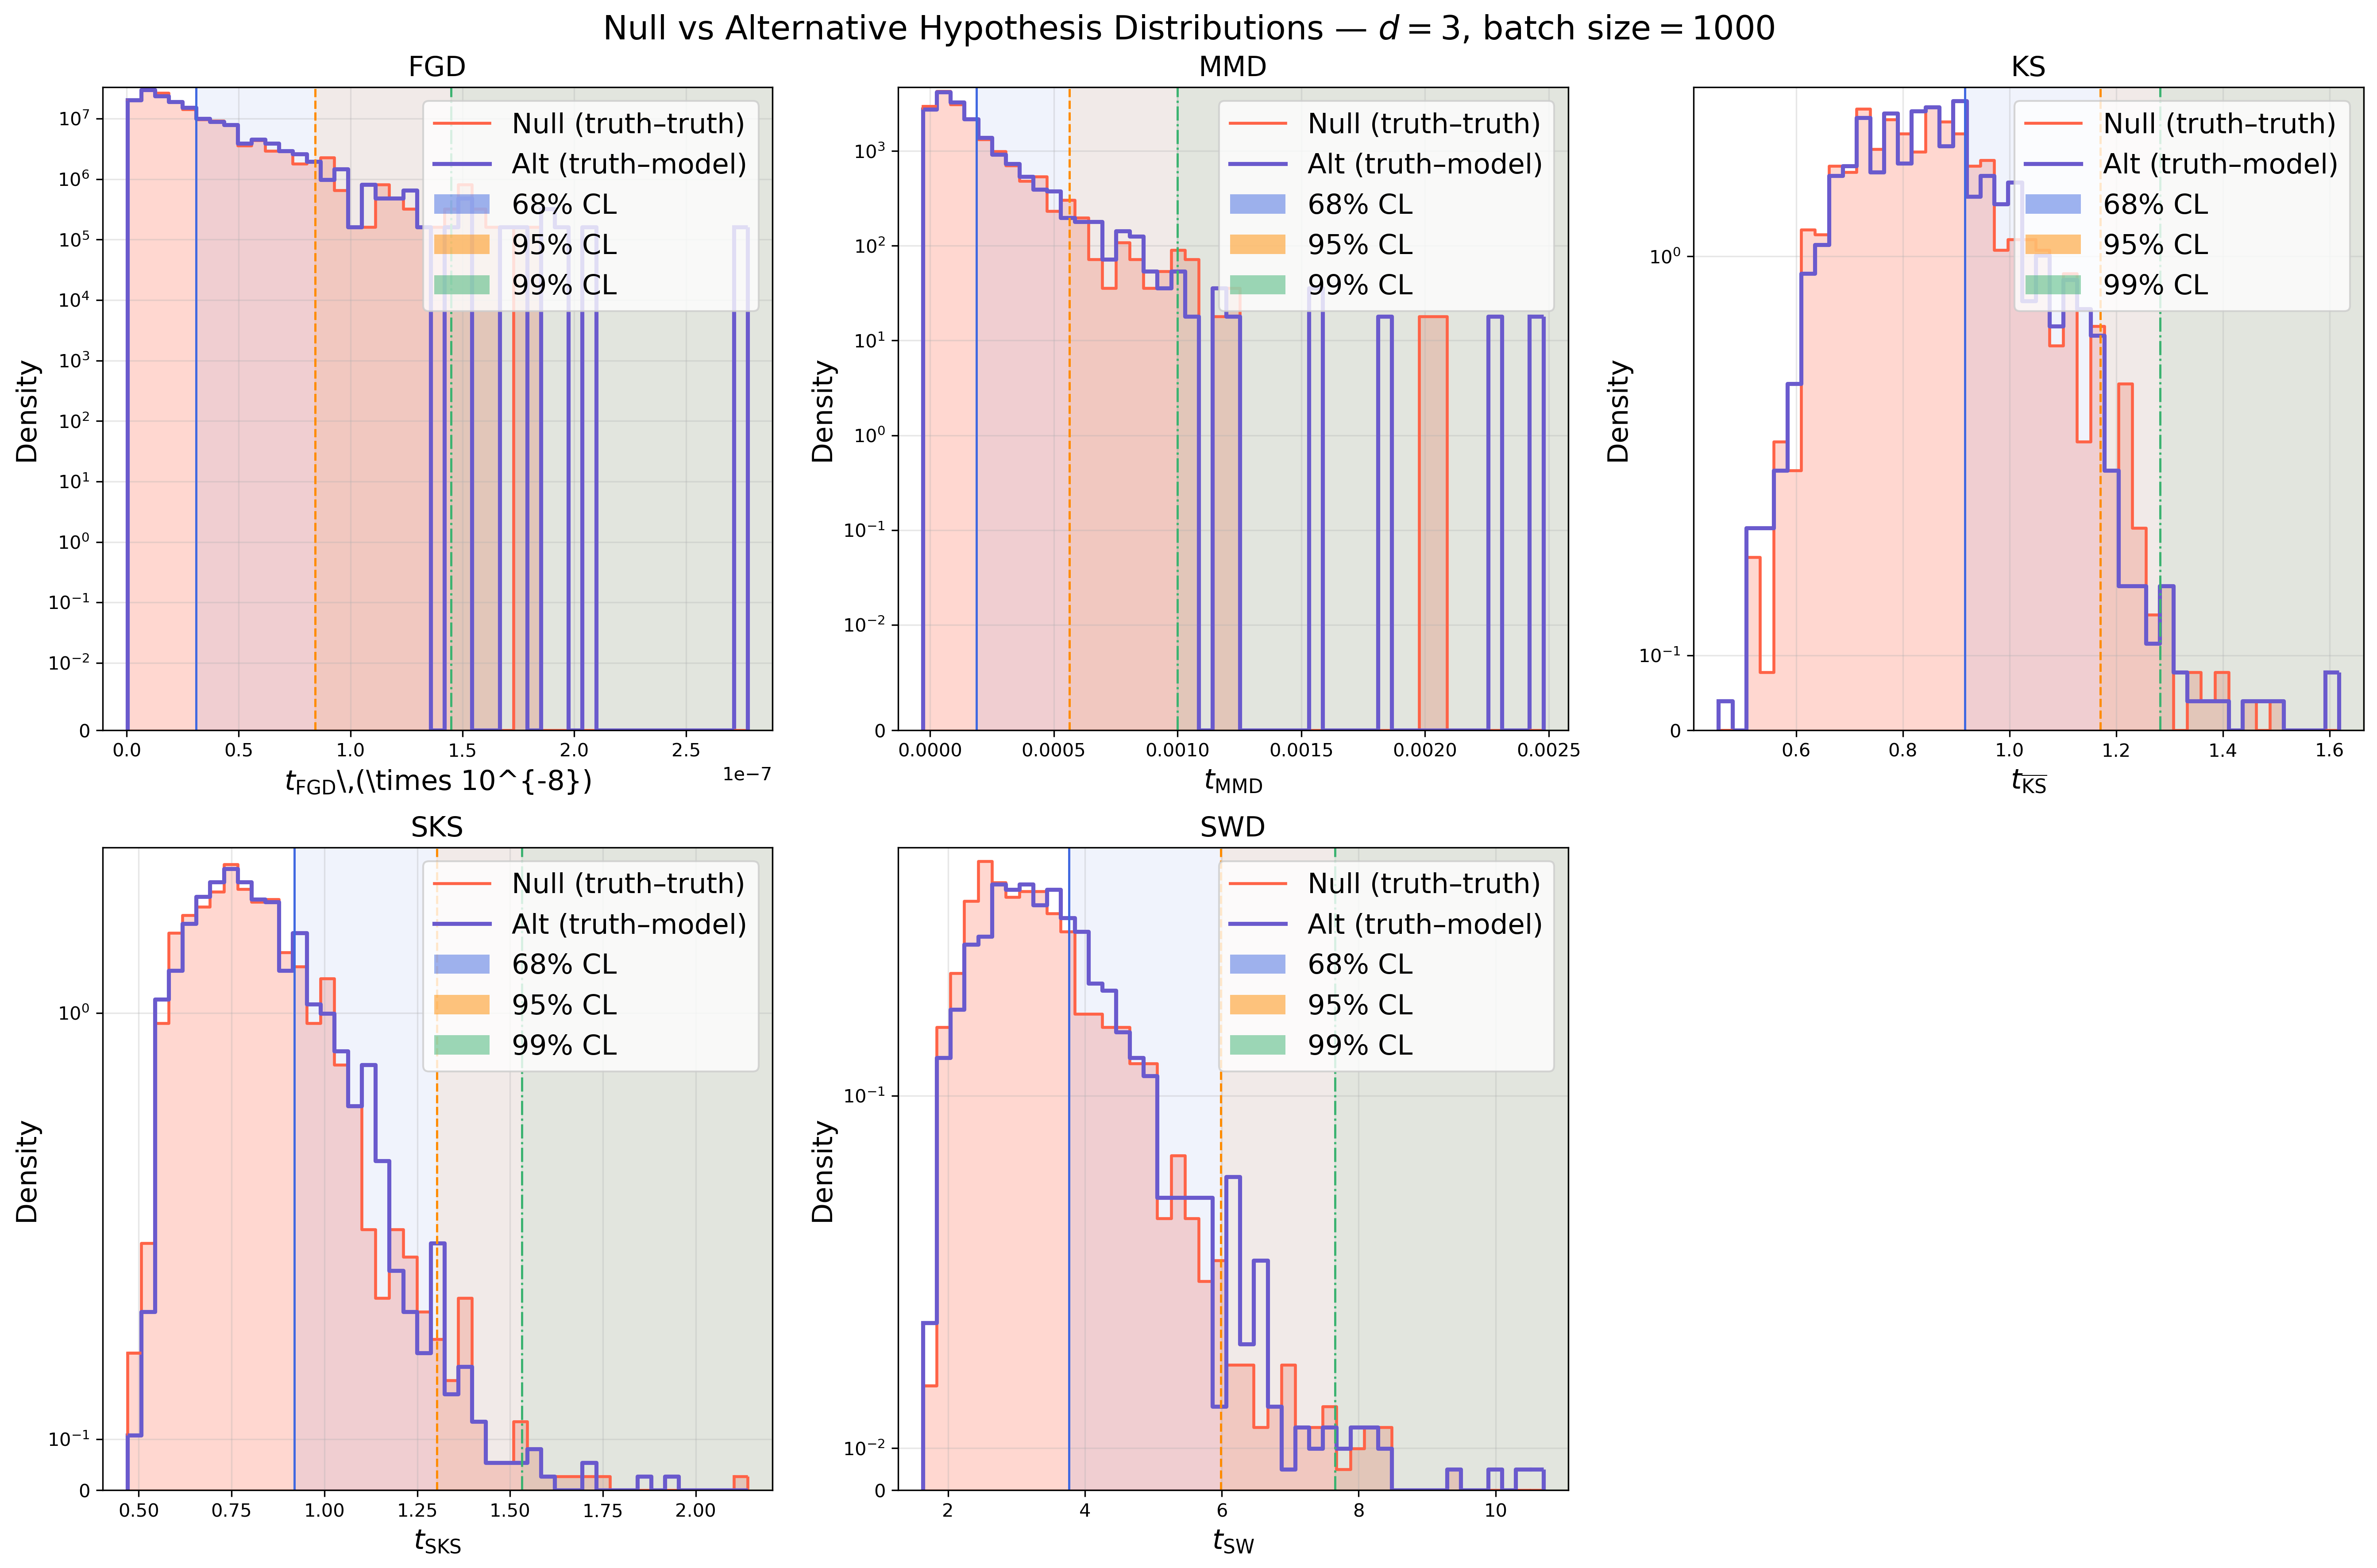

In [ ]:
import eval_plotters
reload(eval_plotters)

# 2) Plot null vs alt (one PDF per metric with CL lines and rejection rates)
eval_plotters.plot_null_vs_alt_pdf(
    metrics_config = metrics_config,
    unique_key     = unique_key,
    observed       = observed,
    ndims          = ndims,
    save_dir       = os.path.join(model_dir, "null_vs_alt/"),
    num_bins=45,
    fill_null=True,
    null_alpha=0.25,
    ypad_frac=0.10,
    show_null_fill_legend = False,
    # FGD
    fgd_x_scale = "linear", fgd_x_linthresh = None,
    fgd_y_scale = "symlog", fgd_y_linthresh = 1e-2,
    # MMD
    mmd_x_scale = "linear", mmd_x_linthresh = 1e-3,
    mmd_y_scale = "symlog", mmd_y_linthresh = 1e-2,
    # KS
    ks_x_scale = "linear", ks_x_linthresh = None,
    ks_y_scale = "symlog", ks_y_linthresh = 5e-1,
    # SKS
    sks_x_scale = "linear", sks_x_linthresh = None,
    sks_y_scale = "symlog", sks_y_linthresh = 9e-1,
    # SWD
    swd_x_scale = "linear", swd_x_linthresh = None,
    swd_y_scale = "symlog", swd_y_linthresh = 9e-2,
    fgd_disp_scale = 1e-8,
    mmd_disp_scale = 1.0,
    ks_disp_scale = 1.0,
    sks_disp_scale = 1.0,
    swd_disp_scale = 1.0,
    show_scale_in_label = True,  # append "(×10^{k})" to xlabel if scale ≠ 1
    plotting_mode="multiple",
    expected_num_metrics=5,  # set what you expect
    batch_size_test=batch_size_test,
)


## computig pvalue

In [ ]:
cache = "./" + str(run_number) + "/pvalues/pvalues_phys_feat/layer_centroid_1k.csv"
df_pvals, pvals = utils_eval.compute_pvalues_table(
    metrics_config=metrics_config,
    unique_key=unique_key,
    observed=observed,
    ndims=ndims,
    agg="median",        # or "mean"
    tail="right",        # or "left" / "two-sided"
    save_csv=cache,
    verbose=True,
)


metric,niter,batch_size,nslices,p_value,time_sec
FGD,1000,1000,-,0.477,-
MMD,1000,1000,-,0.498,-
KS,1000,1000,-,0.505,-
SKS,1000,1000,100.0,0.494,-
SWD,1000,1000,100.0,0.441,-


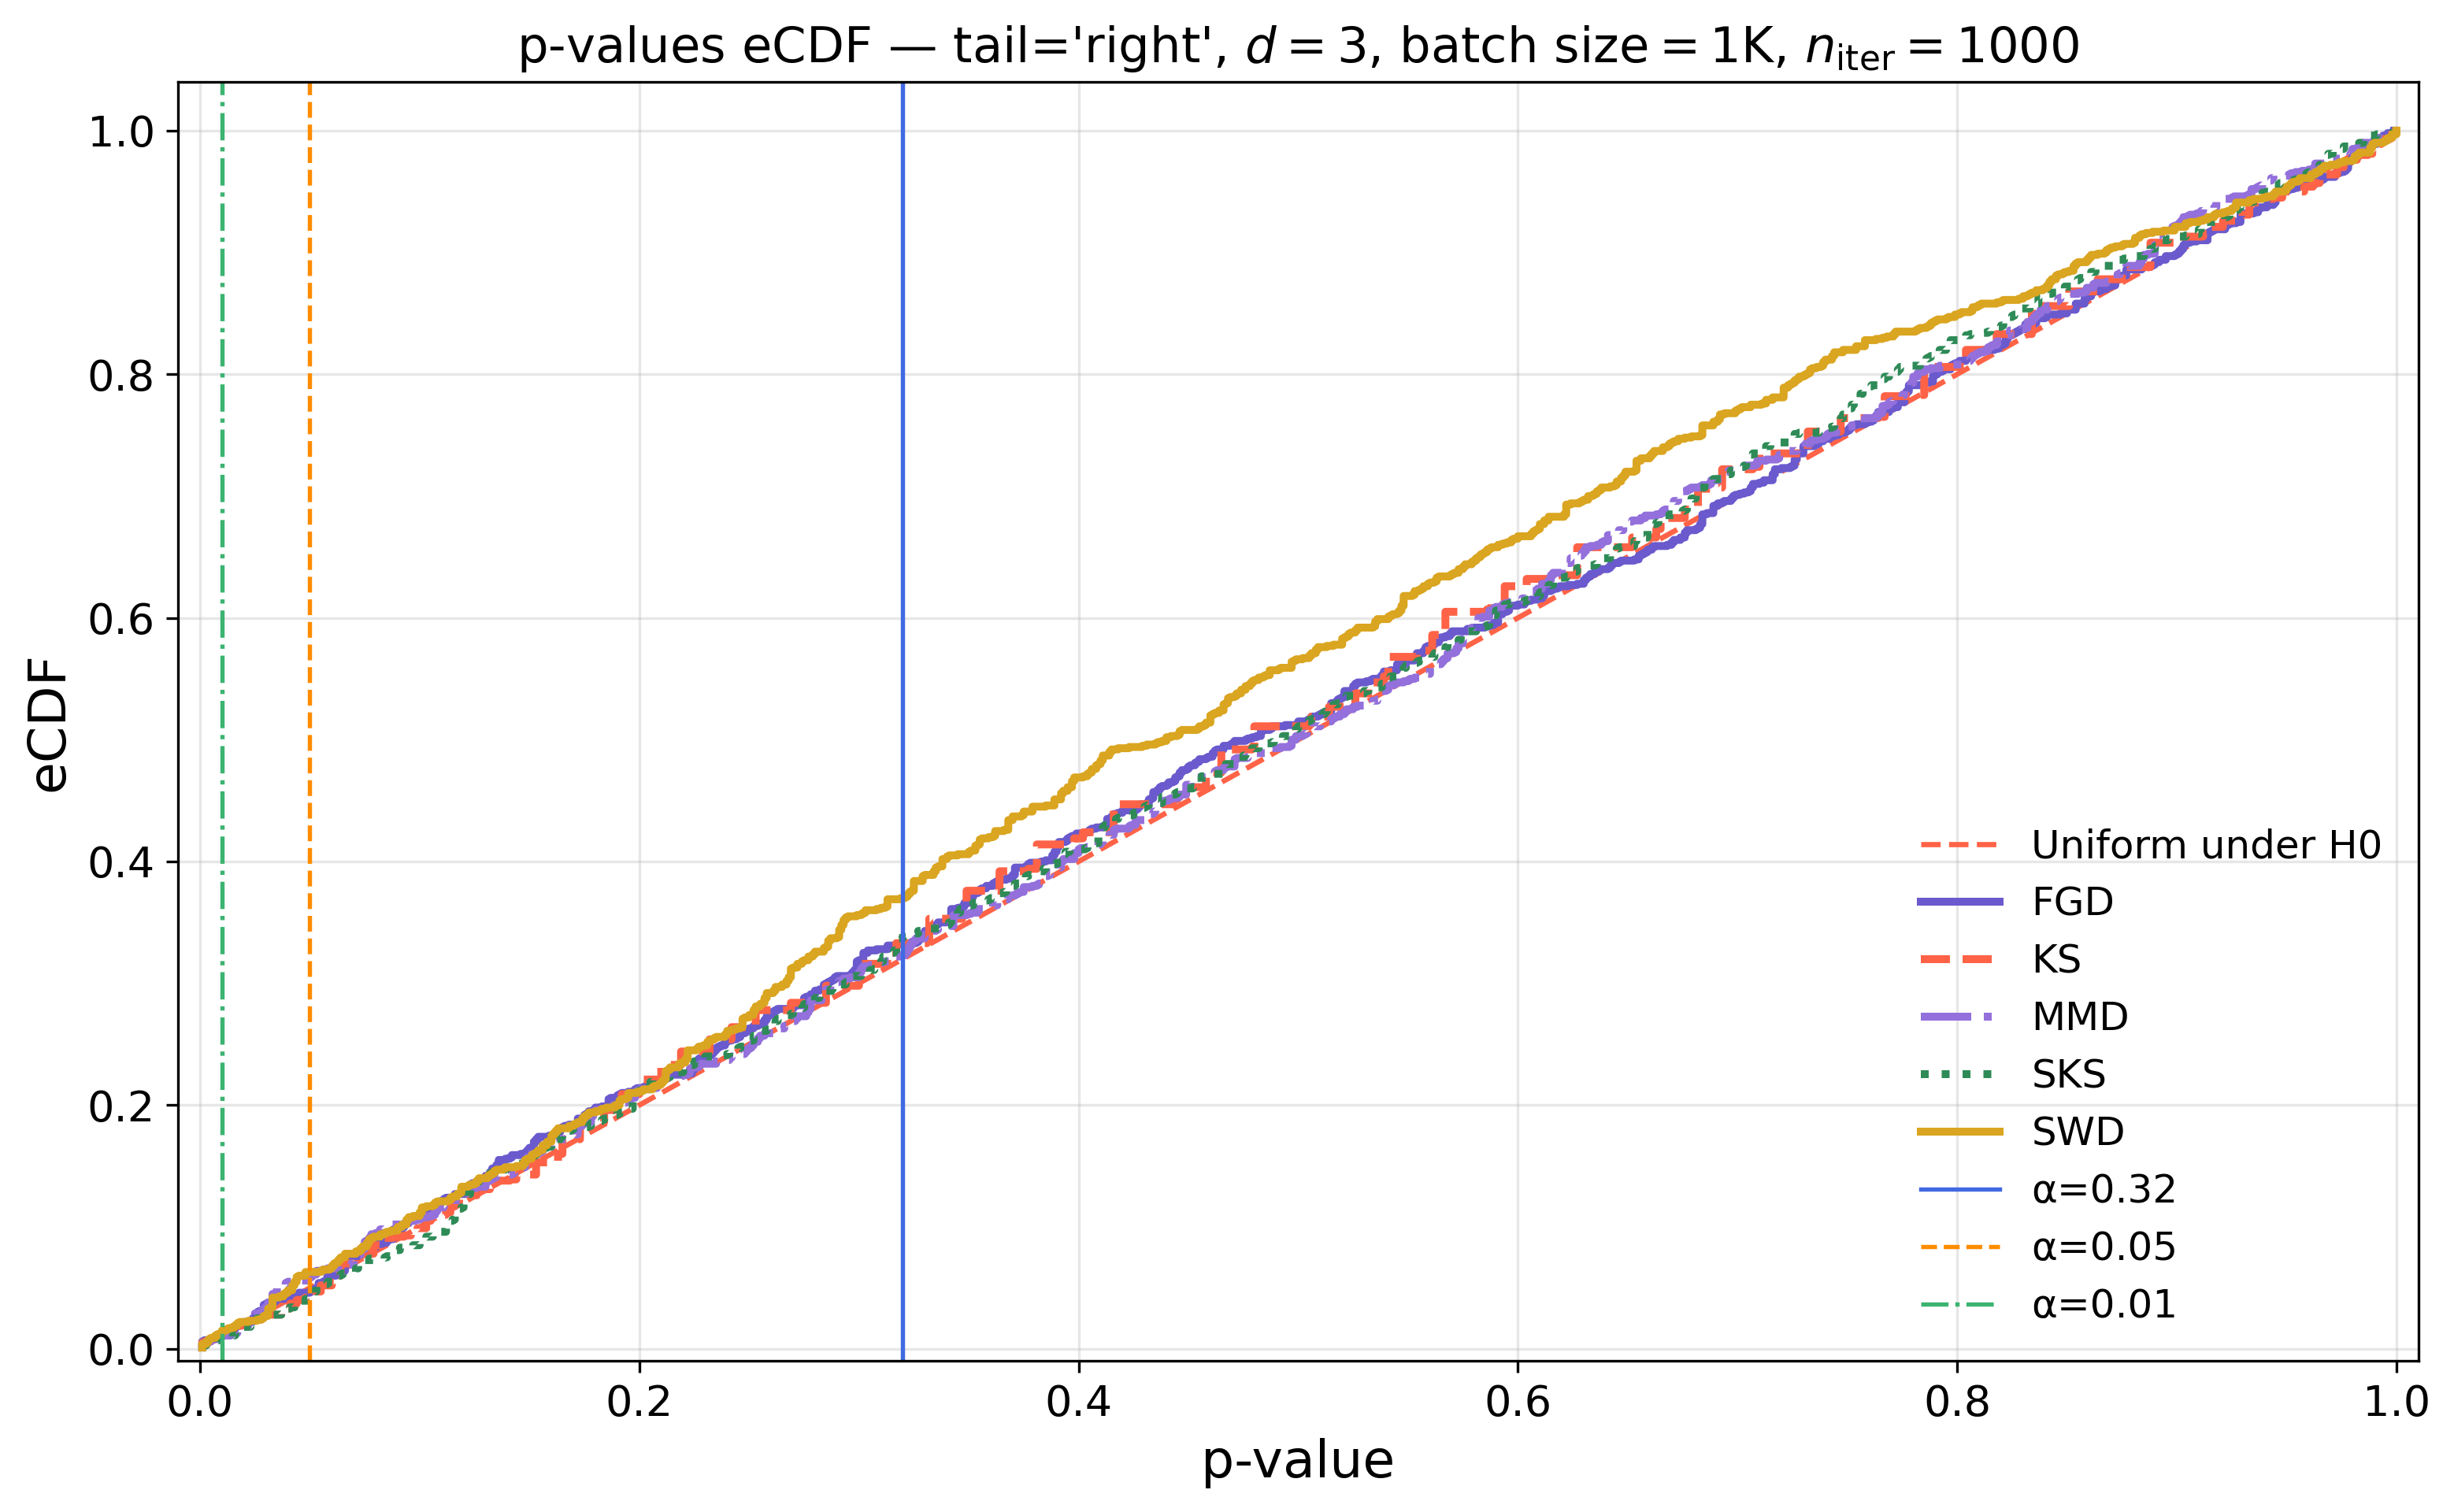

In [ ]:
_ = eval_plotters.compute_and_plot_alt_pvalues(
    metrics_config,
    unique_key,
    observed,
    ndims,
    save_dir=None,
    num_bins = 40,
    top_pad_ecdf = 0.04,
    plot_kind = "cdf")

# Evaluating RMS

## directory path

In [ ]:
#model_dir = "./53/"
model_dir = os.path.join("./", str(run_number) + "/RMS_batchsize_1k/")
if os.path.exists(model_dir):
    print("Model directory exists")
else:
    os.makedirs(model_dir)
    print("Model directory was created")
null_hypotheses_dir = model_dir + "null_hypothesis/"
if os.path.exists(null_hypotheses_dir):
    print("Null hypothesis directory exists")
else:
    os.makedirs(null_hypotheses_dir)
    print("Null hypothesis directory was created")
metrics_config_file = model_dir + "metrics_config.json"

Model directory exists
Null hypothesis directory exists


## loading data

In [ ]:
import utils_eval
reload(utils_eval)

<module 'utils_eval' from '/auto_home/users/acosso/Thesis/evaluation/utils_eval.py'>

In [ ]:
rms_true, rms_gen = utils_eval.load_rms_long_lat_ang(
    "/teo_fs_fast/users/acosso/Dataset/eval_features_A.hdf5",
    dtype=np.float32
)
print(rms_true.shape, rms_gen.shape)  # expected: (100000, 3) (100000, 3)
# Columns are (longitudinal_z [mm], lateral [mm], angular_alpha [rad])


(100000, 3) (100000, 3)


In [ ]:
orig = rms_true.copy()   # keep original intact
rng1 = np.random.default_rng(420)
perm1 = rng1.permutation(len(orig))
input_true1 = orig[perm1].copy()

rng2 = np.random.default_rng(421)
perm2 = rng2.permutation(len(orig))
input_true2 = orig[perm2].copy()
print(input_true1.shape, input_true2.shape)
input_rms_true1 = EmpiricalNumpyDistribution(input_true1.copy(), dtype=np.float32)
input_rms_true2 = EmpiricalNumpyDistribution(input_true2.copy(), dtype=np.float32)

(100000, 3) (100000, 3)


## input builder 

In [ ]:
batch_size_test = 1000
niter = 1000
TwoSampleTestInputs = GMetrics.TwoSampleTestInputs(dist_1_input = input_rms_true1,
                                                   dist_2_input = input_rms_true2,
                                                   niter = niter,
                                                   batch_size_test = batch_size_test,
                                                   batch_size_gen = 1, # not used if numerical samples are provided
                                                   small_sample_threshold = 1,
                                                   dtype_input = tf.float32,
                                                   seed_input = seed_test,
                                                   use_tf = False, 
                                                   mirror_strategy = False,
                                                   verbose = True)
print("nsamples",TwoSampleTestInputs.nsamples)
print("batch_size",TwoSampleTestInputs.batch_size_test)
print("niter",TwoSampleTestInputs.niter)
print("niter * batch_size",TwoSampleTestInputs.niter*TwoSampleTestInputs.batch_size_test)
print("small_sample",TwoSampleTestInputs.small_sample)

Parsing input distribution...
Input distribution is a NumpyDistribution object.
Parsing input distribution...
Input distribution is a NumpyDistribution object.
nsamples 1000000
batch_size 1000
niter 1000
niter * batch_size 1000000
small_sample False


## metric init

In [ ]:
nslices = 100
fgd_num_points = 10
fgd_num_batches = 20

In [ ]:
KSTest = GMetrics.KSTest(TwoSampleTestInputs,
                         progress_bar = True,
                         verbose = True)
SKSTest = GMetrics.SKSTest(TwoSampleTestInputs,
                           nslices = nslices, # to be included in metric kwargs
                           seed_slicing = 0, # to be included in metric kwargs
                           progress_bar = True,
                           verbose = True)
SWDMetric = GMetrics.SWDMetric(TwoSampleTestInputs,
                               nslices = nslices, # to be included in metric kwargs
                               seed_slicing = 0, # to be included in metric kwargs
                               progress_bar = True,
                               verbose = True)

FGDMetric = GMetrics.FGDMetric(TwoSampleTestInputs,
                               progress_bar = True,
                               verbose = True,
                               num_batches = fgd_num_batches, # to be included in metric kwargs
                               num_points = fgd_num_points, # to be included in metric kwargs
                               normalise = False) # to be included in metric kwargs
MMDMetric = GMetrics.MMDMetric(TwoSampleTestInputs,
                               progress_bar = True,
                               verbose = True,
                               degree = 4, # to be included in metric kwargs
                               block_size = 10_000, # to be included in metric kwargs
                               normalise = False) # to be included in metric kwargs


Generating random directions based on nslices, ndims, and seed_slicing.
Generating random directions based on nslices, ndims, and seed_slicing.


In [ ]:
test_config_null = {}
test_config_tmp = dict(TwoSampleTestInputs.__dict__)
keys_to_remove = ["_dist_1_input", "_dist_2_input", "_dist_1_num", "_dist_2_num", "_dist_1_symb", "_dist_2_symb", "_seed_generator"]
for key in keys_to_remove:
    test_config_tmp.pop(key, None)
for key, value in test_config_tmp.items():
    new_key = key.lstrip('_')
    
    if isinstance(value, tf.Tensor):
        new_value = value.numpy() # type: ignore
    elif isinstance(value, np.ndarray):
        new_value = value.tolist()
    elif isinstance(value, np.generic):
        new_value = value.item() # Convert NumPy scalars to Python scalars
    elif isinstance(value, tf.DType):
        new_value = value.name
    elif isinstance(value, np.dtype):
        new_value = np.dtype(value).name
    else:
        new_value = value
    
    test_config_null[new_key] = new_value

pd.DataFrame([test_config_null])

,niter,batch_size_test,batch_size_gen,small_sample_threshold,dtype_input,seed,use_tf,mirror_strategy,strategy,verbose,is_symb_1,ndims_1,nsamples_1,is_symb_2,ndims_2,nsamples_2,dtype,ndims,nsamples,small_sample
0,1000,1000,1,1,float32,42,False,False,None,True,True,3,0,True,3,0,float32,3,1000000,False


In [ ]:
TwoSampleTestInputs.ndims

3

In [ ]:
ndims = TwoSampleTestInputs.ndims
max_vectorize = 45*200
unique_key = "config_ndims_"+str(TwoSampleTestInputs.ndims)+"_nsamples_"+str(TwoSampleTestInputs.batch_size_test)+"_niter_"+str(TwoSampleTestInputs.niter)
metrics_config = {unique_key: {
                                "fgd": {"name": "fgd",
                                       "object_name": "FGDMetric",
                                       "class_name": "GMetrics.FGDMetric",
                                       "kwargs": {"num_batches": fgd_num_batches,
                                                  "num_points": fgd_num_points,
                                                  "normalise": False},
                                       "result_key": "metric_list", 
                                       "scale_func": lambda ns, ndims: 1,
                                       "scale_func_string": "lambda ns, ndims: 1",
                                       "test_config": test_config_null,
                                       "max_vectorize": 100, # optimized for 5D
                                       "latex": "$t_{\mathrm{FGD}}$",
                                       "null_file": null_hypotheses_dir+"FGD.json"},
                                "mmd": {"name": "mmd",
                                       "object_name": "MMDMetric" ,
                                       "class_name": "GMetrics.MMDMetric",
                                       "kwargs": {"degree": 4, 
                                                  "block_size": 10_000, 
                                                  "normalise": False},
                                       "result_key": "metric_list", 
                                       "scale_func": lambda ns, ndims: 1,
                                       "scale_func_string": "lambda ns, ndims: 1",
                                       "test_config": test_config_null,
                                       "max_vectorize": 2, # optimized for 5D
                                       "latex": "$t_{\mathrm{MMD}}$",
                                       "null_file": null_hypotheses_dir+"MMD.json"},
                               "ks":  {"name": "ks",
                                       "object_name": "KSTest",
                                       "class_name": "GMetrics.KSTest", 
                                       "kwargs": {},
                                       "result_key": "statistic_means", 
                                       "scale_func": lambda ns, _ : np.sqrt(ns),
                                       "scale_func_string": "lambda ns, _: np.sqrt(ns)",
                                       "test_config": test_config_null,
                                       "max_vectorize": max_vectorize,
                                       "latex": "$t_{\overline{\mathrm{KS}}}$",
                                       "null_file": null_hypotheses_dir+"KS.json"},
                               "sks": {"name": "sks",
                                       "object_name": "SKSTest",
                                       "class_name": "GMetrics.SKSTest", 
                                       "kwargs": {"nslices": nslices, 
                                                  "seed_slicing": 0},
                                       "result_key": "metric_means", 
                                       "scale_func": lambda ns, _ : np.sqrt(ns),
                                       "scale_func_string": "lambda ns, _: np.sqrt(ns)",
                                       "test_config": test_config_null,
                                       "max_vectorize": max_vectorize,
                                       "latex": "$t_{\mathrm{SKS}}$",
                                       "null_file": null_hypotheses_dir+"SKS.json"},
                               "swd": {"name": "swd",
                                       "object_name": "SWDMetric",
                                       "class_name": "GMetrics.SWDMetric", 
                                       "kwargs": {"nslices": nslices, 
                                                  "seed_slicing": 0},
                                       "result_key": "metric_means", 
                                       "scale_func": lambda ns, ndims: np.sqrt(ns/ndims),
                                       "scale_func_string": "lambda ns, ndims: np.sqrt(ns/ndims)",
                                       "test_config": test_config_null,
                                       "max_vectorize": max_vectorize,
                                       "latex": "$t_{\mathrm{SW}}$",
                                       "null_file": null_hypotheses_dir+"SWD.json"}
                               }}

## Null hypothesis evaluation

In [ ]:
import inspect

for metric in list(metrics_config[unique_key].values()):
    file = metric["null_file"]
    name = metric["name"]
    max_vectorize = metric.get("max_vectorize", None)
    obj = eval(metric["object_name"])

    os.makedirs(os.path.dirname(file), exist_ok=True)

    use_tf_flag = getattr(obj.Inputs, "use_tf", False)
    test_fn = getattr(obj, "Test_tf", None) if use_tf_flag else getattr(obj, "Test_np", None)
    if test_fn is None:
        raise RuntimeError(f"{name}: no test function for use_tf={use_tf_flag}")

    if os.path.exists(file):
        print(f"Loading {name} from {file}")
        obj.Results.load_from_json(file)
    else:
        print(f"Computing and saving {name} (use_tf={use_tf_flag})")
        sig = inspect.signature(test_fn)
        call_kwargs = {}
        if "max_vectorize" in sig.parameters and max_vectorize is not None:
            call_kwargs["max_vectorize"] = max_vectorize
        test_fn(**call_kwargs)
        print(f"Saving {name} to {file}")
        obj.Results.save_to_json(file)


Computing and saving fgd (use_tf=False)

------------------------------------------
Starting FGD metric calculation...
niter = 1000
batch_size = 1000


Iterations:   0%|          | 0/1000 [00:00<?, ?it/s]

Running numpy FGD calculation...


/auto_home/users/acosso/Thesis/evaluation/../GMetrics/metrics/fgd.py:436: RuntimeWarning: Recommended number of samples for FPD estimation is 50,000
  metric, metric_error = JMetrics.fpd(dist_1_k, dist_2_k, **self.fgd_kwargs)
Iterations: 100%|██████████| 1000/1000 [13:55<00:00,  1.20it/s]


Two-sample test calculation completed in 835.0068590778392 seconds.
Saving fgd to ./53/RMS_batchsize_1k/null_hypothesis/FGD.json
Computing and saving mmd (use_tf=False)

------------------------------------------
Starting MMD metric calculation...
niter = 1000
batch_size = 1000


Iterations:   0%|          | 0/1000 [00:00<?, ?it/s]

Running numpy MMD calculation...


Iterations: 100%|██████████| 1000/1000 [1:24:21<00:00,  5.06s/it]

Two-sample test calculation completed in 5061.374107008101 seconds.
Saving mmd to ./53/RMS_batchsize_1k/null_hypothesis/MMD.json
Loading ks from ./53/RMS_batchsize_1k/null_hypothesis/KS.json
Loading sks from ./53/RMS_batchsize_1k/null_hypothesis/SKS.json
Loading swd from ./53/RMS_batchsize_1k/null_hypothesis/SWD.json


## Thresholds and summary

In [ ]:
cl_list = [0.68, 0.95, 0.99]
null_times = []

for metric in list(metrics_config[unique_key].values()):
    name = metric["name"]
    obj = eval(metric["object_name"])
    result_key = metric["result_key"]
    scale_func = metric["scale_func"]
    
    #params = obj.Results[-1].__dict__  # parameters are in the result object
    #bs_used = int(params.get('batch_size_test_used', obj.Inputs.batch_size_test))
    #ns_eff = bs_used / 2.0
    #dist_null = np.array(obj.Results[-1].result_value[result_key]) * scale_func(ns_eff, ndims)
    nsamples = obj.Inputs.batch_size_test
    ns = nsamples**2 /(2*nsamples)  # == nsamples/2
    dist_null = np.array(obj.Results[-1].result_value[result_key]) * scale_func(ns, ndims)

    metric_thresholds = [[cl, 
                          [int(cl*len(dist_null)), 
                           int((1-cl)*len(dist_null))], 
                          np.sort(dist_null)[int(len(dist_null)*cl)]] for cl in cl_list]
    print(f"ThresholdS for metric {metric['name']}: {metric_thresholds}")
    null_time = obj.Results[-1].__dict__['computing_time']
    null_times.append([name, int(null_time)])
    print(f"Computing time for metric {metric['name']}: {null_time}")
    
    metric.update({"thresholds": metric_thresholds})
    
#metrics_config[unique_key]["lr"]["thresholds"] = [] #likelihood ratio test not computed

GMetrics.utils.save_update_metrics_config(metrics_config = metrics_config, metrics_config_file = metrics_config_file) # type: ignore

ThresholdS for metric fgd: [[0.68, [680, 319], 0.1287027303881485], [0.95, [950, 50], 0.36972154596486084], [0.99, [990, 10], 0.48836907783498806]]
Computing time for metric fgd: 835.0068590778392
ThresholdS for metric mmd: [[0.68, [680, 319], 0.0001369351678741637], [0.95, [950, 50], 0.00041900617551293706], [0.99, [990, 10], 0.0007436699870551067]]
Computing time for metric mmd: 5061.374107008101
ThresholdS for metric ks: [[0.68, [680, 319], 0.9093343108499145], [0.95, [950, 50], 1.1553017883748913], [0.99, [990, 10], 1.2820123070998797]]
Computing time for metric ks: 1.3421994880773127
ThresholdS for metric sks: [[0.68, [680, 319], 0.8982285065616655], [0.95, [950, 50], 1.1739356881873897], [0.99, [990, 10], 1.4207975929033665]]
Computing time for metric sks: 44.15959768090397
ThresholdS for metric swd: [[0.68, [680, 319], 1.9614855183319215], [0.95, [950, 50], 2.6345110702068153], [0.99, [990, 10], 3.3835032172377044]]
Computing time for metric swd: 24.59577734908089


,name,object_name,class_name,kwargs,result_key,scale_func,scale_func_string,test_config,max_vectorize,latex,null_file,thresholds
0,fgd,FGDMetric,GMetrics.FGDMetric,"{'num_batches': 20, 'num_points': 10, 'normali...",metric_list,<function <lambda> at 0x7fcac41098a0>,"lambda ns, ndims: 1","{'niter': 1000, 'batch_size_test': 1000, 'batc...",100,$t_{\mathrm{FGD}}$,./53/RMS_batchsize_1k/null_hypothesis/FGD.json,"[[0.68, [680, 319], 0.1287027303881485], [0.95..."
1,mmd,MMDMetric,GMetrics.MMDMetric,"{'degree': 4, 'block_size': 10000, 'normalise'...",metric_list,<function <lambda> at 0x7fca74480220>,"lambda ns, ndims: 1","{'niter': 1000, 'batch_size_test': 1000, 'batc...",2,$t_{\mathrm{MMD}}$,./53/RMS_batchsize_1k/null_hypothesis/MMD.json,"[[0.68, [680, 319], 0.0001369351678741637], [0..."
2,ks,KSTest,GMetrics.KSTest,{},statistic_means,<function <lambda> at 0x7fca74483880>,"lambda ns, _: np.sqrt(ns)","{'niter': 1000, 'batch_size_test': 1000, 'batc...",9000,$t_{\overline{\mathrm{KS}}}$,./53/RMS_batchsize_1k/null_hypothesis/KS.json,"[[0.68, [680, 319], 0.9093343108499145], [0.95..."
3,sks,SKSTest,GMetrics.SKSTest,"{'nslices': 100, 'seed_slicing': 0}",metric_means,<function <lambda> at 0x7fca747d4860>,"lambda ns, _: np.sqrt(ns)","{'niter': 1000, 'batch_size_test': 1000, 'batc...",9000,$t_{\mathrm{SKS}}$,./53/RMS_batchsize_1k/null_hypothesis/SKS.json,"[[0.68, [680, 319], 0.8982285065616655], [0.95..."
4,swd,SWDMetric,GMetrics.SWDMetric,"{'nslices': 100, 'seed_slicing': 0}",metric_means,<function <lambda> at 0x7fca747d4c20>,"lambda ns, ndims: np.sqrt(ns/ndims)","{'niter': 1000, 'batch_size_test': 1000, 'batc...",9000,$t_{\mathrm{SW}}$,./53/RMS_batchsize_1k/null_hypothesis/SWD.json,"[[0.68, [680, 319], 1.9614855183319215], [0.95..."


## observed statistichs

In [ ]:
orig_true = rms_true.copy()
orig_gen = rms_gen.copy()
rng1 = np.random.default_rng(1234)
rng2 = np.random.default_rng(5678)
shuffled_true = orig_true[rng1.permutation(orig_true.shape[0])]
shuffled_gen = orig_gen[rng2.permutation(orig_gen.shape[0])]
input_rms_true = EmpiricalNumpyDistribution(shuffled_true.copy(), dtype=np.float32)
input_rms_gen = EmpiricalNumpyDistribution(shuffled_gen.copy(), dtype=np.float32)

In [ ]:
cache = model_dir + "/alternative_hypothesis/alt_hyp_rms_1k"
observed = utils_eval.compute_observed_distributions(
    metrics_config, unique_key,
    dist_1_num=input_rms_true,
    dist_2_num=input_rms_gen,
    ndims=ndims,
    batch_size_test=batch_size_test,
    niter_obs=1000,
    dtype=tf.float64, use_tf=False, verbose=True,
    cache_file=cache, overwrite=True, show_progress=True
)

[compute_observed_distributions] Using generalized inputs -> dist_1: numpy-distribution, dist_2: numpy-distribution
Parsing input distribution...
Input distribution is a NumpyDistribution object.
Parsing input distribution...
Input distribution is a NumpyDistribution object.


T_obs (niter=1000, batch=1000):   0%|          | 0/5 [00:00<?, ?it/s]


------------------------------------------
Starting FGD metric calculation...
niter = 1000
batch_size = 1000


Running numpy FGD calculation...


/auto_home/users/acosso/Thesis/evaluation/../GMetrics/metrics/fgd.py:436: RuntimeWarning: Recommended number of samples for FPD estimation is 50,000
  metric, metric_error = JMetrics.fpd(dist_1_k, dist_2_k, **self.fgd_kwargs)
Iterations: 100%|██████████| 1000/1000 [14:23<00:00,  1.16it/s]


...

Iterations: 100%|██████████| 1000/1000 [00:44<00:00, 22.47it/s]


Two-sample test calculation completed in 44.50132243917324 seconds.
[done] sks in 44.52s  (niter=1000, batch=1000)
Generating random directions based on nslices, ndims, and seed_slicing.

------------------------------------------
Starting SWD metric calculation...
niter = 1000
batch_size = 1000


Running numpy SKS calculation...


Iterations: 100%|██████████| 1000/1000 [00:24<00:00, 40.62it/s]

Two-sample test calculation completed in 24.622178042074665 seconds.
[done] swd in 24.64s  (niter=1000, batch=1000)
[compute_observed_distributions] Cached results saved to: ./53/RMS_batchsize_1k//alternative_hypothesis/alt_hyp_rms_1k


[GRID] saved ./53/RMS_batchsize_1k/null_vs_alt/config_ndims_3_nsamples_1000_niter_1000_null_vs_alt_PDF_grid_5.pdf


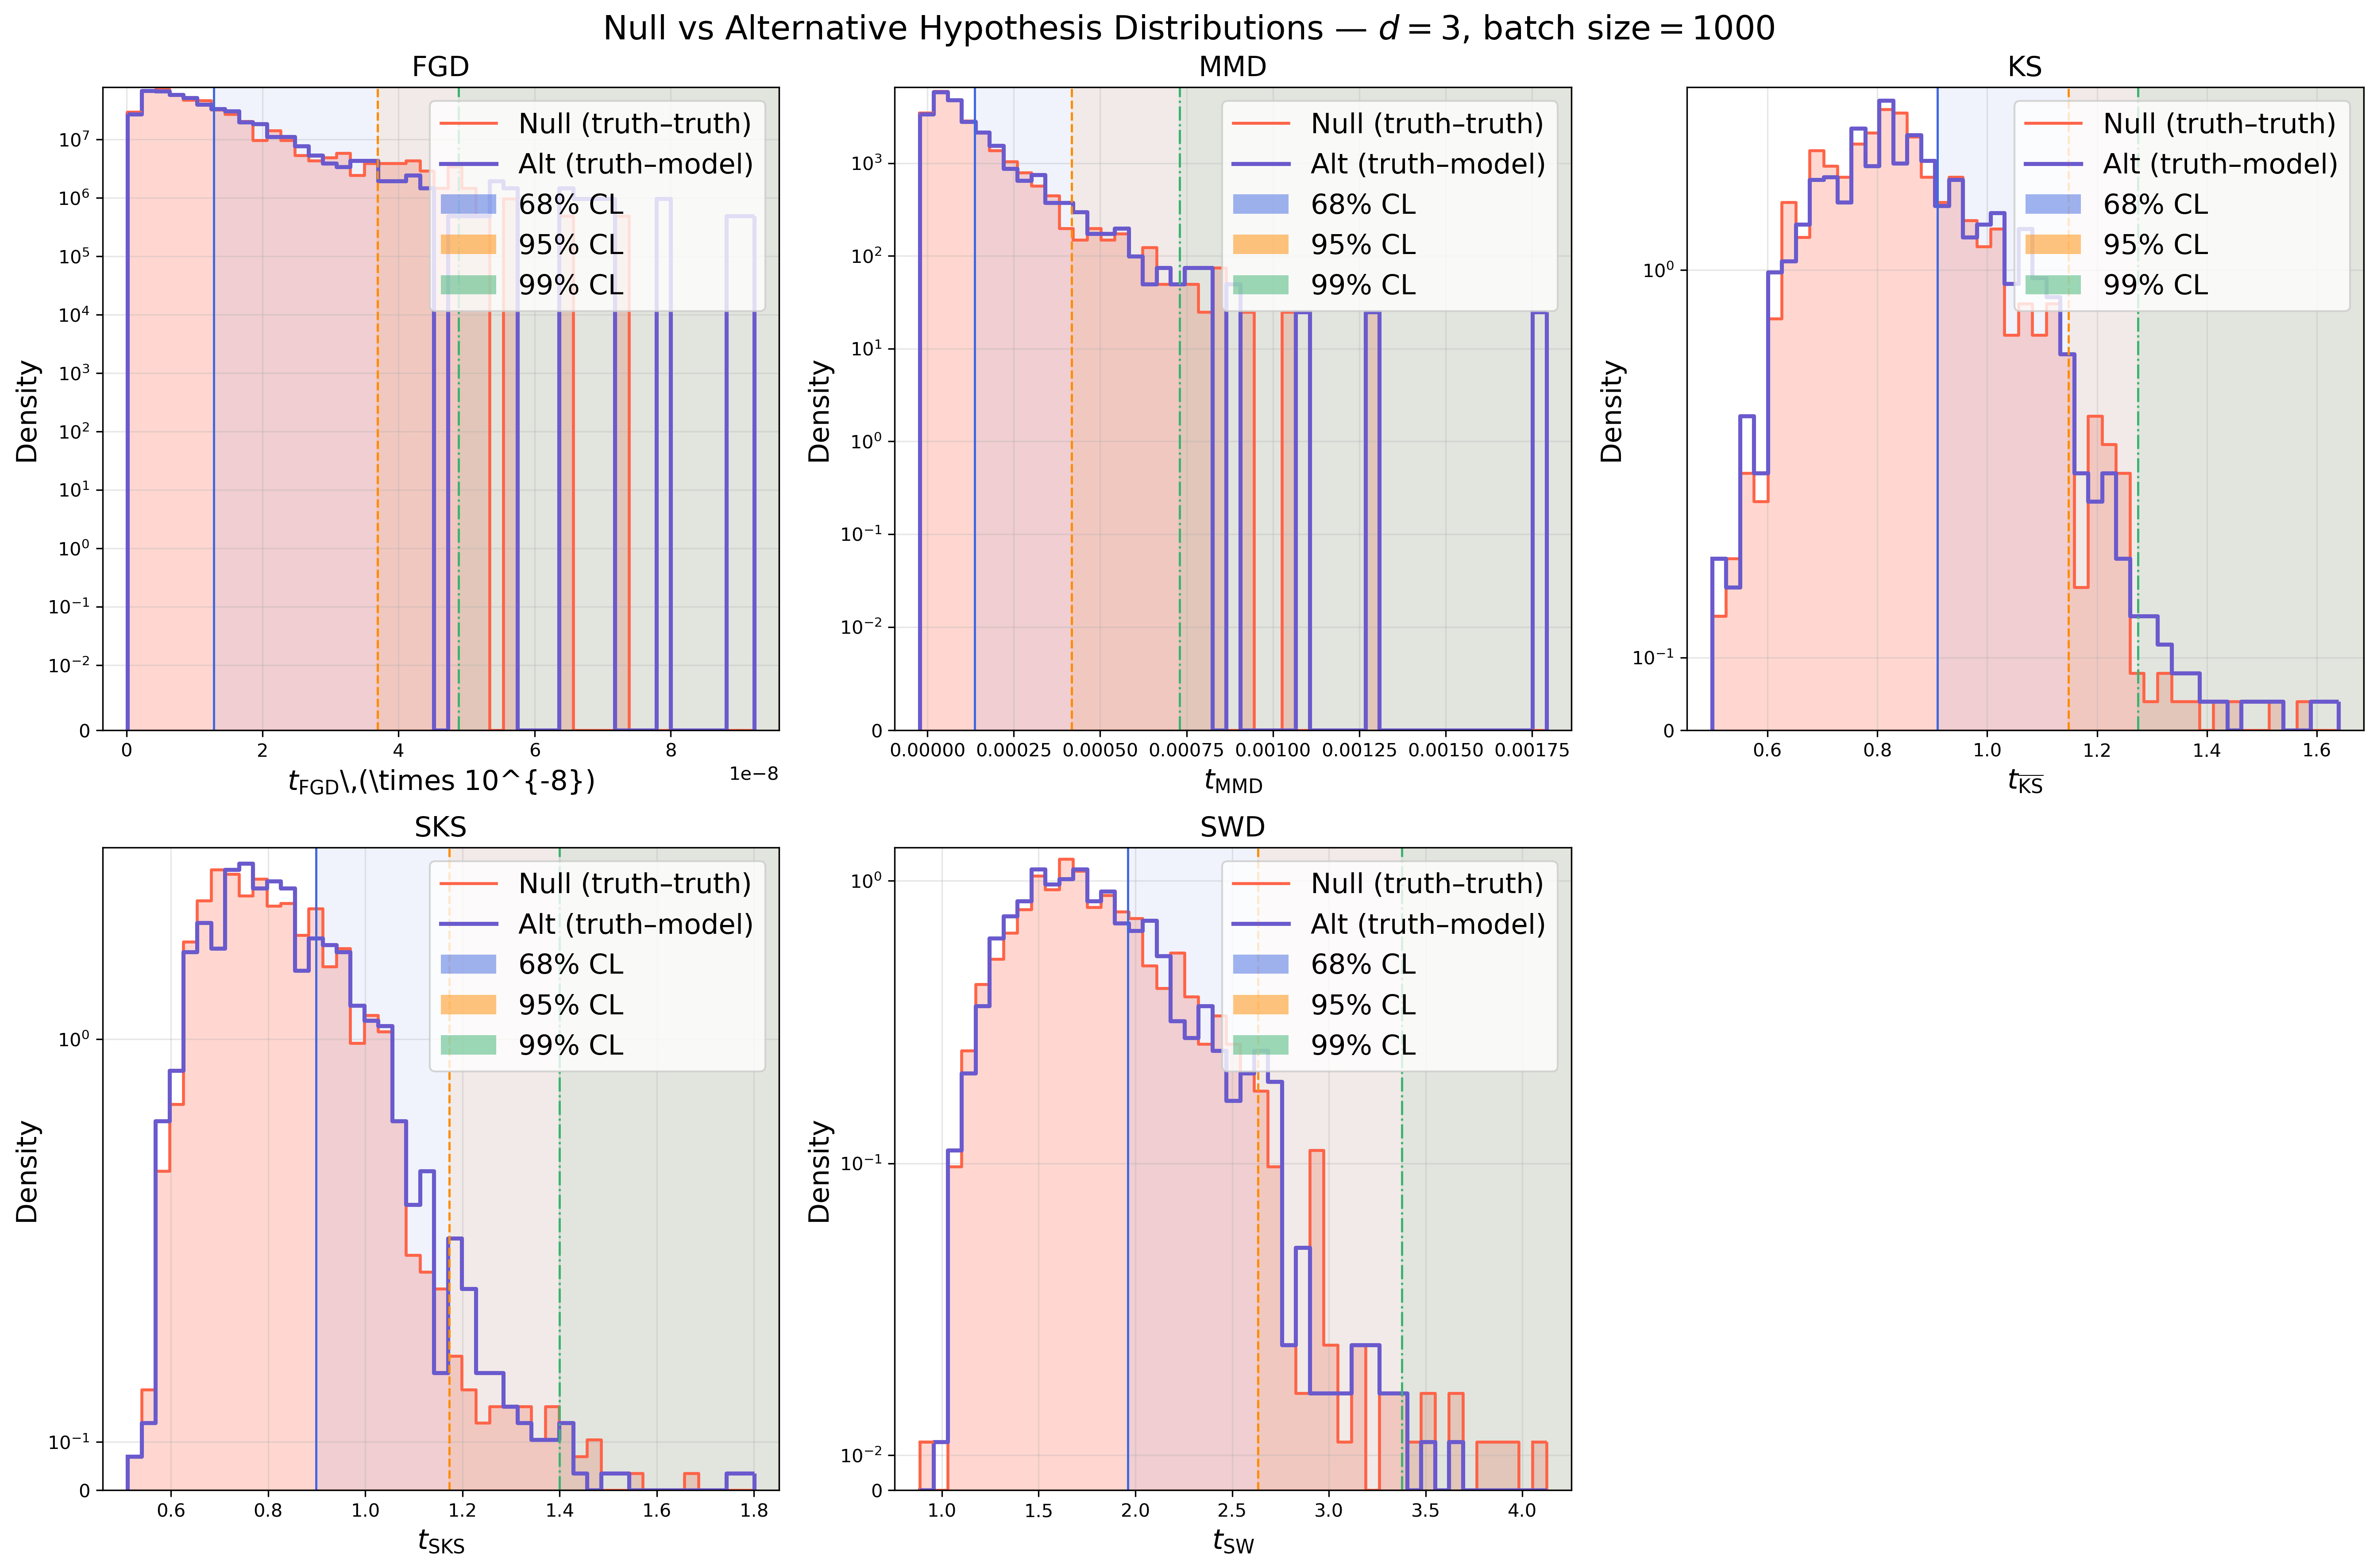

In [ ]:
import eval_plotters
reload(eval_plotters)

# 2) Plot null vs alt (one PDF per metric with CL lines and rejection rates)
eval_plotters.plot_null_vs_alt_pdf(
    metrics_config = metrics_config,
    unique_key     = unique_key,
    observed       = observed,
    ndims          = ndims,
    save_dir       = os.path.join(model_dir, "null_vs_alt/"),
    num_bins=45,
    fill_null=True,
    null_alpha=0.25,
    ypad_frac=0.10,
    show_null_fill_legend = False,
    # FGD
    fgd_x_scale = "linear", fgd_x_linthresh = None,
    fgd_y_scale = "symlog", fgd_y_linthresh = 1e-2,
    # MMD
    mmd_x_scale = "linear", mmd_x_linthresh = 1e-3,
    mmd_y_scale = "symlog", mmd_y_linthresh = 1e-2,
    # KS
    ks_x_scale = "linear", ks_x_linthresh = None,
    ks_y_scale = "symlog", ks_y_linthresh = 5e-1,
    # SKS
    sks_x_scale = "linear", sks_x_linthresh = None,
    sks_y_scale = "symlog", sks_y_linthresh = 9e-1,
    # SWD
    swd_x_scale = "linear", swd_x_linthresh = None,
    swd_y_scale = "symlog", swd_y_linthresh = 9e-2,
    fgd_disp_scale = 1e-8,
    mmd_disp_scale = 1.0,
    ks_disp_scale = 1.0,
    sks_disp_scale = 1.0,
    swd_disp_scale = 1.0,
    show_scale_in_label = True,  # append "(×10^{k})" to xlabel if scale ≠ 1
    plotting_mode="multiple",
    expected_num_metrics=5,  # set what you expect
    batch_size_test=batch_size_test
)


## computig pvalue

In [ ]:
cache = "./" + str(run_number) + "/pvalues/pvalues_phys_feat/shower_rms_1k.csv"
df_pvals, pvals = utils_eval.compute_pvalues_table(
    metrics_config=metrics_config,
    unique_key=unique_key,
    observed=observed,
    ndims=ndims,
    agg="median",        # or "mean"
    tail="right",        # or "left" / "two-sided"
    save_csv=cache,
    verbose=True,
)


metric,niter,batch_size,nslices,p_value,time_sec
FGD,1000,1000,-,0.491,-
MMD,1000,1000,-,0.496,-
KS,1000,1000,-,0.461,-
SKS,1000,1000,100.0,0.489,-
SWD,1000,1000,100.0,0.505,-


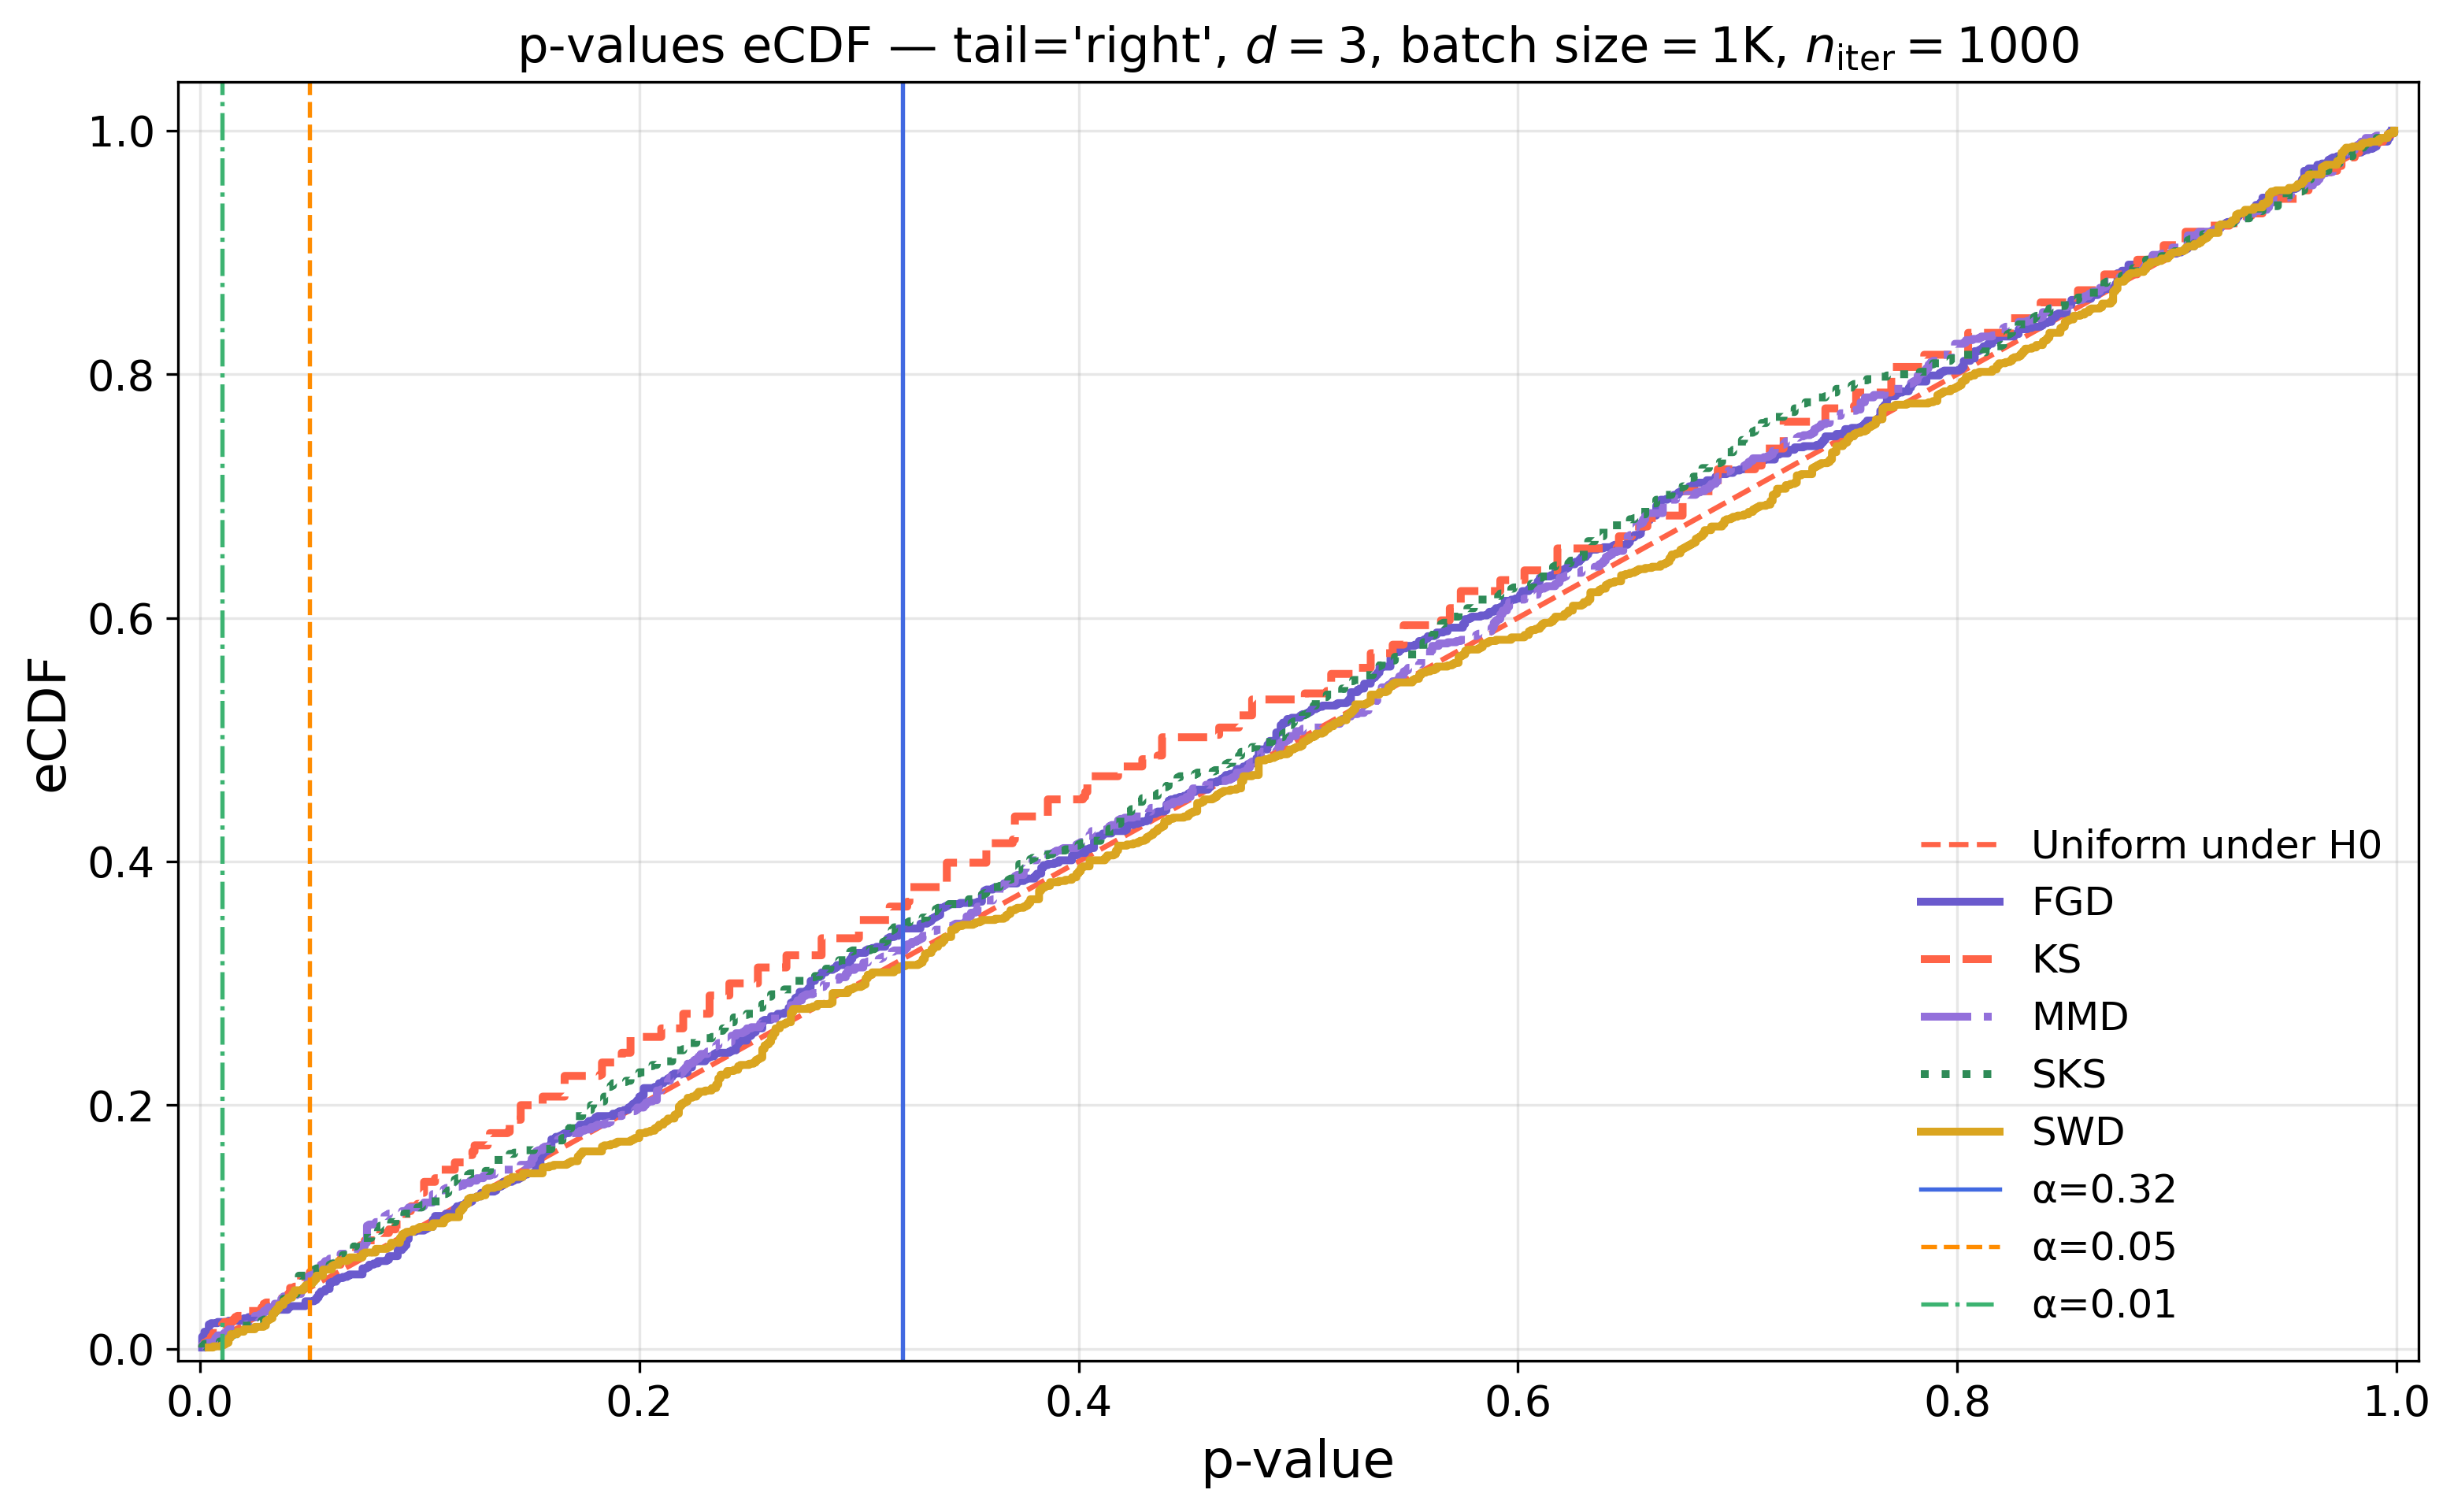

In [ ]:
_ = eval_plotters.compute_and_plot_alt_pvalues(
    metrics_config,
    unique_key,
    observed,
    ndims,
    save_dir=None,
    num_bins = 40,
    top_pad_ecdf = 0.04,
    plot_kind = "cdf")